# **Rome Airbnb Clusterization**

**Project**: Airbnb Market Segmentation Analysis

**Goal**: Cluster Rome's Airbnb listings using the final feature set from EDA & Feature Selection, testing systematically whether NLP-derived signals reveal market structure invisible to tabular features alone, resolving the geography input, tuning k and gamma, and validating cluster stability before profiling the resulting segments.

## 1. Setup & Preprocessing

### 1.1 Imports & Environment

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import re
import html

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Base path configuration
BASE_PATH = Path.cwd().parent

In [3]:
ROME_PALETTE = {
    'primary': '#8B3A3A', 'secondary': '#4C6B8A', 'accent': '#C9A227',
    'neutral': '#6B6B6B', 'light_bg': '#F5F1EC',
}
plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25,
})

### 1.2 Data Loading

In [4]:
listings = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'listings_final.csv')

In [5]:
listings.drop(columns = ['Unnamed: 0'], inplace = True)
print(f"shape: {listings.shape}")
print(f"\ndtypes:\n{listings.dtypes.value_counts()}")

shape: (35818, 151)

dtypes:
float64    88
str        45
int64      18
Name: count, dtype: int64


### 1.3 Split Off External Variables

In [6]:
EXTERNAL_COLS = ['id', 'price', 'price_tier', 'latitude', 'longitude', 'neighbourhood_cleansed']

listing_ids = listings['id'].copy()
price = listings['price'].copy()
price_tier = listings['price_tier'].copy()
latitude = listings['latitude'].copy()
longitude = listings['longitude'].copy()
neighbourhood_cleansed = listings['neighbourhood_cleansed'].copy()

print("External variables:")
for name, series in [('listing_ids', listing_ids), ('price', price), ('price_tier', price_tier),
                       ('latitude', latitude), ('longitude', longitude)]:
    print(f"  {name}: {len(series)} values, {series.isna().sum()} NaN")

External variables:
  listing_ids: 35818 values, 0 NaN
  price: 35818 values, 3737 NaN
  price_tier: 35818 values, 0 NaN
  latitude: 35818 values, 0 NaN
  longitude: 35818 values, 0 NaN


### 1.4 The `has_reviews` Strata Split

Several review-derived columns go structurally missing/`Unknown` together for the same ~14% of listings. A listing with no reviews has no sentiment, no review score, no topic content, all at once. Left inside the clustering feature set, this synchronized absence inflates the distance between "has reviews" and "no reviews" listings across many columns simultaneously, risking a cluster defined by that one structural fact rather than by genuine market segmentation. Listings without reviews are set aside here for separate, descriptive profiling later, and clustering runs only on the population that actually has review data.

In [7]:
print(f"has_reviews value counts:\n{listings['has_reviews'].value_counts()}")

listings_no_review = listings[listings['has_reviews'] == 0].copy()
listings_reviewed = listings[listings['has_reviews'] == 1].copy()

print(f"\nlistings_no_review: {listings_no_review.shape[0]} rows ({listings_no_review.shape[0]/len(listings)*100:.1f}%)")
print(f"listings_reviewed: {listings_reviewed.shape[0]} rows ({listings_reviewed.shape[0]/len(listings)*100:.1f}%)")
print(f"\nrows accounted for: {listings_no_review.shape[0] + listings_reviewed.shape[0]} vs total {len(listings)}")


listing_ids = listing_ids.loc[listings_reviewed.index]
price = price.loc[listings_reviewed.index]
price_tier = price_tier.loc[listings_reviewed.index]
latitude = latitude.loc[listings_reviewed.index]
longitude = longitude.loc[listings_reviewed.index]
neighbourhood_cleansed = neighbourhood_cleansed.loc[listings_reviewed.index]

print(f"\nexternal variables re-aligned to listings_reviewed: {len(listing_ids)} rows each")

has_reviews value counts:
has_reviews
1    30718
0     5100
Name: count, dtype: int64

listings_no_review: 5100 rows (14.2%)
listings_reviewed: 30718 rows (85.8%)

rows accounted for: 35818 vs total 35818

external variables re-aligned to listings_reviewed: 30718 rows each


### 1.5 Splitting Features by Type

In [8]:
str_cols = listings_reviewed.select_dtypes(include='str').columns.tolist()
numeric_all = listings_reviewed.select_dtypes(include=[np.number]).columns.tolist()

EXCLUDE_FROM_NUMERIC = {'id', 'price', 'latitude', 'longitude'}
EXCLUDE_FROM_CAT = {'neighbourhood_cleansed'}

binary_cols = [c for c in numeric_all if c not in EXCLUDE_FROM_NUMERIC
               and set(listings_reviewed[c].dropna().unique()).issubset({0, 1})]
continuous_cols = [c for c in numeric_all if c not in binary_cols and c not in EXCLUDE_FROM_NUMERIC]
categorical_cols = [c for c in str_cols if c not in EXCLUDE_FROM_CAT and c != 'price_tier']

print(f"binary flags: {len(binary_cols)}")
print(f"continuous numeric: {len(continuous_cols)}")
print(f"string/nominal categorical: {len(categorical_cols)}")

all_clustering_cols = binary_cols + continuous_cols + categorical_cols
print(f"\ntotal clustering-input columns: {len(all_clustering_cols)}")
print(f"total listings_reviewed columns: {listings_reviewed.shape[1]}")
print(f"expected gap: {listings_reviewed.shape[1] - len(all_clustering_cols)}")

binary flags: 29
continuous numeric: 73
string/nominal categorical: 43

total clustering-input columns: 145
total listings_reviewed columns: 151
expected gap: 6


### 1.6 NLP vs. Tabular Classification

In [9]:
POST_STRATA_EXCLUDE = {'has_reviews', 'number_of_reviews'}
binary_cols = [c for c in binary_cols if c not in POST_STRATA_EXCLUDE]
continuous_cols = [c for c in continuous_cols if c not in POST_STRATA_EXCLUDE]

REDUNDANT_EXCLUDE = {'has_top5_amenity', 'portfolio_size_bin'}
binary_cols = [c for c in binary_cols if c not in REDUNDANT_EXCLUDE]
continuous_cols = [c for c in continuous_cols if c not in REDUNDANT_EXCLUDE]
categorical_cols = [c for c in categorical_cols if c not in REDUNDANT_EXCLUDE]

all_clustering_cols = binary_cols + continuous_cols + categorical_cols
all_clustering_cols_set = set(all_clustering_cols)

TABULAR_STRUCTURAL_COLS = {
    'geo_sector', 'distance_to_center_km_log',
    'property_type_grouped', 'accommodates_bin', 'accommodates_per_bedroom_binned',
    'bedrooms_binned', 'bathroom_count', 'beds_log', 'amenities_count',
    'has_outdoor_leisure', 'has_fireplace', 'has_hot_tub', 'has_bbq', 'has_gym',
    'bath_private_info', 'bath_shared_info',
    'is_long_term_oriented', 'availability_ratio', 'availability_365_ratio', 'instant_bookable',
    'host_response_time', 'host_response_rate_binned', 'host_acceptance_rate_binned',
    'host_is_superhost', 'host_experience_years', 'calculated_host_listings_count_log',
    'median_review_length', 'reviews_per_month_binned', 'last_review_recency_binned',
    'review_engagement_score', 'review_quality_pc1_binned',
    'has_description', 'has_neighborhood_overview', 'has_host_about', 'has_response_data',
}

# check if every "tabular" name must actually exist in the data
phantom_tabular = TABULAR_STRUCTURAL_COLS - all_clustering_cols_set
assert not phantom_tabular, f"TABULAR_STRUCTURAL_COLS contains names not in the actual data: {phantom_tabular}"

NLP_COLS = all_clustering_cols_set - TABULAR_STRUCTURAL_COLS

print(f"total clustering columns: {len(all_clustering_cols_set)}")
print(f"tabular : {len(TABULAR_STRUCTURAL_COLS)}")
print(f"NLP : {len(NLP_COLS)}")

# check
assert len(TABULAR_STRUCTURAL_COLS) + len(NLP_COLS) == len(all_clustering_cols_set)

print(f"\nNLP_COLS ({len(NLP_COLS)} total):")
for col in sorted(NLP_COLS):
    print(f"  {col}")

total clustering columns: 141
tabular : 35
NLP : 106

NLP_COLS (106 total):
  desc_topic_amenities_wifi_ac_tv_weight
  desc_topic_bedroom_layout_weight
  desc_topic_building_character_weight
  desc_topic_metro_distance_meters_weight
  desc_topic_multi_bedroom_large_weight
  desc_topic_navona_pantheon_campo_fiori_weight_binned
  desc_topic_near_attractions_general_weight
  desc_topic_neighborhood_liveliness_weight
  desc_topic_piazza_spagna_trevi_weight
  desc_topic_room_type_private_shared_weight
  desc_topic_san_giovanni_colosseum_weight_binned
  desc_topic_termini_train_airport_weight
  desc_topic_vatican_museums_weight
  desc_topic_walk_minutes_weight
  description_atmosphere_lively_density_log
  description_atmosphere_quiet_density_log
  description_authenticity_density_log
  description_budget_density_binned
  description_direct_address_density_log
  description_exclaim_count_binned
  description_family_density_binned
  description_landmark_count_log
  description_luxury_density_l

### 1.7 Ordinal Recoding for the Ordered Categories

Some categorical columns encode a real, such as `1 Bedroom` is meaningfully "less" than `3+ Bedrooms`, but as plain strings, Gower/Hamming distance treats every mismatch identically, whether it's `Studio` vs. `1 Bedroom` or `Studio` vs. `3+ Bedrooms`. Recoding these as small integers and placing them in the continuous block preserves that ordering information instead of discarding it. Only columns with a genuinely unambiguous, total order are recoded this way, anything with ties, an `Unknown`/non-ordered category, or no natural ranking stays in the categorical block as-is.

In [10]:
final_categorical_cols = [c for c in categorical_cols]  

print(f"{len(final_categorical_cols)} categorical columns to review:\n")
for col in sorted(final_categorical_cols):
    categories = sorted(listings_reviewed[col].unique())
    print(f"{col} ({len(categories)}): {categories}")

42 categorical columns to review:

accommodates_bin (4): ['1-2', '3-4', '5-6', '7+']
accommodates_per_bedroom_binned (5): ['High', 'Low', 'Studio', 'Typical', 'Unknown']
bedrooms_binned (5): ['1 Bedroom', '2 Bedrooms', '3+ Bedrooms', 'Studio', 'Unknown']
desc_topic_navona_pantheon_campo_fiori_weight_binned (4): ['Unknown', 'high', 'low', 'none']
desc_topic_san_giovanni_colosseum_weight_binned (4): ['Unknown', 'high', 'low', 'none']
description_budget_density_binned (4): ['Unknown', 'high', 'low', 'none']
description_exclaim_count_binned (4): ['0', '1', '2+', 'Unknown']
description_family_density_binned (4): ['Unknown', 'high', 'low', 'none']
description_mtld_binned (4): ['High', 'Low', 'Medium', 'Unknown']
description_readability_binned (4): ['High', 'Low', 'Medium', 'Unknown']
description_romantic_density_binned (4): ['Unknown', 'high', 'low', 'none']
description_we_ref_density_binned (4): ['Unknown', 'high', 'low', 'none']
geo_sector (8): ['E', 'N', 'NE', 'NW', 'S', 'SE', 'SW', 'W']


In [11]:
UNKNOWN_SYNONYMS = {'unavailable', 'unknown', 'nan', 'none_available'}
CASE_PRESERVE_COLS = {'geo_sector'}  

def normalize_category_labels(series, preserve_case=False):
    """Lowercases every label for consistency (unless preserve_case), then folds
    any unknown-synonym (case-insensitive) into a single canonical 'unknown' label."""
    cleaned = series.astype(str).str.strip()
    is_unknown_variant = cleaned.str.lower().isin(UNKNOWN_SYNONYMS)
    if not preserve_case:
        cleaned = cleaned.str.lower()
    cleaned = cleaned.where(~is_unknown_variant, 'unknown')
    return cleaned

normalization_report = []
for col in categorical_cols:
    before = set(listings_reviewed[col].unique())
    listings_reviewed[col] = normalize_category_labels(listings_reviewed[col], preserve_case=col in CASE_PRESERVE_COLS)
    after = set(listings_reviewed[col].unique())
    if before != after:
        normalization_report.append({'column': col, 'before': sorted(before), 'after': sorted(after)})

print(f"{len(normalization_report)} columns had labels normalized:\n")
for entry in normalization_report:
    print(f"{entry['column']}:")
    print(f"  before: {entry['before']}")
    print(f"  after:  {entry['after']}")
    print()

40 columns had labels normalized:

host_response_time:
  before: ['Unknown', 'a few days or more', 'within a day', 'within a few hours', 'within an hour']
  after:  ['a few days or more', 'unknown', 'within a day', 'within a few hours', 'within an hour']

bedrooms_binned:
  before: ['1 Bedroom', '2 Bedrooms', '3+ Bedrooms', 'Studio', 'Unknown']
  after:  ['1 bedroom', '2 bedrooms', '3+ bedrooms', 'studio', 'unknown']

host_acceptance_rate_binned:
  before: ['Full Acceptance', 'Partial Acceptance', 'Unknown']
  after:  ['full acceptance', 'partial acceptance', 'unknown']

host_response_rate_binned:
  before: ['Full Response', 'Partial Response', 'Unknown']
  after:  ['full response', 'partial response', 'unknown']

reviews_per_month_binned:
  before: ['High Demand', 'Low Demand', 'Moderate Demand']
  after:  ['high demand', 'low demand', 'moderate demand']

last_review_recency_binned:
  before: ['Active', 'Dormant', 'Moderate']
  after:  ['active', 'dormant', 'moderate']

property_type_

Four columns carry a genuine order and no `Unknown` category at all: guest capacity tiers, review recency, review demand level, and review quality. As plain strings, Hamming distance would treat any two mismatched categories as equally different, discarding the fact that `1-2` sits closer to `3-4` than to `7+`. Recoding these as small integers and moving them into the continuous block preserves that ordering directly in the distance calculation instead of losing it.

In [12]:
# direct ordinal recode
GROUP_A_ORDINAL_MAPS = {
    'accommodates_bin': {'1-2': 0, '3-4': 1, '5-6': 2, '7+': 3},
    'last_review_recency_binned': {'active': 0, 'moderate': 1, 'dormant': 2},
    'reviews_per_month_binned': {'low demand': 0, 'moderate demand': 1, 'high demand': 2},
    'review_quality_pc1_binned': {'below average': 0, 'above average': 1},
}

for col, mapping in GROUP_A_ORDINAL_MAPS.items():
    actual = set(listings_reviewed[col].unique())
    expected = set(mapping.keys())
    assert actual == expected, f"{col}: actual={sorted(actual)} != expected={sorted(expected)}"

    listings_reviewed[f'{col}_ordinal'] = listings_reviewed[col].map(mapping)
    assert listings_reviewed[f'{col}_ordinal'].isna().sum() == 0, f"{col}_ordinal has unexpected NaN after mapping"

    # move from categorical to continuous
    categorical_cols.remove(col)
    continuous_cols.append(f'{col}_ordinal')

    print(f"{col} -> {col}_ordinal: {mapping}")

accommodates_bin -> accommodates_bin_ordinal: {'1-2': 0, '3-4': 1, '5-6': 2, '7+': 3}
last_review_recency_binned -> last_review_recency_binned_ordinal: {'active': 0, 'moderate': 1, 'dormant': 2}
reviews_per_month_binned -> reviews_per_month_binned_ordinal: {'low demand': 0, 'moderate demand': 1, 'high demand': 2}
review_quality_pc1_binned -> review_quality_pc1_binned_ordinal: {'below average': 0, 'above average': 1}


These eight tone/topic columns already carry a `none` level, meaning "the field existed, and this theme was measured at exactly zero." Their `Unknown` values, however, all trace back to the same underlying fact already recorded elsewhere in the feature set: the source field itself was never filled in. Since that fact is already captured independently, keeping `Unknown` as a separate category here would just count the same missing-field signal twice. `Unknown` is merged into `none`, and the resulting three clean levels (`none`/`low`/`high`, or `0`/`1`/`2+` for the exclaim-count column) are recoded as ordinal integers and moved into the continuous block.

In [13]:
# merge unknown -> none, then ordinal recode

GROUP_B_ORDINAL_MAPS = {
    'description_budget_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'description_family_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'description_romantic_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'description_we_ref_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'host_about_family_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'neighborhood_overview_luxury_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'neighborhood_overview_we_ref_density_binned': {'none': 0, 'low': 1, 'high': 2},
    'description_exclaim_count_binned': {'0': 0, '1': 1, '2+': 2},
}

for col, mapping in GROUP_B_ORDINAL_MAPS.items():
    # merge unknown -> none 
    zero_label = '0' if col == 'description_exclaim_count_binned' else 'none'
    before_unknown = (listings_reviewed[col] == 'unknown').sum()
    listings_reviewed[col] = listings_reviewed[col].replace('unknown', zero_label)
    after_unknown = (listings_reviewed[col] == 'unknown').sum()

    # verify categories match expectation exactly before mapping
    actual = set(listings_reviewed[col].unique())
    expected = set(mapping.keys())
    assert actual == expected, f"{col}: actual={sorted(actual)} != expected={sorted(expected)}"

    listings_reviewed[f'{col}_ordinal'] = listings_reviewed[col].map(mapping)
    assert listings_reviewed[f'{col}_ordinal'].isna().sum() == 0, f"{col}_ordinal has unexpected NaN after mapping"

    # move from categorical to continuous
    categorical_cols.remove(col)
    continuous_cols.append(f'{col}_ordinal')

    print(f"{col}: merged {before_unknown} unknown -> {zero_label} ({after_unknown} remain), then recoded {mapping}")

description_budget_density_binned: merged 793 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
description_family_density_binned: merged 793 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
description_romantic_density_binned: merged 793 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
description_we_ref_density_binned: merged 793 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
host_about_family_density_binned: merged 16802 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
neighborhood_overview_luxury_density_binned: merged 15227 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
neighborhood_overview_we_ref_density_binned: merged 15227 unknown -> none (0 remain), then recoded {'none': 0, 'low': 1, 'high': 2}
description_exclaim_count_binned: merged 741 unknown -> 0 (0 remain), then recoded {'0': 0, '1': 1, '2+': 2}


In [14]:
GROUP_A_ORIGINAL_COLS = list(GROUP_A_ORDINAL_MAPS.keys())
GROUP_B_ORIGINAL_COLS = list(GROUP_B_ORDINAL_MAPS.keys())

cols_to_drop = GROUP_A_ORIGINAL_COLS + GROUP_B_ORIGINAL_COLS
still_present = [c for c in cols_to_drop if c in listings_reviewed.columns]
print(f"dropping {len(still_present)} superseded columns: {still_present}")

listings_reviewed = listings_reviewed.drop(columns=still_present)

# sanity check
leftover_in_tracking = set(cols_to_drop) & (set(categorical_cols) | set(continuous_cols) | set(binary_cols))
print(f"leftover old names in tracking lists: {leftover_in_tracking if leftover_in_tracking else 'none'}")

print(f"\nlistings_reviewed shape: {listings_reviewed.shape}")

dropping 12 superseded columns: ['accommodates_bin', 'last_review_recency_binned', 'reviews_per_month_binned', 'review_quality_pc1_binned', 'description_budget_density_binned', 'description_family_density_binned', 'description_romantic_density_binned', 'description_we_ref_density_binned', 'host_about_family_density_binned', 'neighborhood_overview_luxury_density_binned', 'neighborhood_overview_we_ref_density_binned', 'description_exclaim_count_binned']
leftover old names in tracking lists: none

listings_reviewed shape: (30718, 151)


In [15]:
# swap the 4 Group A tabular columns' old names for their new _ordinal names in
# TABULAR_STRUCTURAL_COLS — the 8 Group B columns need no such swap, since they
# were already NLP and NLP_COLS is derived as the complement, not listed by hand
TABULAR_STRUCTURAL_COLS -= set(GROUP_A_ORIGINAL_COLS)
TABULAR_STRUCTURAL_COLS |= {f'{c}_ordinal' for c in GROUP_A_ORIGINAL_COLS}

# rebuild the master list and verify no leaks, no phantoms, no double-counting
all_clustering_cols = binary_cols + continuous_cols + categorical_cols
all_clustering_cols_set = set(all_clustering_cols)

phantom_tabular = TABULAR_STRUCTURAL_COLS - all_clustering_cols_set
NLP_COLS = all_clustering_cols_set - TABULAR_STRUCTURAL_COLS

assert not phantom_tabular, f"phantom tabular entries: {phantom_tabular}"
assert len(TABULAR_STRUCTURAL_COLS) + len(NLP_COLS) == len(all_clustering_cols_set)

print(f"listings_reviewed shape: {listings_reviewed.shape}")
print(f"categorical_cols: {len(categorical_cols)} (Group C only)")
print(f"continuous_cols: {len(continuous_cols)} (+12 from Groups A/B)")
print(f"total clustering columns: {len(all_clustering_cols_set)}")
print(f"tabular: {len(TABULAR_STRUCTURAL_COLS)}, NLP: {len(NLP_COLS)}")

listings_reviewed shape: (30718, 151)
categorical_cols: 30 (Group C only)
continuous_cols: 84 (+12 from Groups A/B)
total clustering columns: 141
tabular: 35, NLP: 106


In [16]:
print(f"binary_cols count: {len(binary_cols)}")
print(binary_cols)

# sanity check: confirm none of the 29 binary flags accidentally ended up in
# continuous_cols or categorical_cols already — they should exist only in
# their own tracked list until assembly
overlap_with_continuous = set(binary_cols) & set(continuous_cols)
overlap_with_categorical = set(binary_cols) & set(categorical_cols)
print(f"\noverlap with continuous_cols (MUST be empty): {overlap_with_continuous if overlap_with_continuous else 'none'}")
print(f"overlap with categorical_cols (MUST be empty): {overlap_with_categorical if overlap_with_categorical else 'none'}")

binary_cols count: 27
['host_is_superhost', 'instant_bookable', 'bath_private_info', 'bath_shared_info', 'has_outdoor_leisure', 'has_fireplace', 'has_hot_tub', 'has_bbq', 'has_gym', 'has_response_data', 'is_long_term_oriented', 'has_description', 'has_neighborhood_overview', 'has_host_about', 'has_neighborhood_overview_exclaim', 'has_description_self_ref', 'has_neighborhood_overview_self_ref', 'has_host_about_luxury', 'has_host_about_budget', 'has_host_about_atmosphere_quiet', 'has_host_about_atmosphere_lively', 'has_neighborhood_overview_family', 'has_neighborhood_overview_budget', 'has_neighborhood_overview_romantic', 'has_host_about_professionalism', 'is_all_positive_sentiment', 'has_no_neutral_sentiment']

overlap with continuous_cols (MUST be empty): none
overlap with categorical_cols (MUST be empty): none


### 1.8 Build the Final Clustering Matrix

In [17]:
from sklearn.preprocessing import StandardScaler

# binary flags join the categorical block as strings
X_categorical = listings_reviewed[categorical_cols + binary_cols].copy()
for col in binary_cols:
    X_categorical[col] = X_categorical[col].astype(int).astype(str)

X_continuous = listings_reviewed[continuous_cols].copy()
scaler = StandardScaler()
X_continuous_scaled = pd.DataFrame(
    scaler.fit_transform(X_continuous),
    columns=continuous_cols,
    index=listings_reviewed.index
)

print(f"X_categorical: {X_categorical.shape} ({len(categorical_cols)} nominal + {len(binary_cols)} binary-as-string)")
print(f"X_continuous_scaled: {X_continuous_scaled.shape}")

print(f"\nX_categorical any NaN: {X_categorical.isna().any().any()}")
print(f"X_continuous_scaled any NaN: {X_continuous_scaled.isna().any().any()}")
print(f"X_continuous_scaled mean: {X_continuous_scaled.mean().abs().max():.6f}")
print(f"X_continuous_scaled std: {X_continuous_scaled.std().min():.4f} to {X_continuous_scaled.std().max():.4f}")

X_combined = pd.concat([X_continuous_scaled, X_categorical], axis=1)
categorical_indices = list(range(len(continuous_cols), X_combined.shape[1]))

print(f"\nX_combined shape: {X_combined.shape}")
print(f"categorical column indices: {categorical_indices[0]} to {categorical_indices[-1]} "
      f"({len(categorical_indices)} categorical columns)")

# sanity check: external columns genuinely absent from the clustering matrix
leaked = {'id', 'price', 'price_tier', 'latitude', 'longitude', 'neighbourhood_cleansed'} & set(X_combined.columns)
print(f"\nleaked external columns in X_combined: {leaked if leaked else 'none — clean'}")

# sanity check: row alignment preserved throughout
print(f"listing_ids length: {len(listing_ids)}, X_combined length: {len(X_combined)}")
print(f"indices match: {(listing_ids.index == X_combined.index).all()}")

X_categorical: (30718, 57) (30 nominal + 27 binary-as-string)
X_continuous_scaled: (30718, 84)

X_categorical any NaN: False
X_continuous_scaled any NaN: False
X_continuous_scaled mean: 0.000000
X_continuous_scaled std: 1.0000 to 1.0000

X_combined shape: (30718, 141)
categorical column indices: 84 to 140 (57 categorical columns)

leaked external columns in X_combined: none — clean
listing_ids length: 30718, X_combined length: 30718
indices match: True


This section builds the feature set clustering will run on. Listings with no reviews (14.2%) are split off entirely into their own population. Several review-derived columns go missing together for these listings, and left inside the clustering input, that synchronized absence would risk dominating the distance calculation on its own rather than reflecting genuine market structure. Twelve categorical columns with a genuine order (four clean, eight where `Unknown` safely folds into an existing `none` level) are recoded as integers instead of staying plain strings, so K-Prototypes' distance reflects that order rather than treating every mismatch as equally different. The result is `X_combined`: 141 features (84 continuous, 57 categorical including 27 binary flags) across 30,718 reviewed listings.

## 2. No-Review Strata 

14.2% of listings have never received a review. These aren't simply "missing data" to work around silently. Before setting them aside, this section gives them their own honest description: who are these listings, and how do they differ from the market clustering will actually run on.

### 2.1 Scale & Basic Comparison

In [18]:
comparison_summary = pd.DataFrame({
    'no_review': [
        len(listings_no_review),
        listings_no_review['price'].median(),
        listings_no_review['distance_to_center_km_log'].apply(np.expm1).median(),
        listings_no_review['calculated_host_listings_count_log'].apply(np.expm1).median(),
    ],
    'reviewed': [
        len(listings_reviewed),
        listings_reviewed['price'].median(),
        listings_reviewed['distance_to_center_km_log'].apply(np.expm1).median(),
        listings_reviewed['calculated_host_listings_count_log'].apply(np.expm1).median(),
    ],
}, index=['n_listings', 'median_price_eur', 'median_distance_km', 'median_portfolio_size'])

display(comparison_summary.round(1))

,no_review,reviewed
n_listings,5100.0,30718.0
median_price_eur,141.0,129.0
median_distance_km,3.1,2.6
median_portfolio_size,3.0,2.0


No-review listings are consistently different, not just newer copies of the reviewed population: median price runs €12 higher, they sit further from the center, and their hosts manage larger portfolios. This is a first hint against the "brand new, still finding its feet" story often assumed for review-less listings.

### 2.2 Price Distribution Comparison

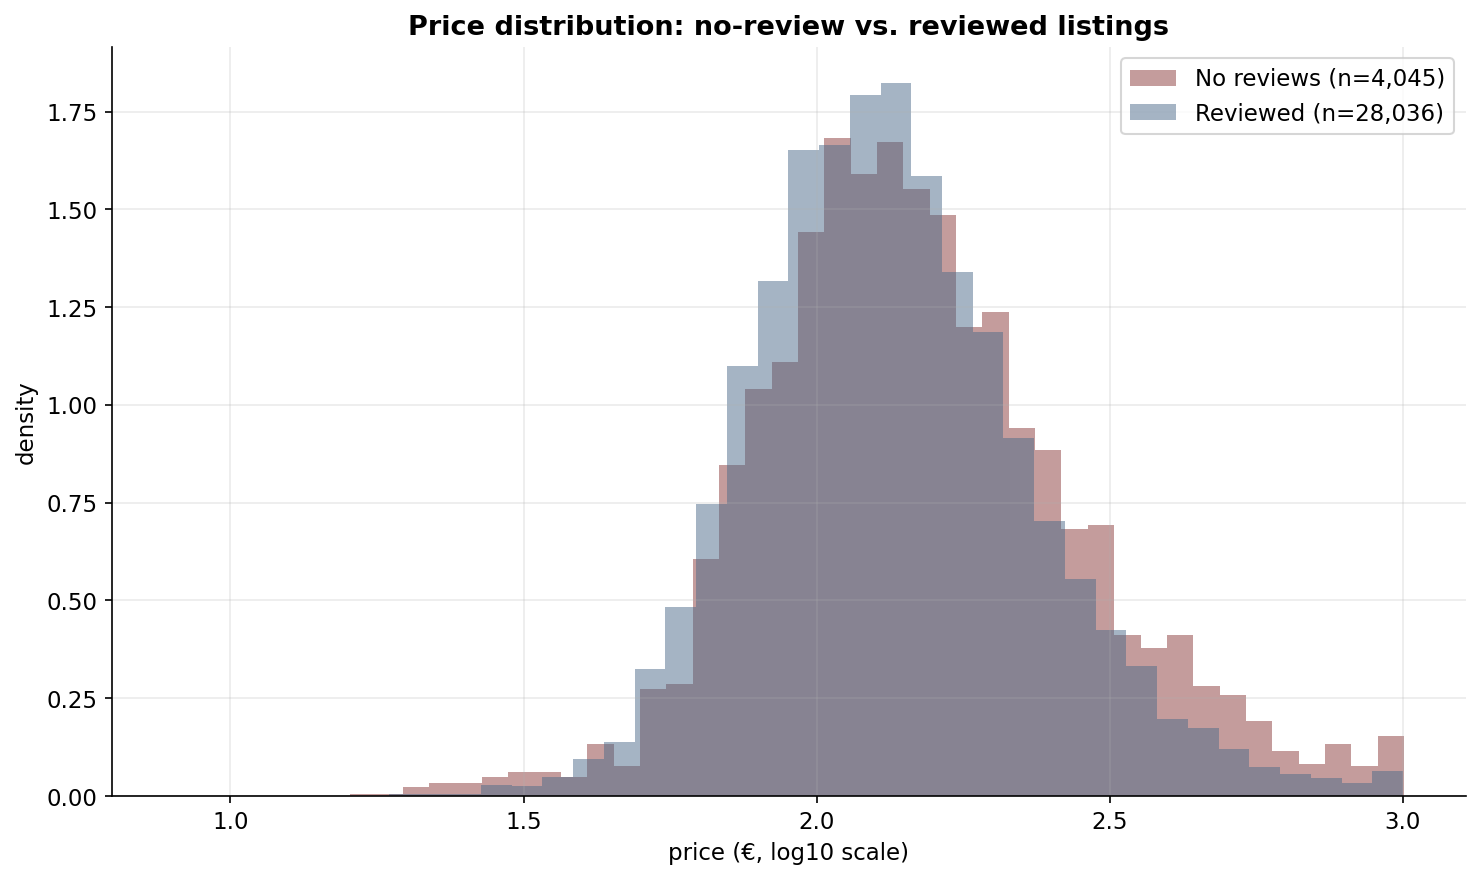

Mann-Whitney U test: p=0.0000000000000000 (significant difference)


In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

for data, label, color in [(listings_no_review['price'].dropna(), 'No reviews', ROME_PALETTE['primary']),
                              (listings_reviewed['price'].dropna(), 'Reviewed', ROME_PALETTE['secondary'])]:
    log_data = np.log10(data[data > 0])
    ax.hist(log_data, bins=40, alpha=0.5, density=True, label=f'{label} (n={len(data):,})', color=color)

ax.set_xlabel('price (€, log10 scale)')
ax.set_ylabel('density')
ax.set_title('Price distribution: no-review vs. reviewed listings')
ax.legend()
plt.tight_layout()
plt.show()

from scipy.stats import mannwhitneyu
stat, pval = mannwhitneyu(listings_no_review['price'].dropna(), listings_reviewed['price'].dropna())
print(f"Mann-Whitney U test: p={pval:.16f} ({'significant' if pval < 0.05 else 'not significant'} difference)")

### 2.3 Property Type & Structure Comparison

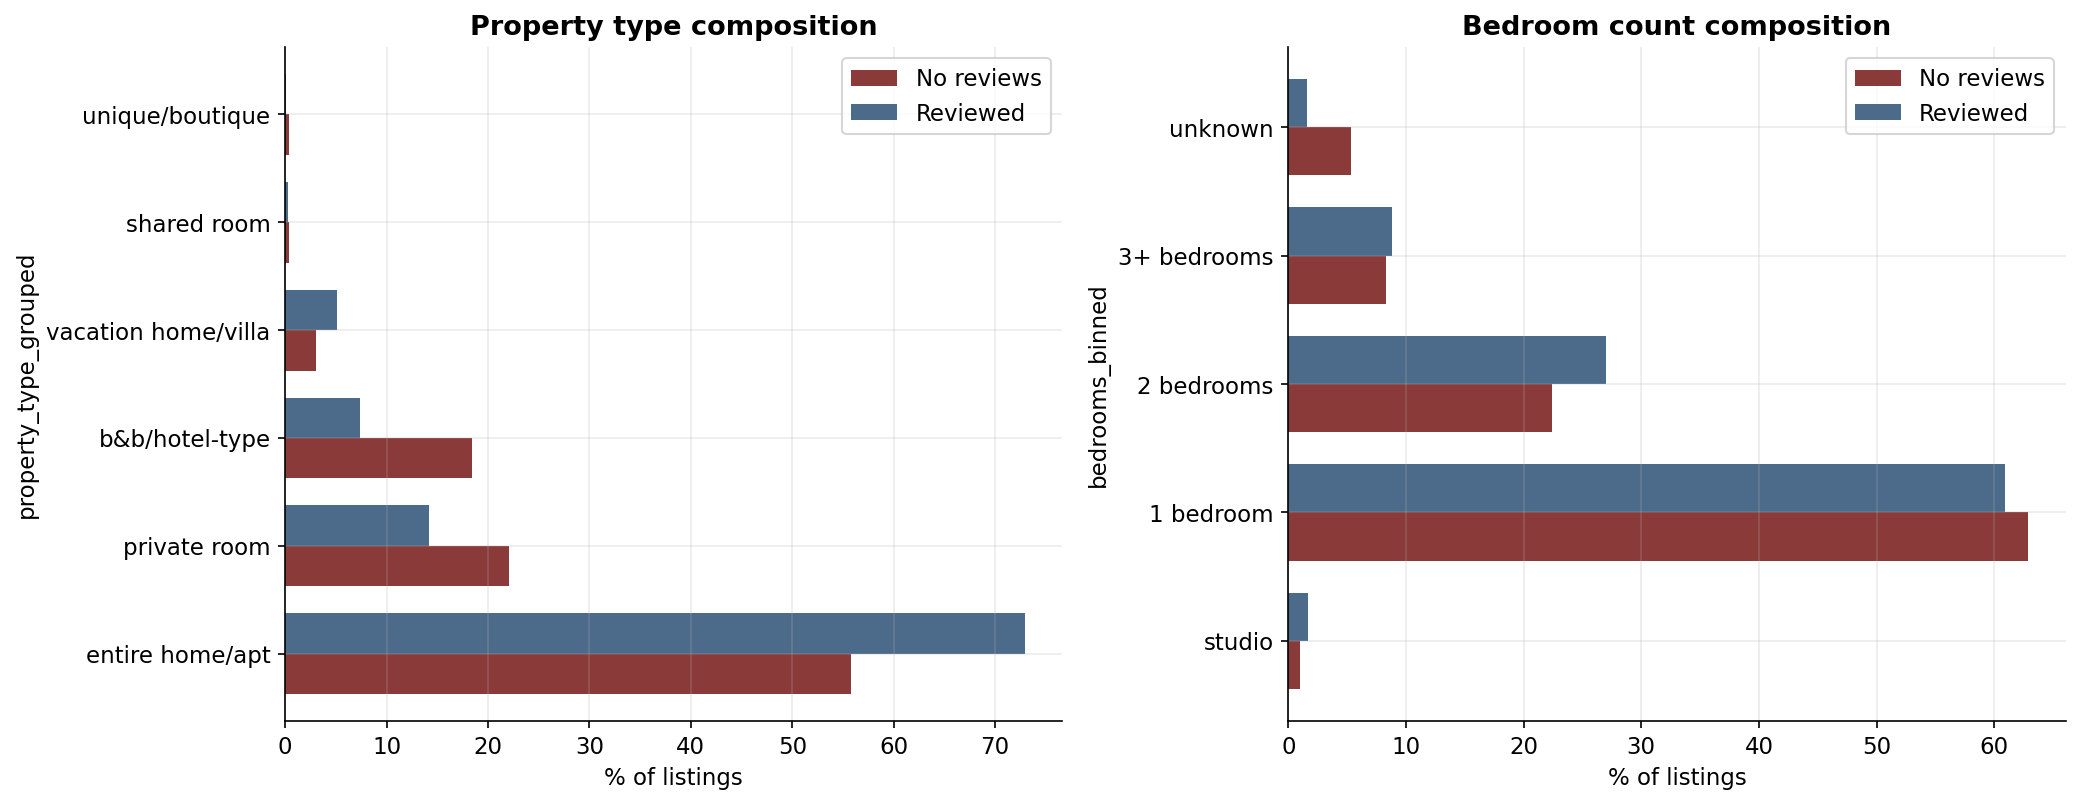

,No reviews,Reviewed
property_type_grouped,,
entire home/apt,55.7,73.0
private room,22.1,14.2
b&b/hotel-type,18.4,7.4
vacation home/villa,3.0,5.1
shared room,0.4,0.3
unique/boutique,0.3,0.1


,No reviews,Reviewed
bedrooms_binned,,
studio,1.0,1.7
1 bedroom,62.9,60.9
2 bedrooms,22.4,27.0
3+ bedrooms,8.3,8.8
unknown,5.4,1.6


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

no_review_prop = listings_no_review['property_type_grouped'].str.lower().value_counts(normalize=True).mul(100)
reviewed_prop = listings_reviewed['property_type_grouped'].value_counts(normalize=True).mul(100)

prop_compare = pd.DataFrame({'No reviews': no_review_prop, 'Reviewed': reviewed_prop}).fillna(0)
prop_compare.plot(kind='barh', ax=axes[0], color=[ROME_PALETTE['primary'], ROME_PALETTE['secondary']], width=0.75)
axes[0].set_xlabel('% of listings')
axes[0].set_title('Property type composition')

no_review_bed = listings_no_review['bedrooms_binned'].str.lower().value_counts(normalize=True).mul(100)
reviewed_bed = listings_reviewed['bedrooms_binned'].value_counts(normalize=True).mul(100)
bed_order = [b for b in ['studio', '1 bedroom', '2 bedrooms', '3+ bedrooms', 'unknown'] if b in no_review_bed.index or b in reviewed_bed.index]

bed_compare = pd.DataFrame({'No reviews': no_review_bed, 'Reviewed': reviewed_bed}).reindex(bed_order).fillna(0)
bed_compare.plot(kind='barh', ax=axes[1], color=[ROME_PALETTE['primary'], ROME_PALETTE['secondary']], width=0.75)
axes[1].set_xlabel('% of listings')
axes[1].set_title('Bedroom count composition')

plt.tight_layout()
plt.show()

display(prop_compare.round(1))
display(bed_compare.round(1))

Property type shows a structural difference: no-review listings skew toward B&B/hotel-type and private rooms, while the reviewed population is more concentrated in entire home/apt. This makes sense alongside the earlier portfolio-size finding: B&B/hotel-type listings often belong to small commercial operations, which may list many units at once, structurally diluting how quickly any single one accumulates its first reviews. Bedroom count, by contrast, shows almost no difference between the two populations.

### 2.4 Geographic Distribution Comparison

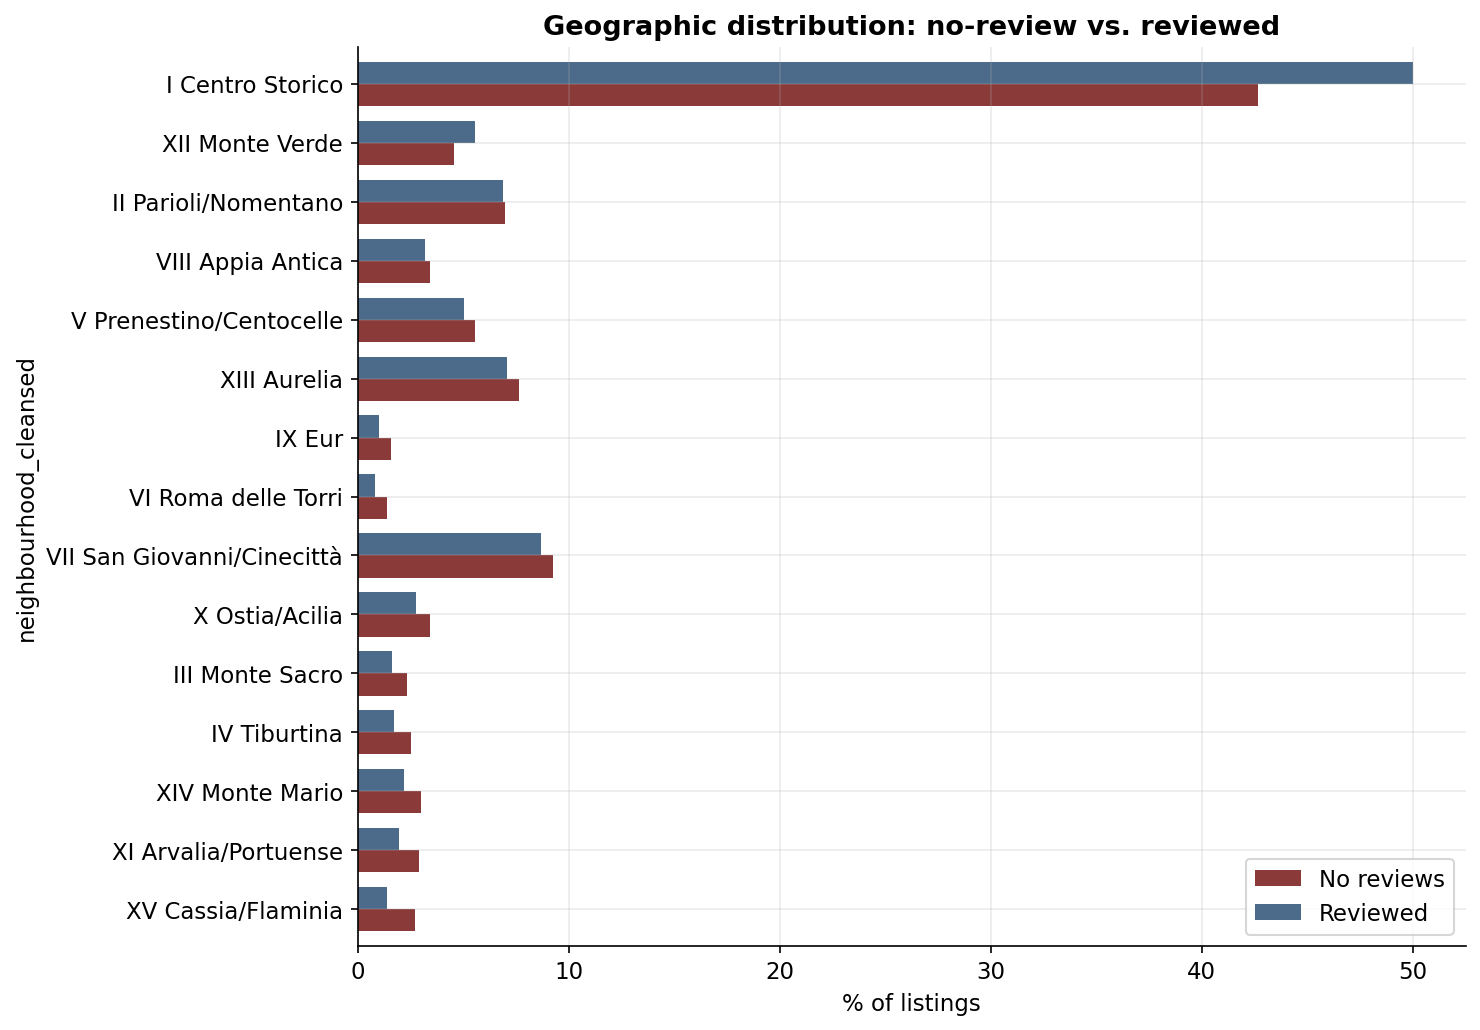

,No reviews,Reviewed,difference
neighbourhood_cleansed,,,
XV Cassia/Flaminia,2.7,1.4,1.3
XI Arvalia/Portuense,2.9,2.0,0.9
XIV Monte Mario,3.0,2.2,0.8
IV Tiburtina,2.5,1.7,0.8
III Monte Sacro,2.3,1.7,0.7
X Ostia/Acilia,3.4,2.8,0.7
VII San Giovanni/Cinecittà,9.3,8.7,0.6
VI Roma delle Torri,1.4,0.8,0.6
IX Eur,1.6,1.0,0.6


In [21]:
no_review_geo = listings_no_review['neighbourhood_cleansed'].value_counts(normalize=True).mul(100)
reviewed_geo = listings_reviewed['neighbourhood_cleansed'].value_counts(normalize=True).mul(100)

geo_compare = pd.DataFrame({'No reviews': no_review_geo, 'Reviewed': reviewed_geo}).fillna(0)
geo_compare['difference'] = geo_compare['No reviews'] - geo_compare['Reviewed']
geo_compare = geo_compare.sort_values('difference', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
geo_compare[['No reviews', 'Reviewed']].plot(kind='barh', ax=ax, color=[ROME_PALETTE['primary'], ROME_PALETTE['secondary']], width=0.75)
ax.set_xlabel('% of listings')
ax.set_title('Geographic distribution: no-review vs. reviewed')
plt.tight_layout()
plt.show()

display(geo_compare.round(1))

Geographic distribution is largely flat. Most municipi differ by under 1 percentage point between the two populations, with one meaningful exception: **I Centro Storico is under-represented among no-review listings by 7.3 points**,. This is the single clearest geographic signal in this comparison: the market's densest and most saturated district, is where a new listing has the hardest time staying review-less, plausibly because it's also the most search-visible, most frequently booked area, so listings there accumulate their first review fastest. No-review listings correspondingly skew slightly toward every other municipio, spread thinly rather than concentrated in any one peripheral area.

### 2.5 Host & Stay-Orientation Check

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_67614/3956479842.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(portfolio_data, labels=['No reviews', 'Reviewed'], showfliers=False)


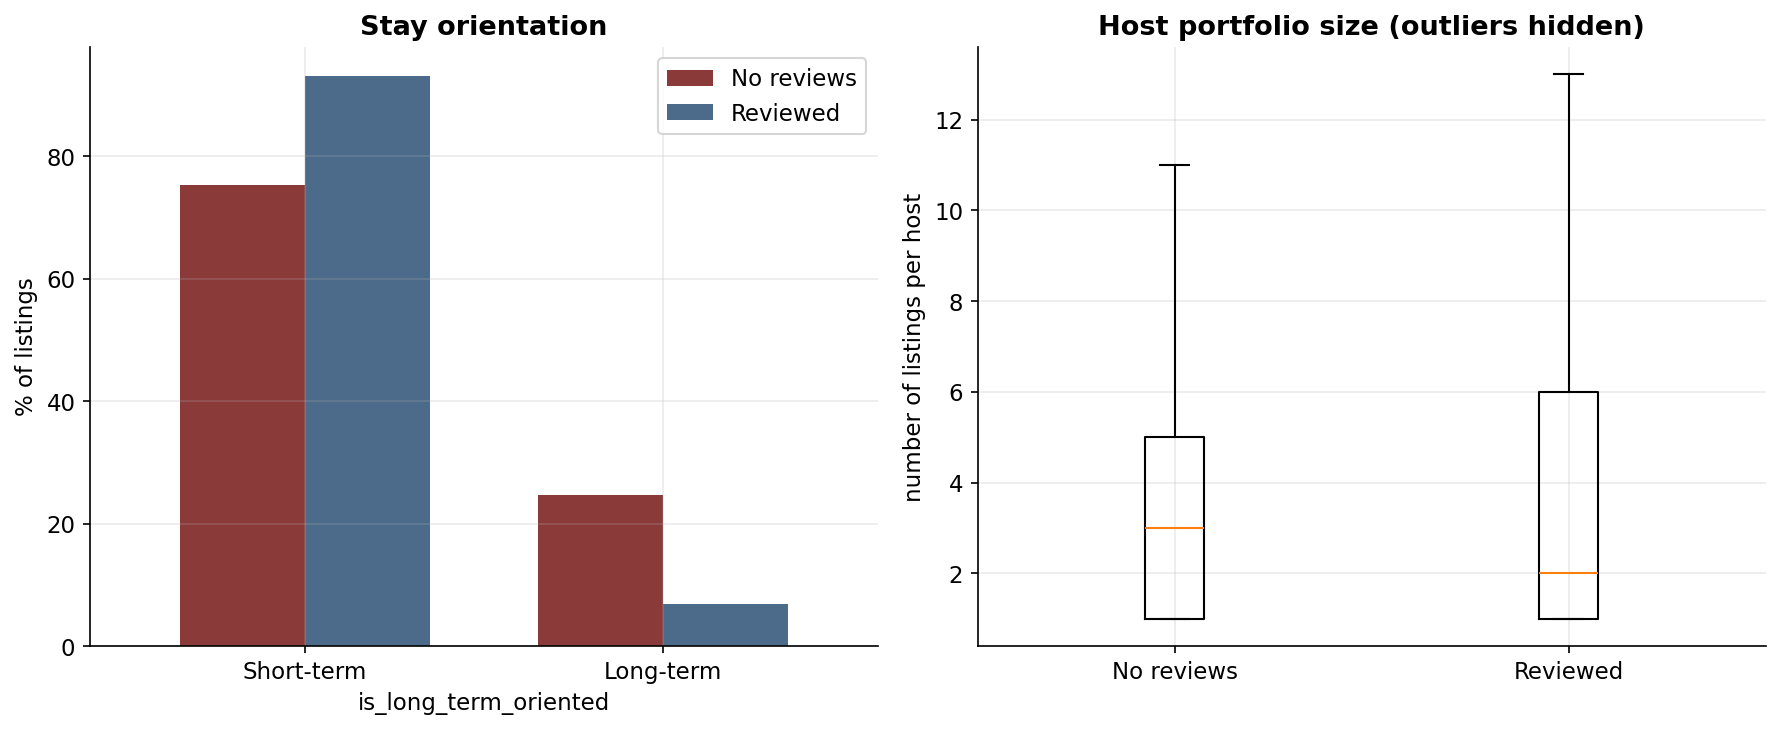

,No reviews,Reviewed
is_long_term_oriented,,
Short-term,75.3,93.2
Long-term,24.7,6.8


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lt_compare = pd.DataFrame({
    'No reviews': listings_no_review['is_long_term_oriented'].value_counts(normalize=True).mul(100),
    'Reviewed': listings_reviewed['is_long_term_oriented'].value_counts(normalize=True).mul(100),
}).rename(index={0: 'Short-term', 1: 'Long-term'})
lt_compare.plot(kind='bar', ax=axes[0], color=[ROME_PALETTE['primary'], ROME_PALETTE['secondary']], width=0.7)
axes[0].set_title('Stay orientation')
axes[0].set_ylabel('% of listings')
axes[0].tick_params(axis='x', rotation=0)

portfolio_data = [
    listings_no_review['calculated_host_listings_count_log'].apply(np.expm1),
    listings_reviewed['calculated_host_listings_count_log'].apply(np.expm1),
]
axes[1].boxplot(portfolio_data, labels=['No reviews', 'Reviewed'], showfliers=False)
axes[1].set_title('Host portfolio size (outliers hidden)')
axes[1].set_ylabel('number of listings per host')

plt.tight_layout()
plt.show()

display(lt_compare.round(1))

Long-term orientation is the sharpest structural signal found in this comparison: 24.7% of no-review listings are long-term oriented, versus just 6.8% of reviewed listings. This directly explains the "no-review" mechanism itself: `is_long_term_oriented` was built in feature engineering around a ~28-30 day minimum-stay threshold, and Airbnb's own review system requires a completed stay before a guest can leave one. A month-plus minimum stay structurally produces far fewer completed bookings per unit time than a 1-3 night listing, so slower review accumulation is a direct consequence of how the listing is offered.

Portfolio size, however, runs in the *opposite* direction from the boxplot's visual impression: no-review listings show a **higher** median (3 vs. 2), even though the reviewed population's box stretches to a higher upper quartile and whisker. Both facts are true simultaneously: no-review hosts are more uniformly mid-sized operators, while reviewed listings include both more single-unit hosts *and* more large operators.

### 2.6 No-Review Strata Summary

The 14.2% of listings with no reviews differ from the reviewed population across several dimensions at once: they're modestly higher-priced, sit slightly further from the center, skew toward B&B/hotel-type and private-room configurations, and are somewhat under-represented in I Centro Storico specifically. The clearest single driver is stay orientation, which only accounts for a minority of the no-review population.

These listings are set aside from the clustering that follows, since their defining trait is an absence rather than a comparable market position, and mixing that structural difference into the same distance calculation risks building a cluster around it instead of genuine segmentation.

## 3. Geography Resolution

The feature set carries two ways to encode a listing's location: `geo_sector` (8 balanced compass directions) and `neighbourhood_cleansed` (15 administrative municipi). This section runs the empirical comparison on the feature set: two backbone variants, differing only in geography, compared across a full k-sweep on both cost and Gower-based silhouette.

### 3.1 Setup the Two Backbone Variants

In [23]:
backbone_continuous_cols = [c for c in continuous_cols if c in TABULAR_STRUCTURAL_COLS]
backbone_categorical_cols = [c for c in categorical_cols if c in TABULAR_STRUCTURAL_COLS]
backbone_binary_cols = [c for c in binary_cols if c in TABULAR_STRUCTURAL_COLS]

print(f"backbone continuous: {len(backbone_continuous_cols)}")
print(f"backbone categorical: {len(backbone_categorical_cols)}")
print(f"backbone binary: {len(backbone_binary_cols)}")

# Variant A: neighbourhood_cleansed instead of geo_sector
backbone_categorical_cols_A = [c for c in backbone_categorical_cols if c != 'geo_sector'] + ['neighbourhood_cleansed']
# Variant B: geo_sector (the current default)
backbone_categorical_cols_B = backbone_categorical_cols

print(f"\nVariant A (neighbourhood_cleansed): {len(backbone_categorical_cols_A)} categorical cols")
print(f"Variant B (geo_sector): {len(backbone_categorical_cols_B)} categorical cols")

listings_reviewed['neighbourhood_cleansed'] = neighbourhood_cleansed.loc[listings_reviewed.index].str.lower()
print(f"\nneighbourhood_cleansed sample values: {sorted(listings_reviewed['neighbourhood_cleansed'].unique())[:3]}...")

backbone continuous: 14
backbone categorical: 7
backbone binary: 14

Variant A (neighbourhood_cleansed): 7 categorical cols
Variant B (geo_sector): 7 categorical cols

neighbourhood_cleansed sample values: ['i centro storico', 'ii parioli/nomentano', 'iii monte sacro']...


### 3.2 Build Both Matrices

In [25]:
def build_kproto_matrix(continuous_cols_list, categorical_cols_list, binary_cols_list, source_df):
    """Assembles a combined DataFrame + categorical index list for KPrototypes."""
    X_cat = source_df[categorical_cols_list + binary_cols_list].copy()
    for col in binary_cols_list:
        X_cat[col] = X_cat[col].astype(int).astype(str)

    X_cont = source_df[continuous_cols_list].copy()
    scaler_local = StandardScaler()
    X_cont_scaled = pd.DataFrame(
        scaler_local.fit_transform(X_cont),
        columns=continuous_cols_list,
        index=source_df.index
    )

    X_comb = pd.concat([X_cont_scaled, X_cat], axis=1)
    cat_idx = list(range(len(continuous_cols_list), X_comb.shape[1]))
    return X_comb, cat_idx

X_backbone_A, cat_idx_A = build_kproto_matrix(
    backbone_continuous_cols, backbone_categorical_cols_A, backbone_binary_cols, listings_reviewed
)
X_backbone_B, cat_idx_B = build_kproto_matrix(
    backbone_continuous_cols, backbone_categorical_cols_B, backbone_binary_cols, listings_reviewed
)

print(f"X_backbone_A (neighbourhood_cleansed): {X_backbone_A.shape}, categorical indices {cat_idx_A[0]}-{cat_idx_A[-1]}")
print(f"X_backbone_B (geo_sector): {X_backbone_B.shape}, categorical indices {cat_idx_B[0]}-{cat_idx_B[-1]}")

print(f"\nshapes match: {X_backbone_A.shape == X_backbone_B.shape}")

X_backbone_A (neighbourhood_cleansed): (30718, 35), categorical indices 14-34
X_backbone_B (geo_sector): (30718, 35), categorical indices 14-34

shapes match: True


### 3.3 K-Sweep for Both Variants 

In [26]:
from kmodes.kprototypes import KPrototypes
import time

K_RANGE = range(3, 11)
sweep_results = {'A': {}, 'B': {}}

for variant, (X_variant, cat_idx) in [('A', (X_backbone_A, cat_idx_A)), ('B', (X_backbone_B, cat_idx_B))]:
    print(f"\n=== Variant {variant} ===")
    for k in K_RANGE:
        start = time.time()
        kproto = KPrototypes(n_clusters=k, init='Huang', n_init=1, random_state=42, n_jobs=-1)
        labels = kproto.fit_predict(X_variant.to_numpy(), categorical=cat_idx)
        elapsed = time.time() - start

        sweep_results[variant][k] = {'cost': kproto.cost_, 'labels': labels}
        print(f"  k={k}: cost={kproto.cost_:.1f}, {elapsed:.1f}s")


=== Variant A ===
  k=3: cost=410093.4, 28.9s
  k=4: cost=389424.1, 33.5s
  k=5: cost=371400.3, 46.6s
  k=6: cost=358044.3, 61.6s
  k=7: cost=348335.4, 37.2s
  k=8: cost=337622.6, 106.5s
  k=9: cost=331316.0, 54.1s
  k=10: cost=322981.4, 71.5s

=== Variant B ===
  k=3: cost=414523.3, 26.9s
  k=4: cost=393807.6, 32.4s
  k=5: cost=375623.8, 48.4s
  k=6: cost=362441.2, 110.9s
  k=7: cost=352459.9, 34.8s
  k=8: cost=344492.0, 49.5s
  k=9: cost=335402.8, 70.0s
  k=10: cost=327374.3, 61.4s


### 3.4 Stratified Sampling & Gower Silhouette

In [27]:
import gower
from sklearn.metrics import silhouette_score

SAMPLE_SIZE = 8000
MIN_PER_CLUSTER = 30

def stratified_sample_indices(labels, sample_size=SAMPLE_SIZE, min_per_cluster=MIN_PER_CLUSTER, random_state=42):
    """Proportional stratified sample by cluster label, with a floor per cluster
    so rare segments survive the sample even if their proportional share would round to ~0."""
    rng = np.random.RandomState(random_state)
    labels_series = pd.Series(labels)
    cluster_sizes = labels_series.value_counts()

    sampled_idx = []
    for cluster_id, size in cluster_sizes.items():
        proportional_n = int(round(sample_size * size / len(labels_series)))
        n_to_sample = max(min_per_cluster, proportional_n)
        n_to_sample = min(n_to_sample, size)
        cluster_idx = labels_series[labels_series == cluster_id].index.to_numpy()
        chosen = rng.choice(cluster_idx, size=n_to_sample, replace=False)
        sampled_idx.extend(chosen)

    return np.array(sampled_idx)


def compute_gower_silhouette(X_variant, cat_idx, labels, sample_idx):
    """Computes Gower distance + silhouette on a sample, with categorical columns
    passed explicitly — gower's auto-detection via np.issubdtype breaks on
    pandas 3.x's native StringDtype, so we bypass it entirely."""
    X_sample = X_variant.iloc[sample_idx]
    labels_sample = labels[sample_idx]

    cat_features_mask = np.zeros(X_sample.shape[1], dtype=bool)
    cat_features_mask[cat_idx] = True

    gower_dist = gower.gower_matrix(X_sample, cat_features=cat_features_mask)
    return silhouette_score(gower_dist, labels_sample, metric='precomputed'), len(sample_idx)


for variant, (X_variant, cat_idx) in [('A', (X_backbone_A, cat_idx_A)), ('B', (X_backbone_B, cat_idx_B))]:
    print(f"\n=== Variant {variant} ===")
    for k in K_RANGE:
        labels = sweep_results[variant][k]['labels']
        sample_idx = stratified_sample_indices(labels)

        sil_score, n_sampled = compute_gower_silhouette(X_variant, cat_idx, labels, sample_idx)

        sweep_results[variant][k]['silhouette'] = sil_score
        sweep_results[variant][k]['sample_size'] = n_sampled
        print(f"  k={k}: silhouette={sil_score:.4f} (sample n={n_sampled})")


=== Variant A ===
  k=3: silhouette=0.0810 (sample n=8000)
  k=4: silhouette=0.0573 (sample n=8000)
  k=5: silhouette=0.0530 (sample n=8000)
  k=6: silhouette=0.0361 (sample n=8000)
  k=7: silhouette=0.0347 (sample n=8001)
  k=8: silhouette=0.0323 (sample n=8001)
  k=9: silhouette=0.0259 (sample n=8000)
  k=10: silhouette=0.0184 (sample n=8001)

=== Variant B ===
  k=3: silhouette=0.0801 (sample n=8000)
  k=4: silhouette=0.0515 (sample n=8000)
  k=5: silhouette=0.0499 (sample n=8000)
  k=6: silhouette=0.0361 (sample n=8000)
  k=7: silhouette=0.0351 (sample n=8001)
  k=8: silhouette=0.0253 (sample n=8000)
  k=9: silhouette=0.0249 (sample n=8000)
  k=10: silhouette=0.0221 (sample n=7998)


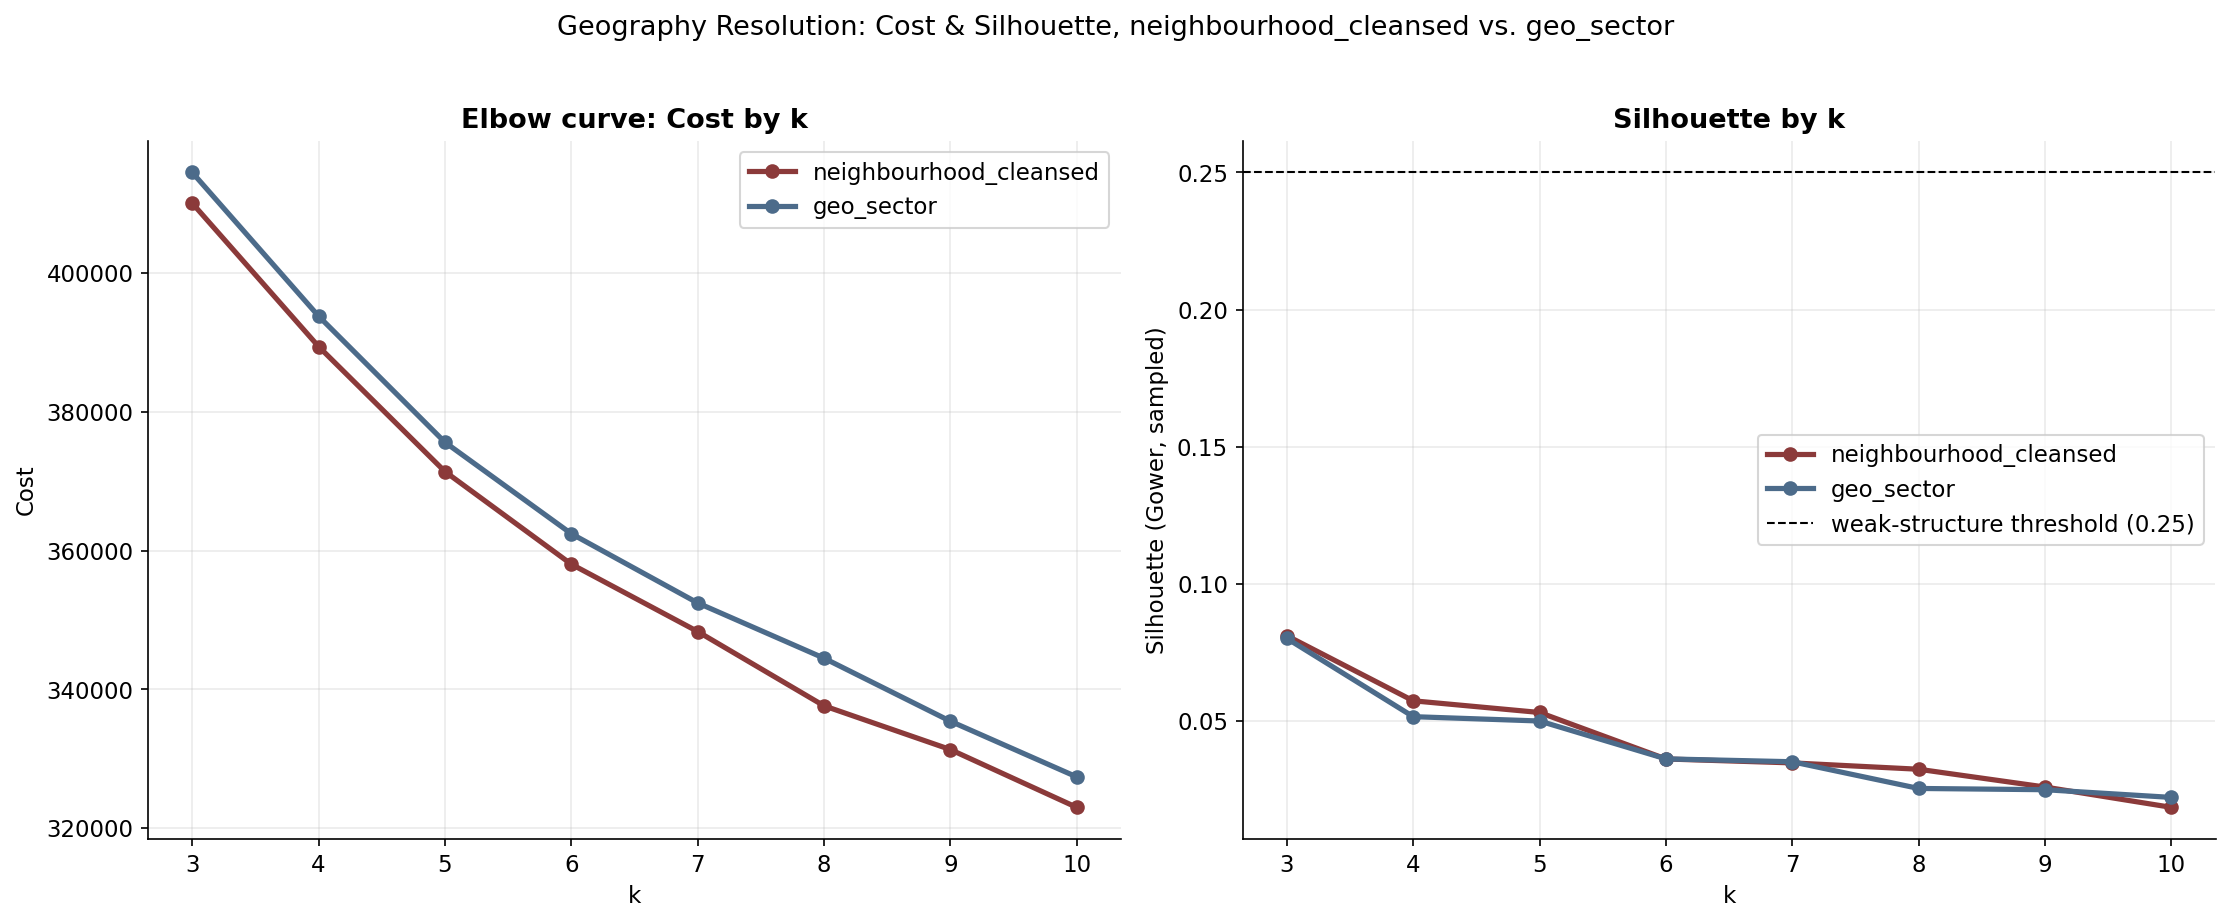

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for variant, color, label in [('A', ROME_PALETTE['primary'], 'neighbourhood_cleansed'),
                                ('B', ROME_PALETTE['secondary'], 'geo_sector')]:
    costs = [sweep_results[variant][k]['cost'] for k in K_RANGE]
    axes[0].plot(list(K_RANGE), costs, marker='o', color=color, linewidth=2.5, label=label)

axes[0].set_xlabel('k')
axes[0].set_ylabel('Cost')
axes[0].set_title('Elbow curve: Cost by k')
axes[0].set_xticks(list(K_RANGE))
axes[0].legend()

for variant, color, label in [('A', ROME_PALETTE['primary'], 'neighbourhood_cleansed'),
                                ('B', ROME_PALETTE['secondary'], 'geo_sector')]:
    sils = [sweep_results[variant][k]['silhouette'] for k in K_RANGE]
    axes[1].plot(list(K_RANGE), sils, marker='o', color=color, linewidth=2.5, label=label)

axes[1].axhline(0.25, color='black', linestyle='--', linewidth=1, label='weak-structure threshold (0.25)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette (Gower, sampled)')
axes[1].set_title('Silhouette by k')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

plt.suptitle('Geography Resolution: Cost & Silhouette, neighbourhood_cleansed vs. geo_sector', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Both geo variants produce nearly identical cost and silhouette curves at every k, a difference of 0.001-0.006 in silhouette, far smaller than the variation across k itself. Silhouette peaks at k=3 for both (≈0.08) and declines monotonically as k grows, staying well below the conventional 0.25 threshold for weak-but-real structure across the whole range, being a further sign of how little geography *encoding* affects cluster separation on its own, meaning that geography's strong in predicting price, not in driving cluster boundaries.

Since neither cost nor silhouette shows a measurable advantage, the deciding factor is practical: `geo_sector`'s 8 balanced categories avoid `neighbourhood_cleansed`'s severe imbalance (I Centro Storico alone holds around half the market). At equal measured quality, the more balanced encoding is preferred. **`geo_sector` is carried forward as the geography input.**

Gamma is left untuned here by design, as both variants ran at the same default value specifically so the comparison isolated the geography choice alone.

## 4. Baseline Tuning

Section 3 resolved the geography input but left gamma at its automatic default for both variants, but not a tuned choice. This section runs a full k×gamma grid on the now-fixed backbone (`geo_sector` + Structure + Host) to find the best-supported configuration before layering any NLP features on top.

### 4.1 Setup the Gamma Range

In [29]:
default_gamma = X_backbone_B[backbone_continuous_cols].std().mean()
print(f"kmodes default gamma (mean std of numeric columns): {default_gamma:.4f}")

GAMMA_RANGE = [default_gamma * m for m in [0.25, 0.5, 1.0, 2.0, 4.0]]
print(f"\ngamma grid: {[round(g, 4) for g in GAMMA_RANGE]}")

kmodes default gamma (mean std of numeric columns): 1.0000

gamma grid: [np.float64(0.25), np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(4.0001)]


### 4.2 Full k×gamma Grid on Backbone

In [30]:
baseline_grid_results = {}

for gamma in GAMMA_RANGE:
    gamma_key = round(gamma, 4)
    baseline_grid_results[gamma_key] = {}
    print(f"\n=== gamma={gamma_key} ===")
    for k in K_RANGE:
        start = time.time()
        kproto = KPrototypes(n_clusters=k, init='Huang', n_init=1, gamma=gamma, random_state=42, n_jobs=-1)
        labels = kproto.fit_predict(X_backbone_B.to_numpy(), categorical=cat_idx_B)
        elapsed = time.time() - start

        baseline_grid_results[gamma_key][k] = {'cost': kproto.cost_, 'labels': labels}
        print(f"  k={k}: cost={kproto.cost_:.1f}, {elapsed:.1f}s")


=== gamma=0.25 ===
  k=3: cost=376890.3, 29.1s
  k=4: cost=356610.0, 65.7s
  k=5: cost=338736.0, 62.0s
  k=6: cost=325570.3, 40.0s
  k=7: cost=315789.2, 44.0s
  k=8: cost=305144.3, 80.7s
  k=9: cost=298200.5, 89.9s
  k=10: cost=291434.7, 59.0s

=== gamma=0.5 ===
  k=3: cost=414524.5, 26.7s
  k=4: cost=393808.8, 33.8s
  k=5: cost=375625.0, 47.1s
  k=6: cost=362442.4, 108.4s
  k=7: cost=352461.1, 33.8s
  k=8: cost=344493.2, 48.6s
  k=9: cost=335403.9, 72.7s
  k=10: cost=327375.5, 60.2s

=== gamma=1.0 ===
  k=3: cost=487849.5, 33.9s
  k=4: cost=468803.6, 36.9s
  k=5: cost=449257.4, 43.0s
  k=6: cost=434929.4, 39.4s
  k=7: cost=426916.4, 52.1s
  k=8: cost=415363.1, 32.3s
  k=9: cost=404602.6, 51.1s
  k=10: cost=399036.0, 102.6s

=== gamma=2.0 ===
  k=3: cost=630925.3, 43.9s
  k=4: cost=606680.5, 48.0s
  k=5: cost=592554.1, 29.7s
  k=6: cost=572007.2, 33.8s
  k=7: cost=557872.3, 33.2s
  k=8: cost=547215.6, 51.8s
  k=9: cost=539727.0, 114.9s
  k=10: cost=530662.8, 63.2s

=== gamma=4.0001 ==

### 4.3 Stratified Sampling + Gower Silhouette

In [31]:
for gamma_key in baseline_grid_results:
    print(f"\n=== gamma={gamma_key} ===")
    for k in K_RANGE:
        labels = baseline_grid_results[gamma_key][k]['labels']
        sample_idx = stratified_sample_indices(labels)

        sil_score, n_sampled = compute_gower_silhouette(X_backbone_B, cat_idx_B, labels, sample_idx)

        baseline_grid_results[gamma_key][k]['silhouette'] = sil_score
        print(f"  k={k}: silhouette={sil_score:.4f} (sample n={n_sampled})")


=== gamma=0.25 ===
  k=3: silhouette=0.0815 (sample n=8000)
  k=4: silhouette=0.0501 (sample n=7999)
  k=5: silhouette=0.0474 (sample n=8000)
  k=6: silhouette=0.0345 (sample n=7999)
  k=7: silhouette=0.0306 (sample n=8000)
  k=8: silhouette=0.0244 (sample n=7999)
  k=9: silhouette=0.0266 (sample n=7999)
  k=10: silhouette=0.0162 (sample n=8000)

=== gamma=0.5 ===
  k=3: silhouette=0.0801 (sample n=8000)
  k=4: silhouette=0.0515 (sample n=8000)
  k=5: silhouette=0.0499 (sample n=8000)
  k=6: silhouette=0.0361 (sample n=8000)
  k=7: silhouette=0.0348 (sample n=8000)
  k=8: silhouette=0.0253 (sample n=8000)
  k=9: silhouette=0.0249 (sample n=8000)
  k=10: silhouette=0.0221 (sample n=7998)

=== gamma=1.0 ===
  k=3: silhouette=0.0770 (sample n=8000)
  k=4: silhouette=0.0591 (sample n=8000)
  k=5: silhouette=0.0609 (sample n=8000)
  k=6: silhouette=0.0428 (sample n=8000)
  k=7: silhouette=0.0335 (sample n=7999)
  k=8: silhouette=0.0372 (sample n=8000)
  k=9: silhouette=0.0377 (sample n=799

In [64]:
kproto_verify = KPrototypes(n_clusters=4, init='Huang', n_init=5, gamma=4.0001, random_state=42, n_jobs=-1)
labels_verify = kproto_verify.fit_predict(X_backbone_B.to_numpy(), categorical=cat_idx_B)

sample_idx_verify = stratified_sample_indices(labels_verify)
sil_verify, n_sampled_verify = compute_gower_silhouette(X_backbone_B, cat_idx_B, labels_verify, sample_idx_verify)

print(f"gamma=4.0001, k=4:")
print(f"  n_init=1 (original): cost={baseline_grid_results[4.0001][4]['cost']:.1f}, silhouette={baseline_grid_results[4.0001][4]['silhouette']:.4f}")
print(f"  n_init=5 (verified): cost={kproto_verify.cost_:.1f}, silhouette={sil_verify:.4f}")

gamma=4.0001, k=4:
  n_init=1 (original): cost=857799.6, silhouette=0.1007
  n_init=5 (verified): cost=857803.9, silhouette=0.1007


### 4.4 Visualization

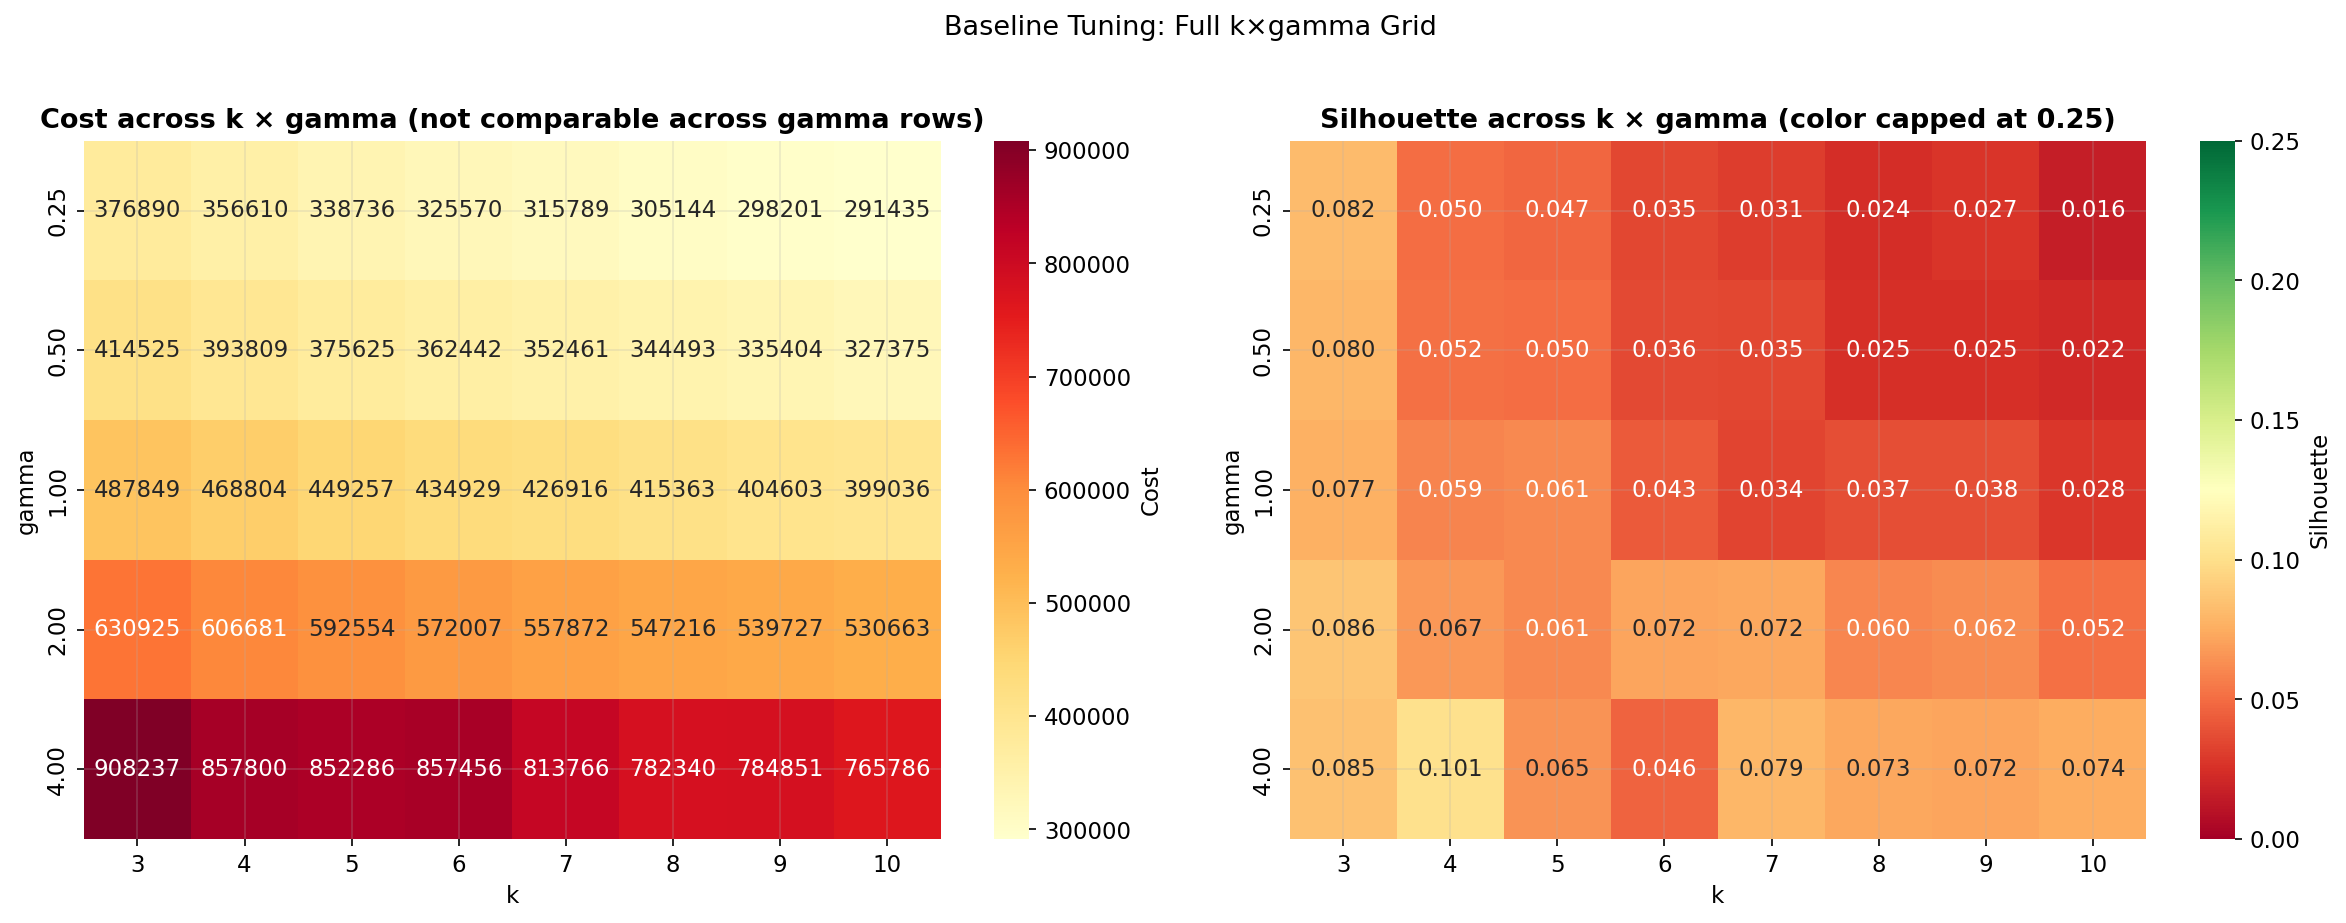

best combination: gamma=4.0001, k=4, silhouette=0.1007


In [69]:
gamma_labels = [f'{g:.2f}' for g in baseline_grid_results.keys()]
k_labels = list(K_RANGE)

cost_matrix = np.array([[baseline_grid_results[g][k]['cost'] for k in K_RANGE] for g in baseline_grid_results])
sil_matrix = np.array([[baseline_grid_results[g][k]['silhouette'] for k in K_RANGE] for g in baseline_grid_results])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cost_matrix, annot=True, fmt='.0f', cmap='YlOrRd', xticklabels=k_labels, yticklabels=gamma_labels,
            ax=axes[0], cbar_kws={'label': 'Cost'})
axes[0].set_xlabel('k')
axes[0].set_ylabel('gamma')
axes[0].set_title('Cost across k × gamma (not comparable across gamma rows)')

sns.heatmap(sil_matrix, annot=True, fmt='.3f', cmap='RdYlGn', xticklabels=k_labels, yticklabels=gamma_labels,
            ax=axes[1], vmin=0, vmax=0.25, cbar_kws={'label': 'Silhouette'})
axes[1].set_xlabel('k')
axes[1].set_ylabel('gamma')
axes[1].set_title('Silhouette across k × gamma (color capped at 0.25)')

plt.suptitle('Baseline Tuning: Full k×gamma Grid', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

best_gamma_key = max(baseline_grid_results, key=lambda g: max(baseline_grid_results[g][k]['silhouette'] for k in K_RANGE))
best_k = max(K_RANGE, key=lambda k: baseline_grid_results[best_gamma_key][k]['silhouette'])
best_sil = baseline_grid_results[best_gamma_key][best_k]['silhouette']
print(f"best combination: gamma={best_gamma_key}, k={best_k}, silhouette={best_sil:.4f}")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/u

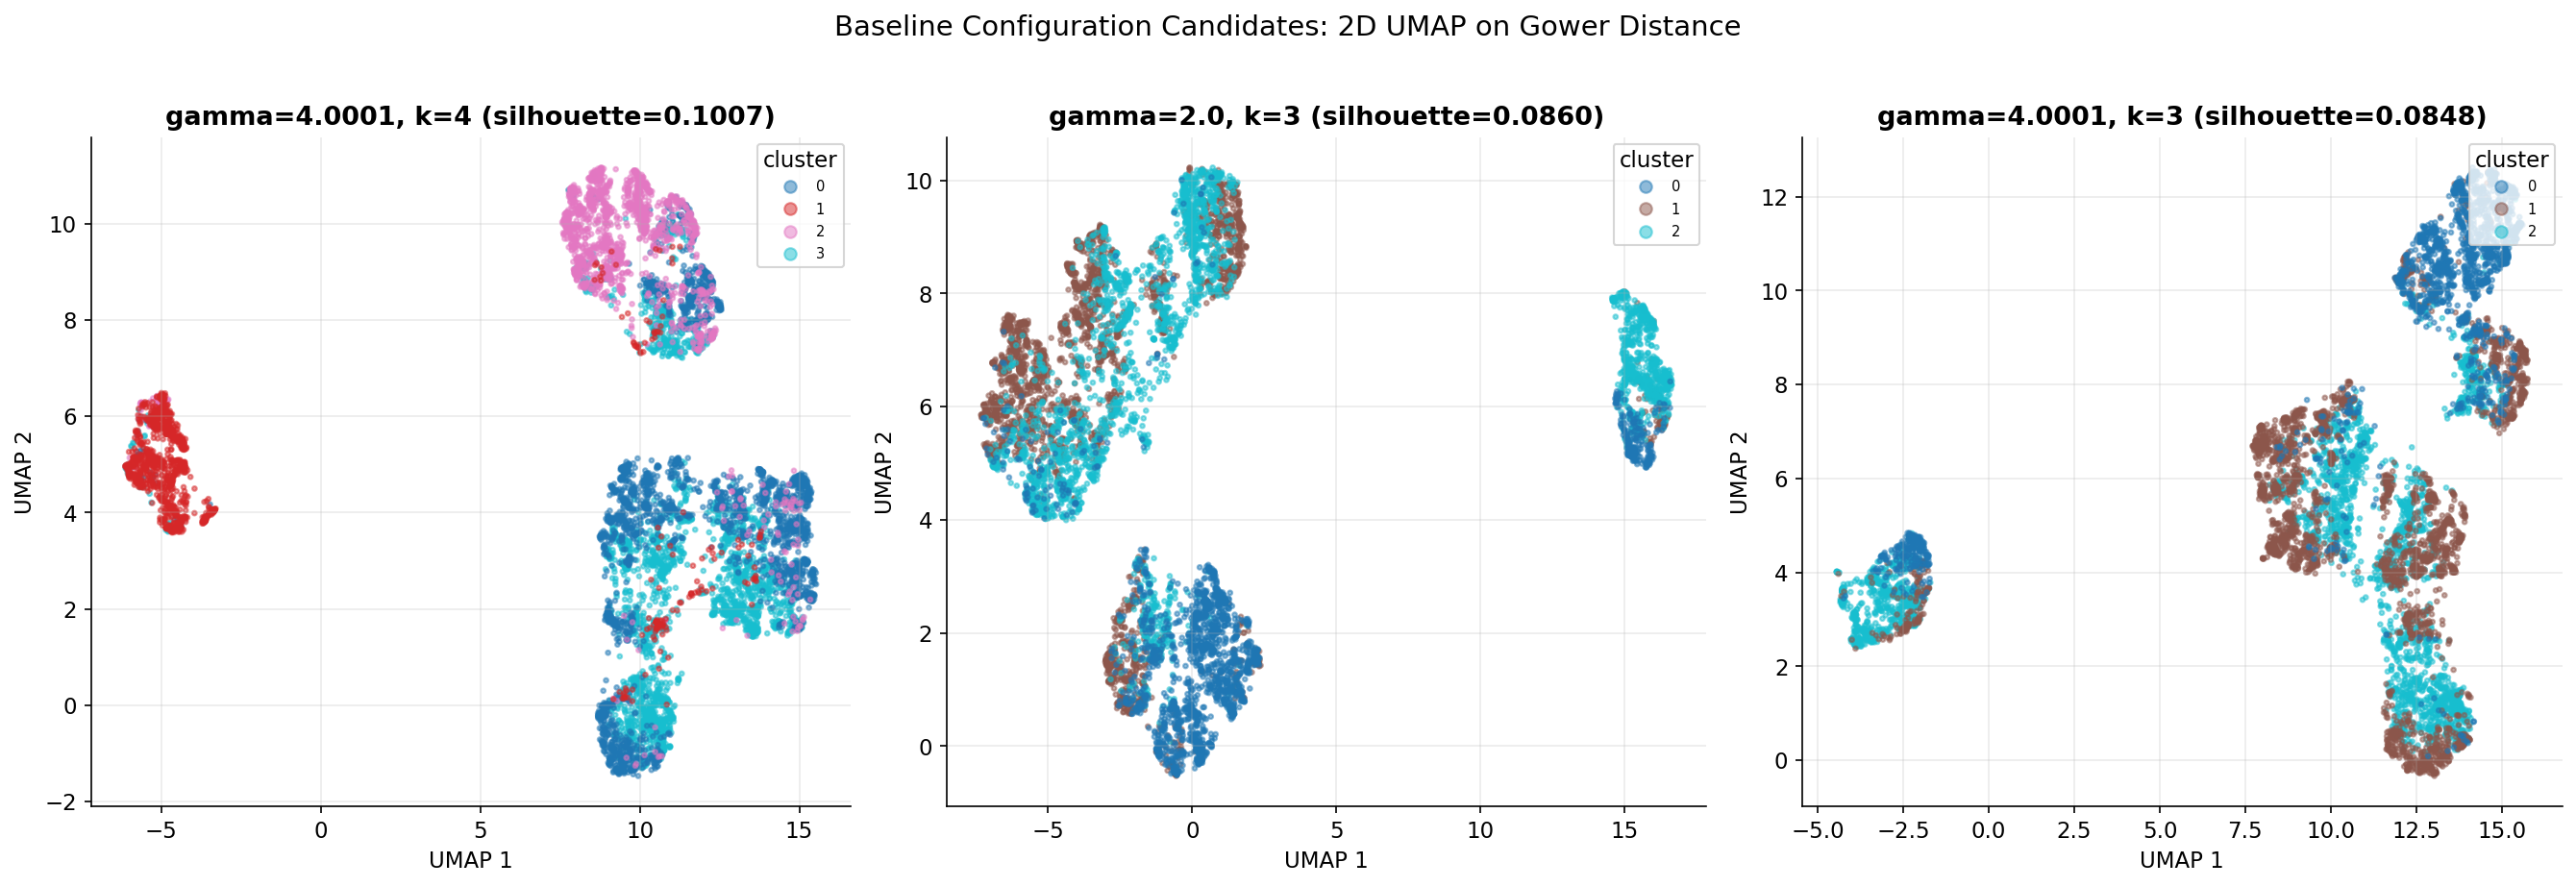

In [70]:
import umap

def visualize_cluster_labels(X_variant, cat_idx, labels, title, sample_size=8000):
    sample_idx = stratified_sample_indices(labels, sample_size=sample_size)
    X_sample = X_variant.iloc[sample_idx]
    labels_sample = labels[sample_idx]

    cat_mask = np.zeros(X_sample.shape[1], dtype=bool)
    cat_mask[cat_idx] = True
    gower_dist = gower.gower_matrix(X_sample, cat_features=cat_mask)

    reducer = umap.UMAP(n_components=2, metric='precomputed', random_state=42)
    embedding = reducer.fit_transform(gower_dist)
    return embedding, labels_sample

CANDIDATES_TO_VISUALIZE = [(4.0001, 4), (2.0, 3), (4.0001, 3)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (gamma, k) in zip(axes, CANDIDATES_TO_VISUALIZE):
    labels = baseline_grid_results[gamma][k]['labels']
    embedding, labels_sample = visualize_cluster_labels(X_backbone_B, cat_idx_B, labels, f'gamma={gamma}, k={k}')

    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=labels_sample, cmap='tab10', s=5, alpha=0.5)
    sil = baseline_grid_results[gamma][k]['silhouette']
    ax.set_title(f'gamma={gamma}, k={k} (silhouette={sil:.4f})')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(*scatter.legend_elements(), title='cluster', loc='upper right', fontsize=7)

plt.suptitle('Baseline Configuration Candidates: 2D UMAP on Gower Distance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

UMAP shows a clear difference between the tested configurations. At gamma=4.0001, k=4, the sample separates into three visually distinct regions with comparatively little color-mixing inside each: a tight, isolated red cluster, a pink/cyan pair sharing the upper area, and a blue cluster below. The other two candidates tested at similar silhouette levels (gamma=2.0 k=3, gamma=4.0001 k=3) show far more intermixing between colors within their sub-blobs. The higher silhouette at gamma=4.0001, k=4 corresponds to a genuinely cleaner visual separation, not just a better number.

`gamma=4.0001`, `k=4` is the baseline configuration. It's confirmed stable under repeated random initialization (n_init=5 reproduces the same cost and silhouette exactly), and separates the sample into the most visually distinct regions of any configuration tested.

**Baseline Configuration, fixed going forward**: features = `geo_sector` + Structure + Host (35 columns), `k=4`, `gamma=4.0001`.

## 5. NLP Feature Experiments

This section asks the main question: does text change that picture? Two NLP feature groups are layered onto the fixed baseline separately - embeddings/persona and tone/topic stylometry plus the full combination, each run through the same k-sweep at the baseline's tuned `gamma=4.0`.

### 5.1 Setup the NLP Feature Groups

In [71]:
EMBEDDING_PERSONA_COLS = {c for c in NLP_COLS if c.startswith('embedding_pc') or c in {'text_persona', 'n_embedded_reviews'}}

CONTENT_FLAG_COLS = {c for c in NLP_COLS if c in binary_cols and c.startswith('has_') and c != 'has_no_neutral_sentiment'}

NLP_CORE_COLS = NLP_COLS - EMBEDDING_PERSONA_COLS - CONTENT_FLAG_COLS

print(f"NLP core (tone/topic/sentiment, no flags, no embeddings): {len(NLP_CORE_COLS)} columns")
print(f"Content flags (has_X binary): {len(CONTENT_FLAG_COLS)} columns")
for col in sorted(CONTENT_FLAG_COLS):
    print(f"  {col}")
print(f"Embeddings/persona: {len(EMBEDDING_PERSONA_COLS)} columns")

all_three = NLP_CORE_COLS | CONTENT_FLAG_COLS | EMBEDDING_PERSONA_COLS
assert all_three == NLP_COLS, f"mismatch: {NLP_COLS - all_three} missing, {all_three - NLP_COLS} extra"
assert len(NLP_CORE_COLS) + len(CONTENT_FLAG_COLS) + len(EMBEDDING_PERSONA_COLS) == len(NLP_COLS)
print(f"\nthree groups reconstruct NLP_COLS exactly ({len(NLP_COLS)} total)")

NLP core (tone/topic/sentiment, no flags, no embeddings): 83 columns
Content flags (has_X binary): 11 columns
  has_description_self_ref
  has_host_about_atmosphere_lively
  has_host_about_atmosphere_quiet
  has_host_about_budget
  has_host_about_luxury
  has_host_about_professionalism
  has_neighborhood_overview_budget
  has_neighborhood_overview_exclaim
  has_neighborhood_overview_family
  has_neighborhood_overview_romantic
  has_neighborhood_overview_self_ref
Embeddings/persona: 12 columns

three groups reconstruct NLP_COLS exactly (106 total)


### 5.2 Build the Experiment Matrices

In [72]:
def build_experiment_matrix(extra_cols_set, source_df):
    """Backbone (geo_sector) + a given NLP column set, split by dtype and
    assembled the same way as build_kproto_matrix throughout this notebook."""
    extra_cont = [c for c in extra_cols_set if c in continuous_cols]
    extra_cat = [c for c in extra_cols_set if c in categorical_cols]
    extra_bin = [c for c in extra_cols_set if c in binary_cols]

    continuous_list = backbone_continuous_cols + extra_cont
    categorical_list = backbone_categorical_cols_B + extra_cat  
    binary_list = backbone_binary_cols + extra_bin

    return build_kproto_matrix(continuous_list, categorical_list, binary_list, source_df)

EXPERIMENTS_NLP_COLS = {
    'Exp1_nlp_core': NLP_CORE_COLS,
    'Exp2_core_flags': NLP_CORE_COLS | CONTENT_FLAG_COLS,
    'Exp3_core_embed': NLP_CORE_COLS | EMBEDDING_PERSONA_COLS,
    'Exp4_full': NLP_CORE_COLS | CONTENT_FLAG_COLS | EMBEDDING_PERSONA_COLS,
}

experiment_matrices = {}
for exp_name, col_set in EXPERIMENTS_NLP_COLS.items():
    X_exp, cat_idx_exp = build_experiment_matrix(col_set, listings_reviewed)
    experiment_matrices[exp_name] = (X_exp, cat_idx_exp)
    print(f"{exp_name}: {X_exp.shape} ({len(col_set)} NLP columns added to backbone)")

print(f"\nBaseline (§4) shape for reference: {X_backbone_B.shape}")

Exp1_nlp_core: (30718, 118) (83 NLP columns added to backbone)
Exp2_core_flags: (30718, 129) (94 NLP columns added to backbone)
Exp3_core_embed: (30718, 130) (95 NLP columns added to backbone)
Exp4_full: (30718, 141) (106 NLP columns added to backbone)

Baseline (§4) shape for reference: (30718, 35)


### 5.3 K-Sweep for Each Experiment

In [73]:
FIXED_GAMMA = 4.0001
nlp_sweep_results = {}

for exp_name, (X_exp, cat_idx) in experiment_matrices.items():
    nlp_sweep_results[exp_name] = {}
    print(f"\n=== {exp_name} ===")
    for k in K_RANGE:
        start = time.time()
        kproto = KPrototypes(n_clusters=k, init='Huang', n_init=1, gamma=FIXED_GAMMA, random_state=42, n_jobs=-1)
        labels = kproto.fit_predict(X_exp.to_numpy(), categorical=cat_idx)
        elapsed = time.time() - start

        nlp_sweep_results[exp_name][k] = {'cost': kproto.cost_, 'labels': labels}
        print(f"  k={k}: cost={kproto.cost_:.1f}, {elapsed:.1f}s")


=== Exp1_nlp_core ===
  k=3: cost=3972792.0, 28.1s
  k=4: cost=3919583.3, 34.6s
  k=5: cost=3804587.2, 36.2s
  k=6: cost=3840224.8, 36.3s
  k=7: cost=3697921.2, 51.2s
  k=8: cost=3652466.2, 46.9s
  k=9: cost=3753944.2, 64.4s
  k=10: cost=3711766.7, 67.6s

=== Exp2_core_flags ===
  k=3: cost=4013627.3, 38.8s
  k=4: cost=3954644.7, 31.1s
  k=5: cost=3906274.9, 37.9s
  k=6: cost=3867972.5, 54.8s
  k=7: cost=3743729.6, 44.3s
  k=8: cost=3814468.4, 60.2s
  k=9: cost=3674343.9, 53.4s
  k=10: cost=3666615.2, 71.1s

=== Exp3_core_embed ===
  k=3: cost=4333808.9, 34.2s
  k=4: cost=4263302.5, 28.1s
  k=5: cost=4214579.1, 41.0s
  k=6: cost=4179279.0, 64.7s
  k=7: cost=4032597.4, 45.7s
  k=8: cost=3996100.6, 54.4s
  k=9: cost=3974796.4, 46.6s
  k=10: cost=4056861.3, 65.3s

=== Exp4_full ===
  k=3: cost=4370277.6, 31.3s
  k=4: cost=4292806.6, 28.6s
  k=5: cost=4247696.5, 44.1s
  k=6: cost=4203998.9, 38.8s
  k=7: cost=4081237.9, 55.1s
  k=8: cost=4144149.8, 66.7s
  k=9: cost=4006851.0, 61.5s
  k=10

### 5.4 Stratified Sampling + Gower Silhouette

In [74]:
import gc

for exp_name, (X_exp, cat_idx) in experiment_matrices.items():
    print(f"\n=== {exp_name} ===")
    for k in K_RANGE:
        if 'silhouette' in nlp_sweep_results[exp_name][k]:
            print(f"  k={k}: already computed ({nlp_sweep_results[exp_name][k]['silhouette']:.4f}), skipping")
            continue

        start = time.time()
        labels = nlp_sweep_results[exp_name][k]['labels']
        sample_idx = stratified_sample_indices(labels)

        sil_score, n_sampled = compute_gower_silhouette(X_exp, cat_idx, labels, sample_idx)
        elapsed = time.time() - start

        nlp_sweep_results[exp_name][k]['silhouette'] = sil_score
        print(f"  k={k}: silhouette={sil_score:.4f} (sample n={n_sampled}, {elapsed:.1f}s)")

        del sample_idx
        gc.collect()


=== Exp1_nlp_core ===
  k=3: silhouette=0.0697 (sample n=8000, 486.4s)
  k=4: silhouette=0.0700 (sample n=8001, 502.2s)
  k=5: silhouette=0.0500 (sample n=8000, 501.5s)
  k=6: silhouette=0.0299 (sample n=8000, 509.9s)
  k=7: silhouette=0.0557 (sample n=8000, 512.4s)
  k=8: silhouette=0.0542 (sample n=8001, 486.1s)
  k=9: silhouette=0.0234 (sample n=8002, 466.0s)
  k=10: silhouette=0.0329 (sample n=7999, 452.6s)

=== Exp2_core_flags ===
  k=3: silhouette=0.0547 (sample n=8000, 540.7s)
  k=4: silhouette=0.0736 (sample n=8001, 528.7s)
  k=5: silhouette=0.0406 (sample n=8000, 519.0s)
  k=6: silhouette=0.0284 (sample n=8000, 514.8s)
  k=7: silhouette=0.0585 (sample n=8000, 507.5s)
  k=8: silhouette=0.0214 (sample n=8000, 493.4s)
  k=9: silhouette=0.0443 (sample n=8000, 493.2s)
  k=10: silhouette=0.0510 (sample n=8001, 496.7s)

=== Exp3_core_embed ===
  k=3: silhouette=0.0733 (sample n=8000, 493.2s)
  k=4: silhouette=0.0651 (sample n=8000, 492.0s)
  k=5: silhouette=0.0451 (sample n=8000, 49

Across all four experiments, silhouette peaks early (k=3-4) and declines from there, mirroring the shape already seen in baseline tuning. None of the four configurations produces a clear, convincing improvement: the NLP core with flags reaches its best value at k=4 (0.0736), adding embeddinga on top gives a similar peak at k=3 (0.0733). No configuration approaches the 0.25 threshold for real, well-separated structure anywhere in this grid.

Read together, this doesn't point to text carrying an obviously strong, separable signal on top of the tabular backbone. The best-performing configurations stay clustered in a narrow band regardless of which NLP components are added, and richer combinations (embeddings, and especially the full set) don't produce a higher ceiling than the leaner core and core+flags versions.

### 5.5 ARI Comparison Against Baseline

In [76]:
from sklearn.metrics import adjusted_rand_score

CROSSTAB_CANDIDATES = [('Exp1_nlp_core', 4), ('Exp2_core_flags', 4), ('Exp3_core_embed', 3)]

baseline_labels_final = baseline_grid_results[4.0001][4]['labels']

ari_results_v2 = []
for exp_name, k in CROSSTAB_CANDIDATES:
    exp_labels = nlp_sweep_results[exp_name][k]['labels']
    ari = adjusted_rand_score(baseline_labels_final, exp_labels)
    ari_results_v2.append({'experiment': exp_name, 'k': k, 'ARI_vs_baseline': round(ari, 4)})
    print(f"{exp_name}, k={k}: ARI vs Baseline(gamma=4.0001, k=4) = {ari:.4f}")

ari_df_v2 = pd.DataFrame(ari_results_v2)
display(ari_df_v2)

for exp_name, k in CROSSTAB_CANDIDATES:
    exp_labels = nlp_sweep_results[exp_name][k]['labels']

    crosstab = pd.crosstab(
        pd.Series(baseline_labels_final, name='Baseline cluster (gamma=4.0001, k=4)'),
        pd.Series(exp_labels, name=f'{exp_name} cluster (k={k})')
    )

    ari_value = ari_df_v2[(ari_df_v2.experiment == exp_name) & (ari_df_v2.k == k)]['ARI_vs_baseline'].values[0]
    print(f"\n=== Baseline (gamma=4.0001, k=4) vs. {exp_name} (k={k}), ARI={ari_value:.4f} ===")
    display(crosstab)

Exp1_nlp_core, k=4: ARI vs Baseline(gamma=4.0001, k=4) = 0.1509
Exp2_core_flags, k=4: ARI vs Baseline(gamma=4.0001, k=4) = 0.1571
Exp3_core_embed, k=3: ARI vs Baseline(gamma=4.0001, k=4) = 0.1856


,experiment,k,ARI_vs_baseline
0,Exp1_nlp_core,4,0.1509
1,Exp2_core_flags,4,0.1571
2,Exp3_core_embed,3,0.1856



=== Baseline (gamma=4.0001, k=4) vs. Exp1_nlp_core (k=4), ARI=0.1509 ===


Exp1_nlp_core cluster (k=4),0,1,2,3
"Baseline cluster (gamma=4.0001, k=4)",,,,
0,1473,3419,3021,1827
1,2037,196,653,1381
2,2583,1594,1299,796
3,7821,92,803,1723



=== Baseline (gamma=4.0001, k=4) vs. Exp2_core_flags (k=4), ARI=0.1571 ===


Exp2_core_flags cluster (k=4),0,1,2,3
"Baseline cluster (gamma=4.0001, k=4)",,,,
0,1598,4873,806,2463
1,526,535,1667,1539
2,1570,1655,1836,1211
3,1735,200,6621,1883



=== Baseline (gamma=4.0001, k=4) vs. Exp3_core_embed (k=3), ARI=0.1856 ===


Exp3_core_embed cluster (k=3),0,1,2
"Baseline cluster (gamma=4.0001, k=4)",,,
0,6608,2059,1073
1,934,767,2566
2,2406,1820,2046
3,1139,1688,7612


Compared to the ARI values themselves, the crosstabs show a more structured relationship than a purely independent pairing would produce. Baseline cluster 3 sends the large majority of its mass into a single Exp1 column (7,821 of roughly 10,439 listings, about 75%), and a similar pattern holds for Baseline cluster 3 against Exp2 (6,621 into one column) and Baseline cluster 3 against Exp3 (7,612 into one column). One baseline segment consistently survives close to intact across every NLP configuration tested, regardless of which text features are added.

The remaining three baseline clusters behave differently: their mass spreads more evenly across two or three columns rather than concentrating in one, meaning text reorganizes them into a different, though still moderately related, grouping. Baseline cluster 1, in particular, splits fairly evenly between Exp1's columns 0 and 3, and something similar happens under Exp2 and Exp3.

Taken together, this reads as one stable, well-defined segment that clustering finds regardless of feature set, alongside a broader remainder that text reorganizes moderately rather than either leaving untouched or scrambling completely. This matches the ARI values directly: not the near-zero relationship two fully independent partitions would produce, but not a simple relabeling of the same structure either.

### 5.6 Visualization

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/u

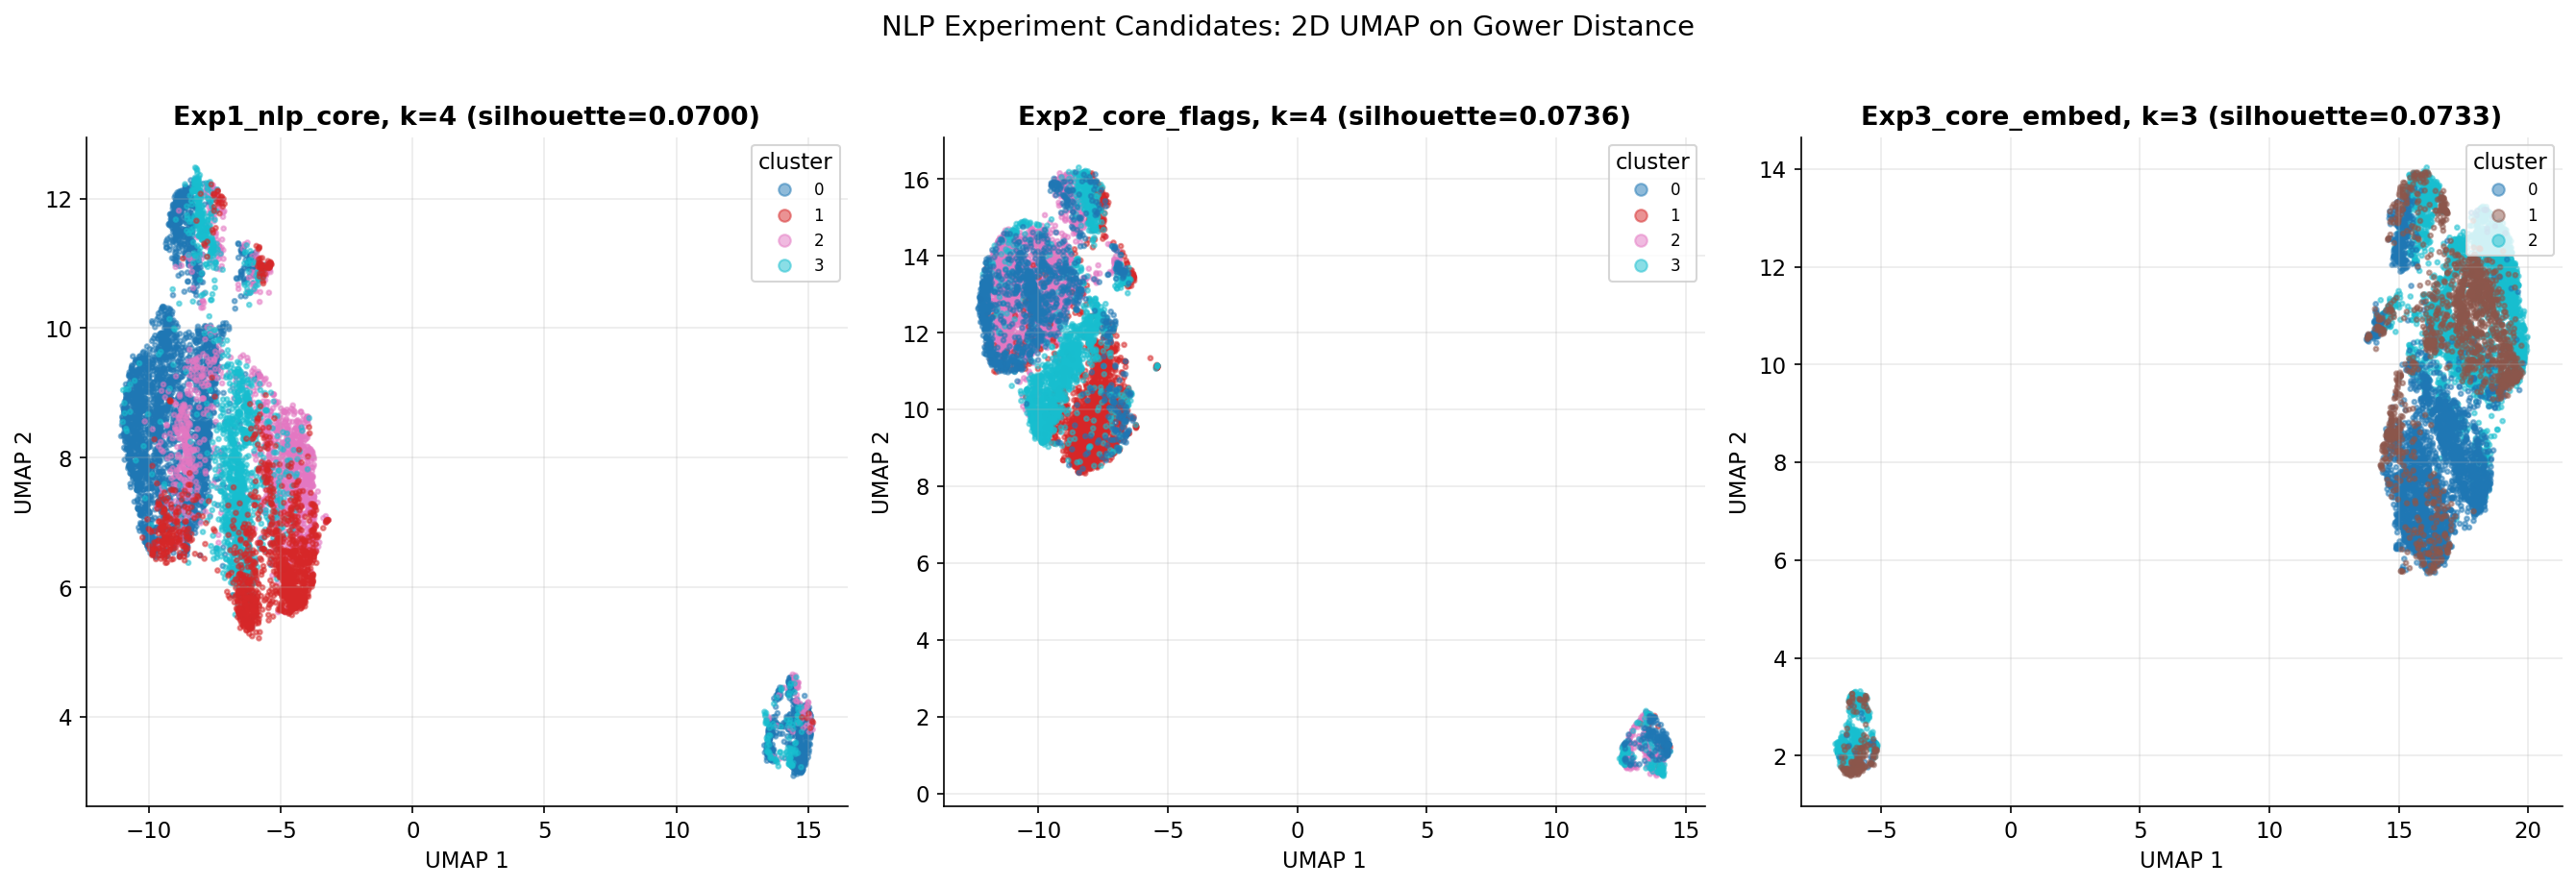

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (exp_name, k) in zip(axes, CROSSTAB_CANDIDATES):
    X_exp, cat_idx = experiment_matrices[exp_name]
    labels = nlp_sweep_results[exp_name][k]['labels']

    sample_idx = stratified_sample_indices(labels)
    X_sample = X_exp.iloc[sample_idx]
    labels_sample = labels[sample_idx]

    cat_mask = np.zeros(X_sample.shape[1], dtype=bool)
    cat_mask[cat_idx] = True
    gower_dist = gower.gower_matrix(X_sample, cat_features=cat_mask)

    reducer = umap.UMAP(n_components=2, metric='precomputed', random_state=42)
    embedding = reducer.fit_transform(gower_dist)

    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=labels_sample, cmap='tab10', s=5, alpha=0.5)
    sil = nlp_sweep_results[exp_name][k]['silhouette']
    ax.set_title(f'{exp_name}, k={k} (silhouette={sil:.4f})')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(*scatter.legend_elements(), title='cluster', loc='upper right', fontsize=8)

plt.suptitle('NLP Experiment Candidates: 2D UMAP on Gower Distance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Adding text features to the tabular backbone doesn't produce a configuration that clusters dramatically more cleanly than the backbone alone, but the four experiments aren't equivalent either. Silhouette peaks stay in a narrow band across all four, with content flags giving a small edge over the NLP core alone (0.0736 vs. 0.0700) and embeddings adding nothing further. No configuration crosses even a modest quality threshold.

Visually, the picture is more differentiated than the silhouette numbers alone suggest. `Exp2_core_flags` produces the most clearly organized map of the three, with two distinguishable dense regions and a consistently separate small island. `Exp1_nlp_core` shows a similar overall shape but with the four cluster colors far more intermixed within it. `Exp3_core_embed` is the weakest on this dimension too: its two colors barely separate at all across the map, despite a comparable silhouette score.

ARI against the backbone shows every NLP configuration reorganizing part of the market rather than leaving it untouched, but not scrambling it either: one backbone segment survives close to intact in every configuration tested, while the rest gets moderately reshuffled into a related but distinct grouping.

Taken together, `Exp2_core_flags` at k=4 stands out as the strongest candidate: the best silhouette of the four, the clearest visual separation, and a partition that meaningfully relates to the backbone rather than departing from it entirely. It's carried forward as the primary candidate for closer tuning, alongside `Exp1_nlp_core` (k=4) as the simpler alternative if the two turn out to be statistically indistinguishable under a proper gamma sweep, and `Exp3_core_embed` (k=3) to confirm whether embeddings' comparable silhouette reflects real, if visually weaker, structure or not.

## 6. Final Configuration Re-Tuning

This section re-examines the three carried-forward candidates: a narrow grid at `n_init=5` around each candidate's identified peak, checked on cost first, then verified with Gower silhouette only for the most promising resulting combinations.

### 6.1 Setup the Narrow Grids Per Candidate

In [78]:
FINAL_CANDIDATES = {
    'Exp1_nlp_core': {'k_range': [3, 4, 5], 'X': experiment_matrices['Exp1_nlp_core'][0], 'cat_idx': experiment_matrices['Exp1_nlp_core'][1]},
    'Exp2_core_flags': {'k_range': [3, 4, 5], 'X': experiment_matrices['Exp2_core_flags'][0], 'cat_idx': experiment_matrices['Exp2_core_flags'][1]},
    'Exp3_core_embed': {'k_range': [2, 3, 4], 'X': experiment_matrices['Exp3_core_embed'][0], 'cat_idx': experiment_matrices['Exp3_core_embed'][1]},
}

NARROW_GAMMA_RANGE = [1.5, 2.5, 3.5, 4.0, 4.5]
N_INIT_FINAL = 5

total_fits = sum(len(v['k_range']) for v in FINAL_CANDIDATES.values()) * len(NARROW_GAMMA_RANGE)
print(f"Candidates: {list(FINAL_CANDIDATES.keys())}")
print(f"Gamma grid: {NARROW_GAMMA_RANGE}")
print(f"n_init: {N_INIT_FINAL}")
print(f"\ntotal cost-only fits: {total_fits}")

Candidates: ['Exp1_nlp_core', 'Exp2_core_flags', 'Exp3_core_embed']
Gamma grid: [1.5, 2.5, 3.5, 4.0, 4.5]
n_init: 5

total cost-only fits: 45


### 6.2 Cost-Only Grid at n_init=5

In [79]:
import pickle

final_grid_cost = {}

for exp_name, config in FINAL_CANDIDATES.items():
    final_grid_cost[exp_name] = {}
    X_exp, cat_idx = config['X'], config['cat_idx']
    print(f"\n=== {exp_name} ===")
    for gamma in NARROW_GAMMA_RANGE:
        final_grid_cost[exp_name][gamma] = {}
        for k in config['k_range']:
            start = time.time()
            kproto = KPrototypes(n_clusters=k, init='Huang', n_init=N_INIT_FINAL, gamma=gamma, random_state=42, n_jobs=-1)
            labels = kproto.fit_predict(X_exp.to_numpy(), categorical=cat_idx)
            elapsed = time.time() - start

            final_grid_cost[exp_name][gamma][k] = {'cost': kproto.cost_, 'labels': labels}
            print(f"  gamma={gamma}, k={k}: cost={kproto.cost_:.1f}, {elapsed:.1f}s")

    # checkpoint after each candidate
    with open(BASE_PATH / 'data' / 'grid_checkpoints' / 'final_grid_cost_checkpoint.pkl', 'wb') as f:
        pickle.dump(final_grid_cost, f)
    print(f"  [checkpoint saved {exp_name}]")


=== Exp1_nlp_core ===
  gamma=1.5, k=3: cost=2790684.1, 73.0s
  gamma=1.5, k=4: cost=2741623.3, 72.3s
  gamma=1.5, k=5: cost=2684202.9, 74.3s
  gamma=2.5, k=3: cost=3269241.7, 68.1s
  gamma=2.5, k=4: cost=3213365.2, 50.3s
  gamma=2.5, k=5: cost=3133591.5, 64.9s
  gamma=3.5, k=3: cost=3744679.8, 46.9s
  gamma=3.5, k=4: cost=3675480.4, 47.3s
  gamma=3.5, k=5: cost=3582995.5, 54.3s
  gamma=4.0, k=3: cost=3972745.9, 43.5s
  gamma=4.0, k=4: cost=3905543.3, 45.4s
  gamma=4.0, k=5: cost=3804544.3, 53.0s
  gamma=4.5, k=3: cost=4215157.3, 38.1s
  gamma=4.5, k=4: cost=4134334.2, 40.4s
  gamma=4.5, k=5: cost=4021609.3, 51.0s
  [checkpoint saved Exp1_nlp_core]

=== Exp2_core_flags ===
  gamma=1.5, k=3: cost=2806077.0, 60.4s
  gamma=1.5, k=4: cost=2756591.3, 77.9s
  gamma=1.5, k=5: cost=2695865.3, 80.3s
  gamma=2.5, k=3: cost=3292355.1, 66.3s
  gamma=2.5, k=4: cost=3237010.4, 80.6s
  gamma=2.5, k=5: cost=3144406.2, 88.6s
  gamma=3.5, k=3: cost=3775991.4, 44.7s
  gamma=3.5, k=4: cost=3708189.1, 57.

### 6.3 Gower Silhouette for Each Candidate, Selected k Values Across Gamma

In [80]:
TARGET_K = {
    'Exp1_nlp_core': [3, 4, 5],
    'Exp2_core_flags': [3, 4, 5],
    'Exp3_core_embed': [2, 3, 4],
}

for exp_name, k_list in TARGET_K.items():
    X_exp, cat_idx = FINAL_CANDIDATES[exp_name]['X'], FINAL_CANDIDATES[exp_name]['cat_idx']
    for k in k_list:
        print(f"\n=== {exp_name}, k={k} ===")
        for gamma in NARROW_GAMMA_RANGE:
            labels = final_grid_cost[exp_name][gamma][k]['labels']
            sample_idx = stratified_sample_indices(labels)

            sil_score, n_sampled = compute_gower_silhouette(X_exp, cat_idx, labels, sample_idx)
            final_grid_cost[exp_name][gamma][k]['silhouette'] = sil_score
            print(f"  gamma={gamma}: silhouette={sil_score:.4f} (sample n={n_sampled})")

    with open(BASE_PATH / 'data' / 'grid_checkpoints' / 'final_grid_cost_checkpoint.pkl', 'wb') as f:
        pickle.dump(final_grid_cost, f)
    print(f"  [checkpoint saved after {exp_name}]")


=== Exp1_nlp_core, k=3 ===
  gamma=1.5: silhouette=0.0770 (sample n=8001)
  gamma=2.5: silhouette=0.0781 (sample n=8000)
  gamma=3.5: silhouette=0.0776 (sample n=8000)
  gamma=4.0: silhouette=0.0700 (sample n=8000)
  gamma=4.5: silhouette=0.0709 (sample n=8000)

=== Exp1_nlp_core, k=4 ===
  gamma=1.5: silhouette=0.0494 (sample n=8000)
  gamma=2.5: silhouette=0.0576 (sample n=8000)
  gamma=3.5: silhouette=0.0566 (sample n=8001)
  gamma=4.0: silhouette=0.0504 (sample n=7999)
  gamma=4.5: silhouette=0.0504 (sample n=8000)

=== Exp1_nlp_core, k=5 ===
  gamma=1.5: silhouette=0.0674 (sample n=8001)
  gamma=2.5: silhouette=0.0630 (sample n=8000)
  gamma=3.5: silhouette=0.0550 (sample n=8000)
  gamma=4.0: silhouette=0.0492 (sample n=7999)
  gamma=4.5: silhouette=0.0501 (sample n=8001)
  [checkpoint saved after Exp1_nlp_core]

=== Exp2_core_flags, k=3 ===
  gamma=1.5: silhouette=0.0759 (sample n=8000)
  gamma=2.5: silhouette=0.0805 (sample n=8000)
  gamma=3.5: silhouette=0.0528 (sample n=8000)

`n_init=5` tuning surfaces a genuinely strong candidate: `Exp3_core_embed` at k=2 reaches the highest silhouette across the entire final grid (0.1032, gamma=3.5), and holds that level consistently across every gamma tested. This reverses the earlier read on embeddings, at higher k they added little, but at k=2 they produce the clearest split found anywhere in this notebook.

`Exp2_core_flags` at k=5 remains a strong second, and `Exp1_nlp_core` at k=3 a close third. Both k=4 variants of Exp1 and Exp2, which looked most promising during initial screening, perform considerably worse under proper tuning.

**Three candidates are carried forward for visual and structural comparison**: `Exp3_core_embed` (k=2, gamma=3.5), `Exp2_core_flags` (k=5, gamma=1.5), and `Exp1_nlp_core` (k=3, gamma=2.5).

### 6.4 Visualizing the Two Leading Configurations

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/u

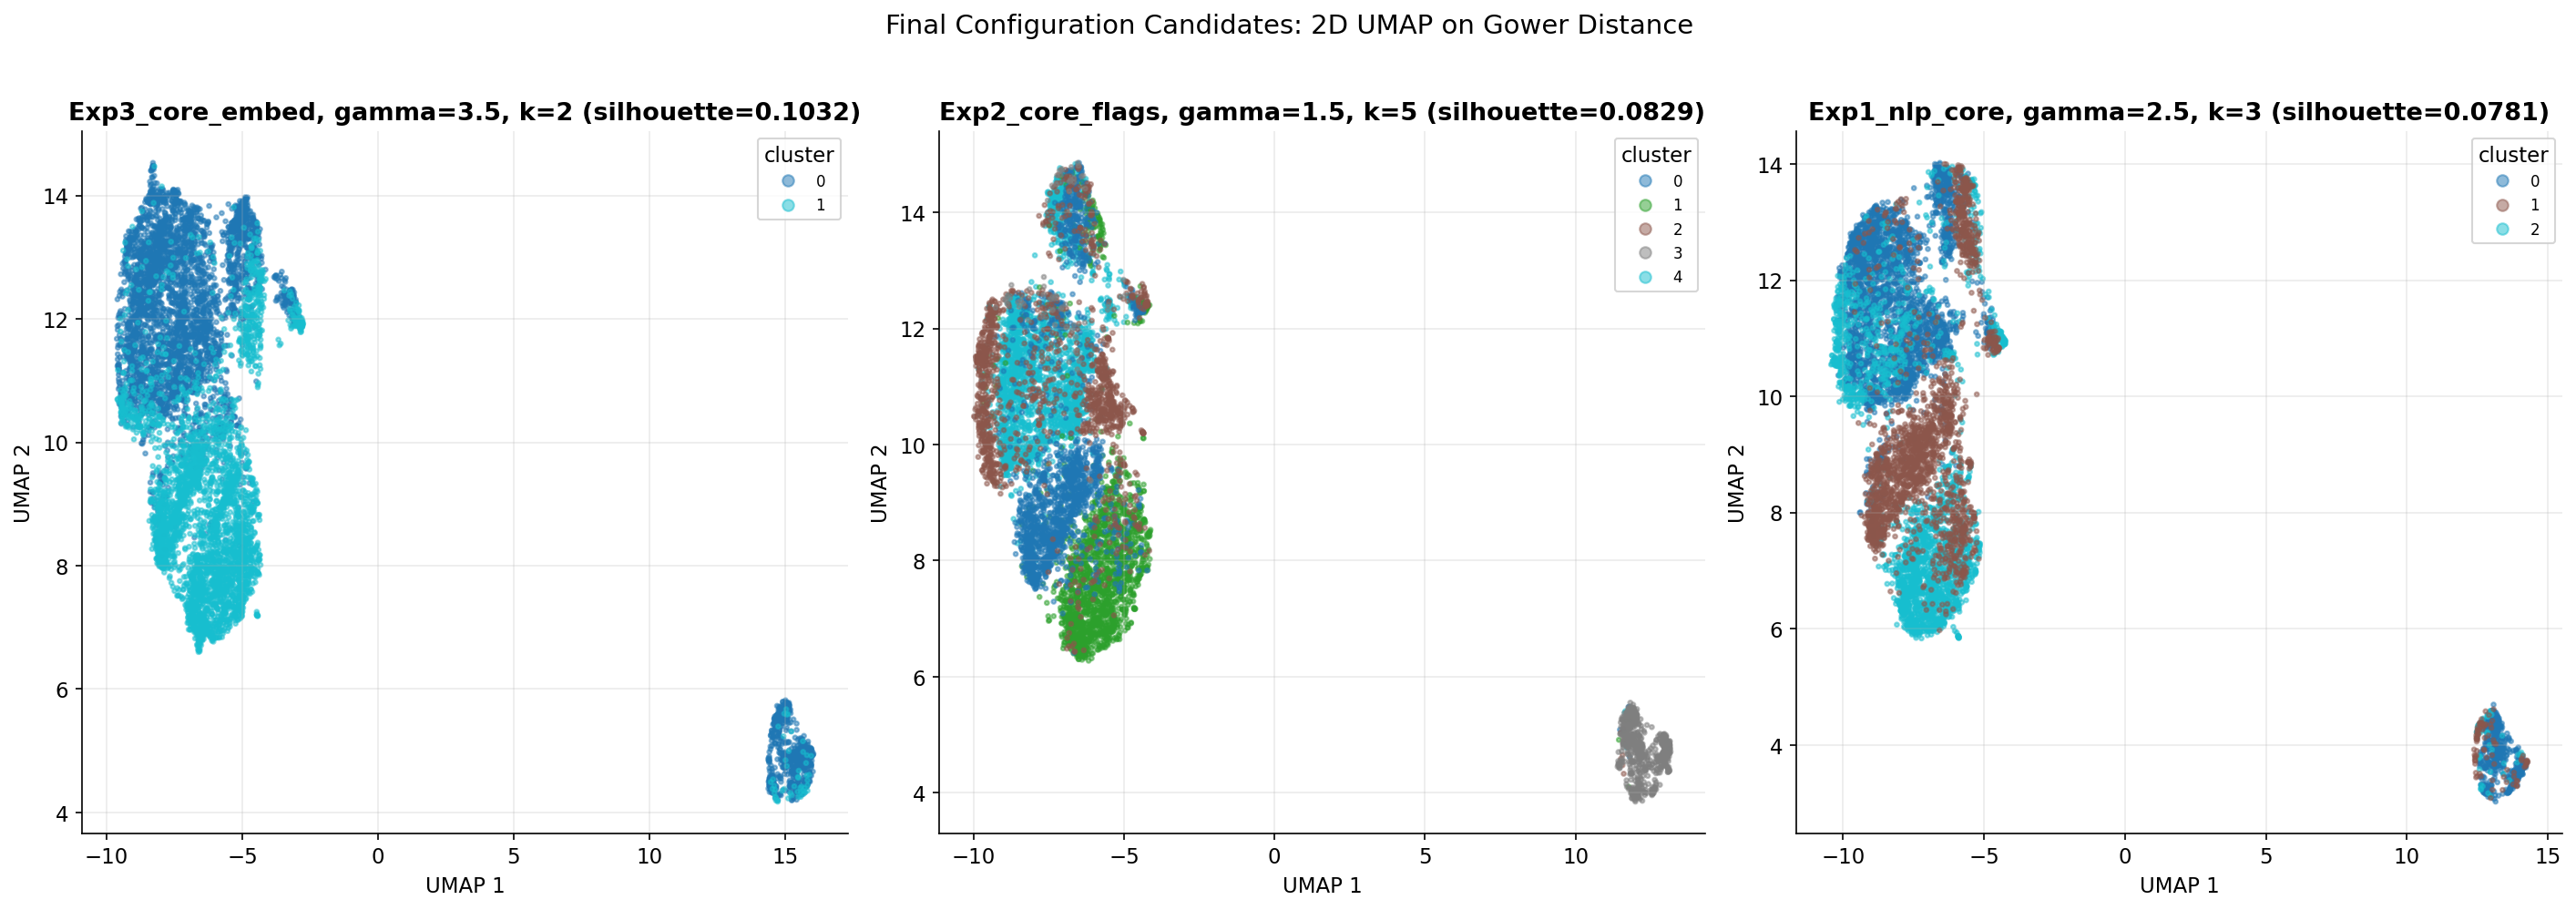

In [81]:
FINAL_CANDIDATES_VIZ = [
    ('Exp3_core_embed', 3.5, 2),
    ('Exp2_core_flags', 1.5, 5),
    ('Exp1_nlp_core', 2.5, 3),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))

for ax, (exp_name, gamma, k) in zip(axes, FINAL_CANDIDATES_VIZ):
    X_exp = FINAL_CANDIDATES[exp_name]['X']
    cat_idx = FINAL_CANDIDATES[exp_name]['cat_idx']
    labels = final_grid_cost[exp_name][gamma][k]['labels']

    sample_idx = stratified_sample_indices(labels)
    X_sample = X_exp.iloc[sample_idx]
    labels_sample = labels[sample_idx]

    cat_mask = np.zeros(X_sample.shape[1], dtype=bool)
    cat_mask[cat_idx] = True
    gower_dist = gower.gower_matrix(X_sample, cat_features=cat_mask)

    reducer = umap.UMAP(n_components=2, metric='precomputed', random_state=42)
    embedding = reducer.fit_transform(gower_dist)

    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=labels_sample, cmap='tab10', s=5, alpha=0.5)
    sil = final_grid_cost[exp_name][gamma][k]['silhouette']
    ax.set_title(f'{exp_name}, gamma={gamma}, k={k} (silhouette={sil:.4f})')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(*scatter.legend_elements(), title='cluster', loc='upper right', fontsize=8)

plt.suptitle('Final Configuration Candidates: 2D UMAP on Gower Distance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

All three maps share the same small, clearly separated island, but only two of them isolate it as its own group. `Exp3_core_embed` at k=2 splits the large main area in half but leaves the island's points mixed between both colors rather than giving it its own cluster, a less informative split despite scoring highest on silhouette. `Exp1_nlp_core` similarly struggles with the main area, showing three colors heavily overlapping across the whole shape with no clear internal boundary. `Exp2_core_flags` gives the clearest picture overall: the island stands on its own, and the main area splits into pieces that are noticeably easier to tell apart, including one cluster that separates out distinctly toward the bottom.

### 6.5 ARI Comparison

In [82]:
baseline_labels_final = baseline_grid_results[4.0001][4]['labels']

exp1_labels = final_grid_cost['Exp1_nlp_core'][2.5][3]['labels']
exp2_labels = final_grid_cost['Exp2_core_flags'][1.5][5]['labels']
exp3_labels = final_grid_cost['Exp3_core_embed'][3.5][2]['labels']

ari_exp1_baseline = adjusted_rand_score(baseline_labels_final, exp1_labels)
ari_exp2_baseline = adjusted_rand_score(baseline_labels_final, exp2_labels)
ari_exp3_baseline = adjusted_rand_score(baseline_labels_final, exp3_labels)
ari_exp1_exp2 = adjusted_rand_score(exp1_labels, exp2_labels)
ari_exp1_exp3 = adjusted_rand_score(exp1_labels, exp3_labels)
ari_exp2_exp3 = adjusted_rand_score(exp2_labels, exp3_labels)

print(f"Exp1_nlp_core (k=3) vs Baseline: ARI = {ari_exp1_baseline:.4f}")
print(f"Exp2_core_flags (k=5) vs Baseline: ARI = {ari_exp2_baseline:.4f}")
print(f"Exp3_core_embed (k=2) vs Baseline: ARI = {ari_exp3_baseline:.4f}")
print(f"\nExp1 vs Exp2: ARI = {ari_exp1_exp2:.4f}")
print(f"Exp1 vs Exp3: ARI = {ari_exp1_exp3:.4f}")
print(f"Exp2 vs Exp3: ARI = {ari_exp2_exp3:.4f}")

print("\n=== Baseline vs. Exp2_core_flags (k=5) ===")
display(pd.crosstab(
    pd.Series(baseline_labels_final, name='Baseline cluster (k=4)'),
    pd.Series(exp2_labels, name='Exp2_core_flags cluster (k=5)')
))

print("\n=== Exp1_nlp_core (k=3) vs. Exp2_core_flags (k=5) ===")
display(pd.crosstab(
    pd.Series(exp1_labels, name='Exp1_nlp_core cluster (k=3)'),
    pd.Series(exp2_labels, name='Exp2_core_flags cluster (k=5)')
))

print("\n=== Exp3_core_embed (k=2) vs. Exp2_core_flags (k=5) ===")
display(pd.crosstab(
    pd.Series(exp3_labels, name='Exp3_core_embed cluster (k=2)'),
    pd.Series(exp2_labels, name='Exp2_core_flags cluster (k=5)')
))

Exp1_nlp_core (k=3) vs Baseline: ARI = 0.1755
Exp2_core_flags (k=5) vs Baseline: ARI = 0.1306
Exp3_core_embed (k=2) vs Baseline: ARI = 0.2067

Exp1 vs Exp2: ARI = 0.4876
Exp1 vs Exp3: ARI = 0.4624
Exp2 vs Exp3: ARI = 0.3091

=== Baseline vs. Exp2_core_flags (k=5) ===


Exp2_core_flags cluster (k=5),0,1,2,3,4
Baseline cluster (k=4),,,,,
0,2574,4582,1669,102,813
1,1232,563,468,846,1158
2,1188,1602,1437,308,1737
3,1598,240,1496,1698,5407



=== Exp1_nlp_core (k=3) vs. Exp2_core_flags (k=5) ===


Exp2_core_flags cluster (k=5),0,1,2,3,4
Exp1_nlp_core cluster (k=3),,,,,
0,344,3,2032,2484,8951
1,6078,1210,169,337,128
2,170,5774,2869,133,36



=== Exp3_core_embed (k=2) vs. Exp2_core_flags (k=5) ===


Exp2_core_flags cluster (k=5),0,1,2,3,4
Exp3_core_embed cluster (k=2),,,,,
0,1645,45,3769,2846,8984
1,4947,6942,1301,108,131


All three configurations relate only loosely to the tabular baseline (ARI 0.13-0.21), confirming that bringing in text reshapes the grouping rather than just sharpening it. The more useful comparisons are between the three text based configurations themselves, and here Exp2 shows a clear relationship to both others. Against Exp1, one of Exp2's five clusters (cluster 4) absorbs most of Exp1's largest group, and the split is otherwise fairly orderly, not a random reshuffle. Against Exp3, the same pattern holds even more plainly: Exp3's two halves map closely onto two clear groupings within Exp2's five, meaning Exp2 looks like a finer, more detailed version of the same split Exp3 finds at a coarser level, one that also succeeds where Exp3 didn't, giving the small isolated group its own cluster instead of splitting it across both halves. This fits with what the cluster maps already showed: Exp2 isn't producing an unrelated structure, it's the most detailed and best organized version of a grouping the other two configurations also detect in rougher form.

### 6.6 Final Configuration Re-Tuning Summary

Putting the silhouette scores, the cluster maps, and the ARI comparison together, `Exp2_core_flags` at k=5 comes out ahead of the other two candidates tested. It doesn't have the single highest silhouette score, but it separates far more clearly on the map, giving the isolated small group its own cluster where the other two configurations either mix it in or fail to set it apart cleanly. It also relates to both other configurations as a finer, more detailed version of the same underlying split rather than an unrelated structure, which suggests the extra groups it finds are refining a real pattern. This configuration, tone and topic features plus the content flags, at five clusters, is carried forward as the final result.

**Final Configuration**: `Exp2_core_flags`, gamma=1.5, k=5.

The clusters found here are still not sharply separated in an absolute sense, and that has held true across every configuration tested in this notebook. Before moving on to checking how stable this result is and what each cluster actually looks like, it is worth testing the same data with a different kind of clustering method, one that does not force every listing into a group and can leave weakly connected points unassigned instead. This offers a second, independent check on whether the market is genuinely made of a few soft groups or whether it resists clean separation no matter which method is used.

## 7. Independent Check with HDBSCAN

Every configuration tested so far showed the same shape: one small group clearly apart, and a large remaining area with no sharp internal edges. K-Prototypes has to assign every listing to one of a fixed number of groups, even where the data doesn't support a clean split. This section checks the same population with a method that doesn't have that requirement and can leave weakly-connected points unassigned rather than forcing them into a group, as an independent test of whether the market genuinely resists sharp separation or whether that's an artifact of the method.

In [84]:
import hdbscan

final_labels = final_grid_cost['Exp2_core_flags'][1.5][5]['labels']
final_sample_idx = stratified_sample_indices(final_labels)
X_final_sample = experiment_matrices['Exp2_core_flags'][0].iloc[final_sample_idx]

cat_mask_final = np.zeros(X_final_sample.shape[1], dtype=bool)
cat_mask_final[experiment_matrices['Exp2_core_flags'][1]] = True
gower_dist_final = gower.gower_matrix(X_final_sample, cat_features=cat_mask_final)

print(f"Gower distance computed in {time.time()-start:.1f}s")

for mcs in [25, 50, 100]:
    print(f"\nrunning HDBSCAN with min_cluster_size={mcs}...")
    start = time.time()
    clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs, metric='precomputed')
    hdbscan_labels = clusterer.fit_predict(gower_dist_final.astype('float64'))
    elapsed = time.time() - start

    n_clusters_found = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
    noise_pct = (hdbscan_labels == -1).mean() * 100
    print(f"min_cluster_size={mcs}: {n_clusters_found} clusters found, {noise_pct:.1f}% noise")

Gower distance computed in 27814.7s

running HDBSCAN with min_cluster_size=25...
min_cluster_size=25: 2 clusters found, 95.4% noise

running HDBSCAN with min_cluster_size=50...
min_cluster_size=50: 2 clusters found, 95.9% noise

running HDBSCAN with min_cluster_size=100...
min_cluster_size=100: 0 clusters found, 100.0% noise


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


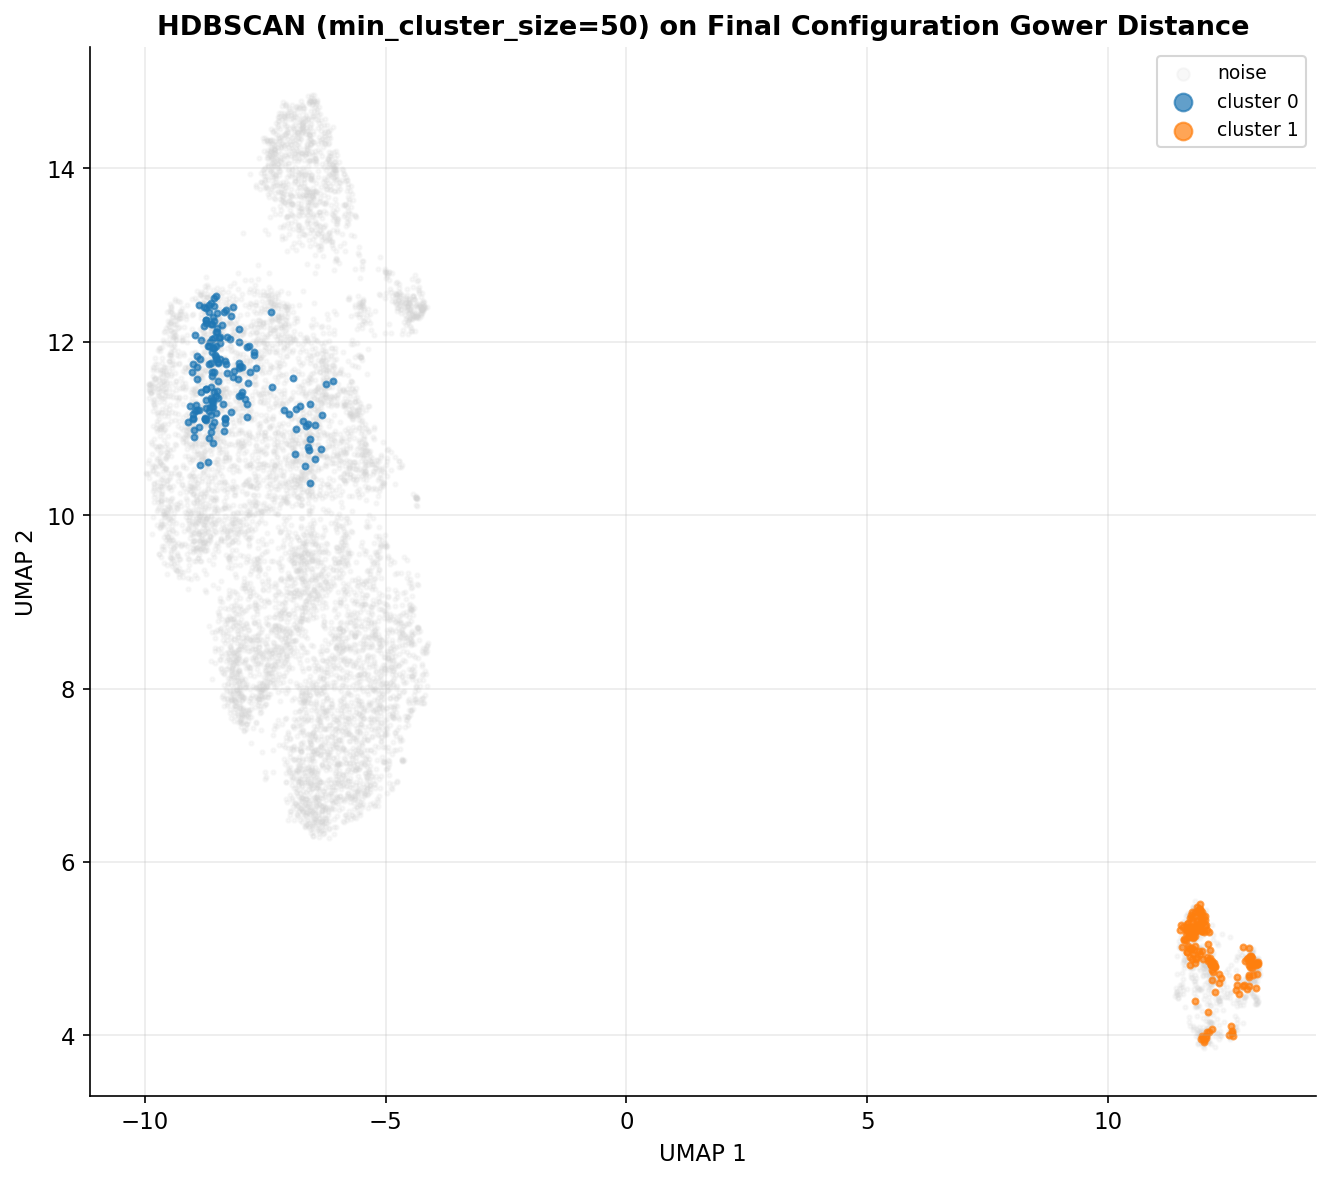

In [85]:
reducer_hdbscan = umap.UMAP(n_components=2, metric='precomputed', random_state=42)
embedding_hdbscan = reducer_hdbscan.fit_transform(gower_dist_final.astype('float64'))

hdbscan_labels_50 = hdbscan.HDBSCAN(min_cluster_size=50, metric='precomputed').fit_predict(gower_dist_final.astype('float64'))

fig, ax = plt.subplots(figsize=(9, 8))
noise_mask = hdbscan_labels_50 == -1
ax.scatter(embedding_hdbscan[noise_mask, 0], embedding_hdbscan[noise_mask, 1], s=4, alpha=0.15, color='lightgrey', label='noise')

for cluster_id in sorted(set(hdbscan_labels_50) - {-1}):
    mask = hdbscan_labels_50 == cluster_id
    ax.scatter(embedding_hdbscan[mask, 0], embedding_hdbscan[mask, 1], s=8, alpha=0.7, label=f'cluster {cluster_id}')

ax.set_title(f'HDBSCAN (min_cluster_size=50) on Final Configuration Gower Distance')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

HDBSCAN finds almost no dense structure across the sample: at every threshold tested, 95-100% of listings end up unassigned. The two small groups it does find at min_cluster_size=25 and 50 aren't random. Cluster 1 sits exactly where the isolated island has appeared in every visualization throughout this notebook, an independent confirmation that this group is real and detectable by a completely different method. Cluster 0 is a more specific finding, a smaller, tightly packed pocket sitting inside what otherwise reads as the large, undifferentiated main body, not visually separated from it the way the island is, but still dense enough for HDBSCAN to pick out on its own.

This confirms the pattern already seen throughout this notebook, but more sharply: the market contains a small number of genuinely tight, reproducible groups, while the large majority of listings sit in one continuous, weakly-differentiated body that no method tested here, including one built specifically to leave weak connections unassigned, manages to split cleanly. K-Prototypes' five clusters aren't manufacturing structure where none exists. They're finding the same real, tight groups HDBSCAN finds, plus a reasonable division of the market's genuinely unstructured remainder.

## 8. Curiosity Check Including Price Features

`price_tier` and `price` was deliberately kept external throughout this notebook, preserved as an independent lens for interpreting the clusters rather than a variable that shapes them. This section asks, out of curiosity rather than as a candidate for the final model, what happens if it's added directly into the final feature set: does the market's structure change, or does price tier turn out to be already implicit in the tabular and text features already present?

### 8.1 Setup the price_tier feature set

In [86]:
price_tier_categorical = backbone_categorical_cols_B + [c for c in (NLP_CORE_COLS | CONTENT_FLAG_COLS) if c in categorical_cols] + ['price_tier']
price_tier_continuous = backbone_continuous_cols + [c for c in (NLP_CORE_COLS | CONTENT_FLAG_COLS) if c in continuous_cols]
price_tier_binary = backbone_binary_cols + [c for c in (NLP_CORE_COLS | CONTENT_FLAG_COLS) if c in binary_cols]

listings_reviewed['price_tier'] = price_tier.loc[listings_reviewed.index]
print(f"price_tier value counts:\n{listings_reviewed['price_tier'].value_counts()}")

X_price_tier, cat_idx_price_tier = build_kproto_matrix(
    price_tier_continuous, price_tier_categorical, price_tier_binary, listings_reviewed
)
print(f"\nX_price_tier shape: {X_price_tier.shape}")

price_tier value counts:
price_tier
Standard    14132
Budget       7117
Premium      4171
Unknown      2682
Luxury       2616
Name: count, dtype: int64

X_price_tier shape: (30718, 130)


### 8.2 Fitting the Final Configuration With Price Tier Included

In [87]:
PRICE_CHECK_K_RANGE = [3, 4, 5]
PRICE_CHECK_GAMMA_RANGE = [1.0, 1.5, 2.0]

price_check_grid = {}
for gamma in PRICE_CHECK_GAMMA_RANGE:
    price_check_grid[gamma] = {}
    print(f"\n=== gamma={gamma} ===")
    for k in PRICE_CHECK_K_RANGE:
        start = time.time()
        kproto = KPrototypes(n_clusters=k, init='Huang', n_init=5, gamma=gamma, random_state=42, n_jobs=-1)
        labels = kproto.fit_predict(X_price_tier.to_numpy(), categorical=cat_idx_price_tier)
        elapsed = time.time() - start

        price_check_grid[gamma][k] = {'cost': kproto.cost_, 'labels': labels}
        print(f"  k={k}: cost={kproto.cost_:.1f}, {elapsed:.1f}s")

with open(BASE_PATH / 'data' / 'grid_checkpoints' / 'price_check_grid.pkl', 'wb') as f:
    pickle.dump(price_check_grid, f)


=== gamma=1.0 ===
  k=3: cost=2578170.9, 104.8s
  k=4: cost=2531995.8, 64.2s
  k=5: cost=2485248.3, 85.1s

=== gamma=1.5 ===
  k=3: cost=2830574.7, 68.7s
  k=4: cost=2781223.2, 90.5s
  k=5: cost=2720871.1, 96.9s

=== gamma=2.0 ===
  k=3: cost=3086979.7, 67.0s
  k=4: cost=3029389.2, 100.8s
  k=5: cost=2955712.5, 108.8s


### 8.3 Stratified Sampling & Gower Silhouette

In [88]:
for gamma in PRICE_CHECK_GAMMA_RANGE:
    print(f"\n=== gamma={gamma} ===")
    for k in PRICE_CHECK_K_RANGE:
        labels = price_check_grid[gamma][k]['labels']
        sample_idx = stratified_sample_indices(labels)

        sil_score, n_sampled = compute_gower_silhouette(X_price_tier, cat_idx_price_tier, labels, sample_idx)
        price_check_grid[gamma][k]['silhouette'] = sil_score
        print(f"  k={k}: silhouette={sil_score:.4f} (sample n={n_sampled})")

with open(BASE_PATH / 'data' / 'grid_checkpoints' / 'price_check_grid.pkl', 'wb') as f:
    pickle.dump(price_check_grid, f)


=== gamma=1.0 ===
  k=3: silhouette=0.0750 (sample n=8000)
  k=4: silhouette=0.0473 (sample n=8001)
  k=5: silhouette=0.0753 (sample n=8000)

=== gamma=1.5 ===
  k=3: silhouette=0.0781 (sample n=8000)
  k=4: silhouette=0.0446 (sample n=8000)
  k=5: silhouette=0.0829 (sample n=8000)

=== gamma=2.0 ===
  k=3: silhouette=0.0689 (sample n=7999)
  k=4: silhouette=0.0457 (sample n=8001)
  k=5: silhouette=0.0846 (sample n=8000)


best: gamma=2.0, k=5, silhouette=0.0846


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


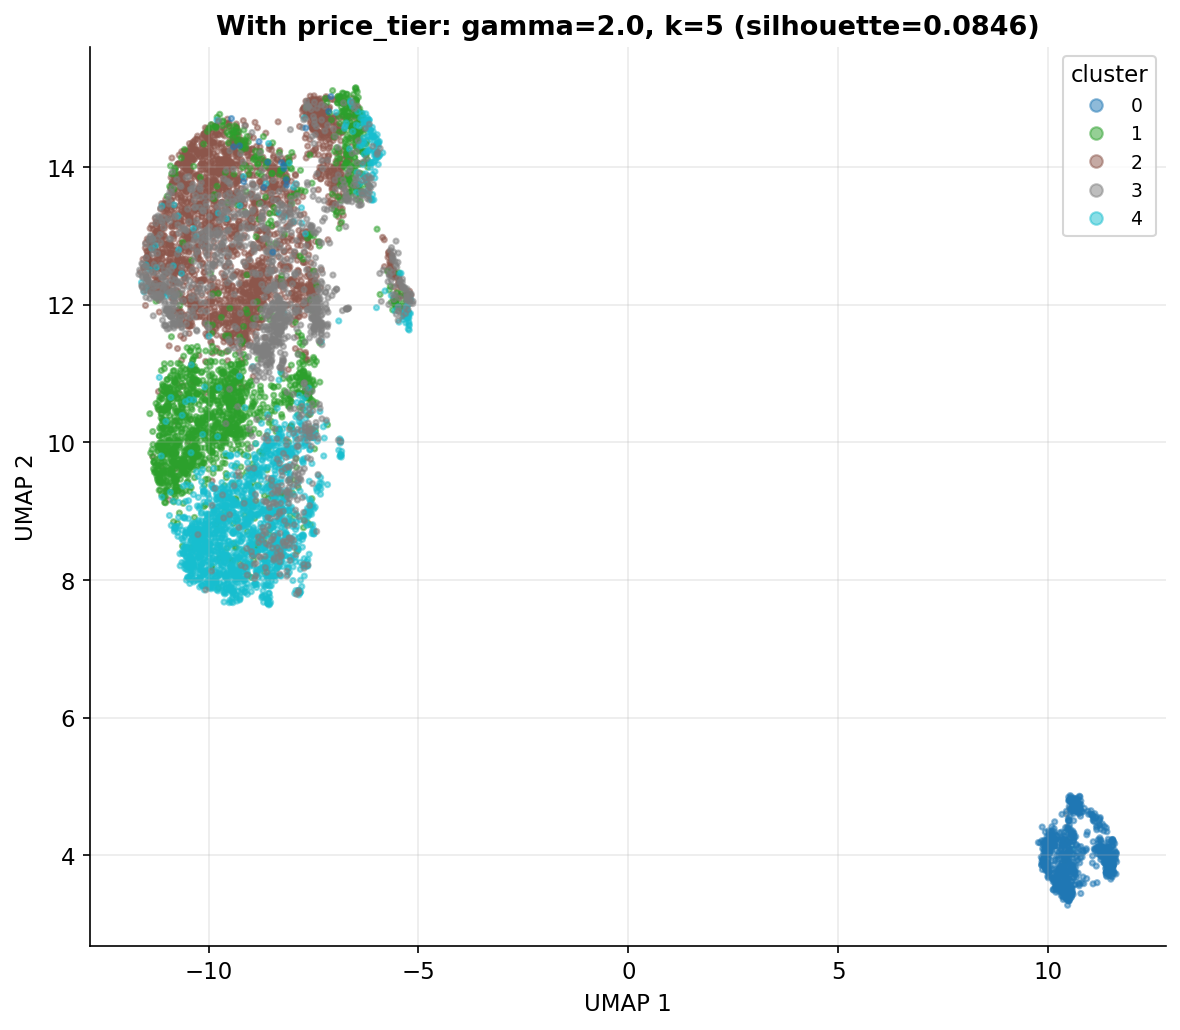


ARI (final config without price_tier vs. with price_tier): 0.8223


In [89]:
best_gamma_price = max(price_check_grid, key=lambda g: max(price_check_grid[g][k]['silhouette'] for k in PRICE_CHECK_K_RANGE))
best_k_price = max(PRICE_CHECK_K_RANGE, key=lambda k: price_check_grid[best_gamma_price][k]['silhouette'])
best_sil_price = price_check_grid[best_gamma_price][best_k_price]['silhouette']
print(f"best: gamma={best_gamma_price}, k={best_k_price}, silhouette={best_sil_price:.4f}")

labels_price_best = price_check_grid[best_gamma_price][best_k_price]['labels']
sample_idx_price = stratified_sample_indices(labels_price_best)
X_sample_price = X_price_tier.iloc[sample_idx_price]
labels_sample_price = labels_price_best[sample_idx_price]

cat_mask_price = np.zeros(X_sample_price.shape[1], dtype=bool)
cat_mask_price[cat_idx_price_tier] = True
gower_dist_price = gower.gower_matrix(X_sample_price, cat_features=cat_mask_price)

reducer_price = umap.UMAP(n_components=2, metric='precomputed', random_state=42)
embedding_price = reducer_price.fit_transform(gower_dist_price)

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(embedding_price[:, 0], embedding_price[:, 1], c=labels_sample_price, cmap='tab10', s=6, alpha=0.5)
ax.set_title(f'With price_tier: gamma={best_gamma_price}, k={best_k_price} (silhouette={best_sil_price:.4f})')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(*scatter.legend_elements(), title='cluster', loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

final_labels_no_price = final_grid_cost['Exp2_core_flags'][1.5][5]['labels']
ari_price_final = adjusted_rand_score(final_labels_no_price, labels_price_best)
print(f"\nARI (final config without price_tier vs. with price_tier): {ari_price_final:.4f}")

In [92]:
crosstab_price = pd.crosstab(
    pd.Series(final_labels_no_price, name='Final config (no price_tier)'),
    pd.Series(labels_price_best, name='With price_tier')
)
display(crosstab_price)

With price_tier,0,1,2,3,4
Final config (no price_tier),,,,,
0,19,6201,151,83,138
1,5,217,0,611,6154
2,26,13,548,4273,210
3,2840,14,91,9,0
4,14,91,8873,136,1


Adding `price_tier` directly into the feature set leaves the clustering essentially unchanged. Silhouette stays at 0.0829-0.0846 depending on gamma, matching the final configuration almost exactly, and the resulting partition agrees strongly with it (ARI=0.82). The crosstab confirms this at the cluster level: each of the five original clusters maps overwhelmingly onto one specific cluster in the price-tier version (for example, original cluster 1 sends 6,154 of its listings into a single column, and original cluster 4 sends 8,873 into another), with only minor movement elsewhere. The isolated small group stays intact and unmixed either way.

This supports what feature selection already suggested early in this project: price tier doesn't add information the clustering doesn't already have access to through the tabular and text features present. Whatever distinguishes these market segments, it's largely visible without price as an input, exactly the property that lets price serve as a genuinely independent lens for interpreting the clusters rather than one that shapes them.

### 8.4 Setup the continuous price feature set

In [93]:
price_available_mask = listings_reviewed['price'].notna()
listings_price_subset = listings_reviewed[price_available_mask].copy()
print(f"subset shape: {listings_price_subset.shape}")

price_cont_categorical = backbone_categorical_cols_B + [c for c in (NLP_CORE_COLS | CONTENT_FLAG_COLS) if c in categorical_cols]
price_cont_continuous = backbone_continuous_cols + [c for c in (NLP_CORE_COLS | CONTENT_FLAG_COLS) if c in continuous_cols] + ['price']
price_cont_binary = backbone_binary_cols + [c for c in (NLP_CORE_COLS | CONTENT_FLAG_COLS) if c in binary_cols]

X_price_cont, cat_idx_price_cont = build_kproto_matrix(
    price_cont_continuous, price_cont_categorical, price_cont_binary, listings_price_subset
)
print(f"X_price_cont shape: {X_price_cont.shape}")

subset shape: (28036, 151)
X_price_cont shape: (28036, 130)


### 8.5 K×Gamma Grid With Continuous Price Included

In [94]:
price_cont_grid = {}
for gamma in PRICE_CHECK_GAMMA_RANGE:
    price_cont_grid[gamma] = {}
    print(f"\n=== gamma={gamma} ===")
    for k in PRICE_CHECK_K_RANGE:
        start = time.time()
        kproto = KPrototypes(n_clusters=k, init='Huang', n_init=5, gamma=gamma, random_state=42, n_jobs=-1)
        labels = kproto.fit_predict(X_price_cont.to_numpy(), categorical=cat_idx_price_cont)
        elapsed = time.time() - start

        price_cont_grid[gamma][k] = {'cost': kproto.cost_, 'labels': labels}
        print(f"  k={k}: cost={kproto.cost_:.1f}, {elapsed:.1f}s")

with open(BASE_PATH / 'data' / 'grid_checkpoints' / 'price_cont_grid.pkl', 'wb') as f:
    pickle.dump(price_cont_grid, f)


=== gamma=1.0 ===
  k=3: cost=2361994.1, 62.0s
  k=4: cost=2320135.1, 100.9s
  k=5: cost=2287240.5, 129.6s

=== gamma=1.5 ===
  k=3: cost=2582860.6, 55.2s
  k=4: cost=2538236.3, 57.8s
  k=5: cost=2505028.7, 75.0s

=== gamma=2.0 ===
  k=3: cost=2804929.7, 62.7s
  k=4: cost=2757420.1, 64.9s
  k=5: cost=2689597.9, 88.6s


### 8.6 Stratified Sampling + Gower Silhouette

In [95]:
for gamma in PRICE_CHECK_GAMMA_RANGE:
    print(f"\n=== gamma={gamma} ===")
    for k in PRICE_CHECK_K_RANGE:
        labels = price_cont_grid[gamma][k]['labels']
        sample_idx = stratified_sample_indices(labels)

        sil_score, n_sampled = compute_gower_silhouette(X_price_cont, cat_idx_price_cont, labels, sample_idx)
        price_cont_grid[gamma][k]['silhouette'] = sil_score
        print(f"  k={k}: silhouette={sil_score:.4f} (sample n={n_sampled})")

with open(BASE_PATH / 'data' / 'grid_checkpoints' / 'price_cont_grid.pkl', 'wb') as f:
    pickle.dump(price_cont_grid, f)
print("\nsilhouette computation complete, checkpoint saved")


=== gamma=1.0 ===
  k=3: silhouette=0.0779 (sample n=8000)
  k=4: silhouette=0.0473 (sample n=8001)
  k=5: silhouette=0.0436 (sample n=7999)

=== gamma=1.5 ===
  k=3: silhouette=0.0783 (sample n=7999)
  k=4: silhouette=0.0473 (sample n=8000)
  k=5: silhouette=0.0411 (sample n=8000)

=== gamma=2.0 ===
  k=3: silhouette=0.0779 (sample n=8001)
  k=4: silhouette=0.0456 (sample n=8000)
  k=5: silhouette=0.0658 (sample n=7999)

silhouette computation complete, checkpoint saved


best: gamma=1.5, k=3, silhouette=0.0783


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


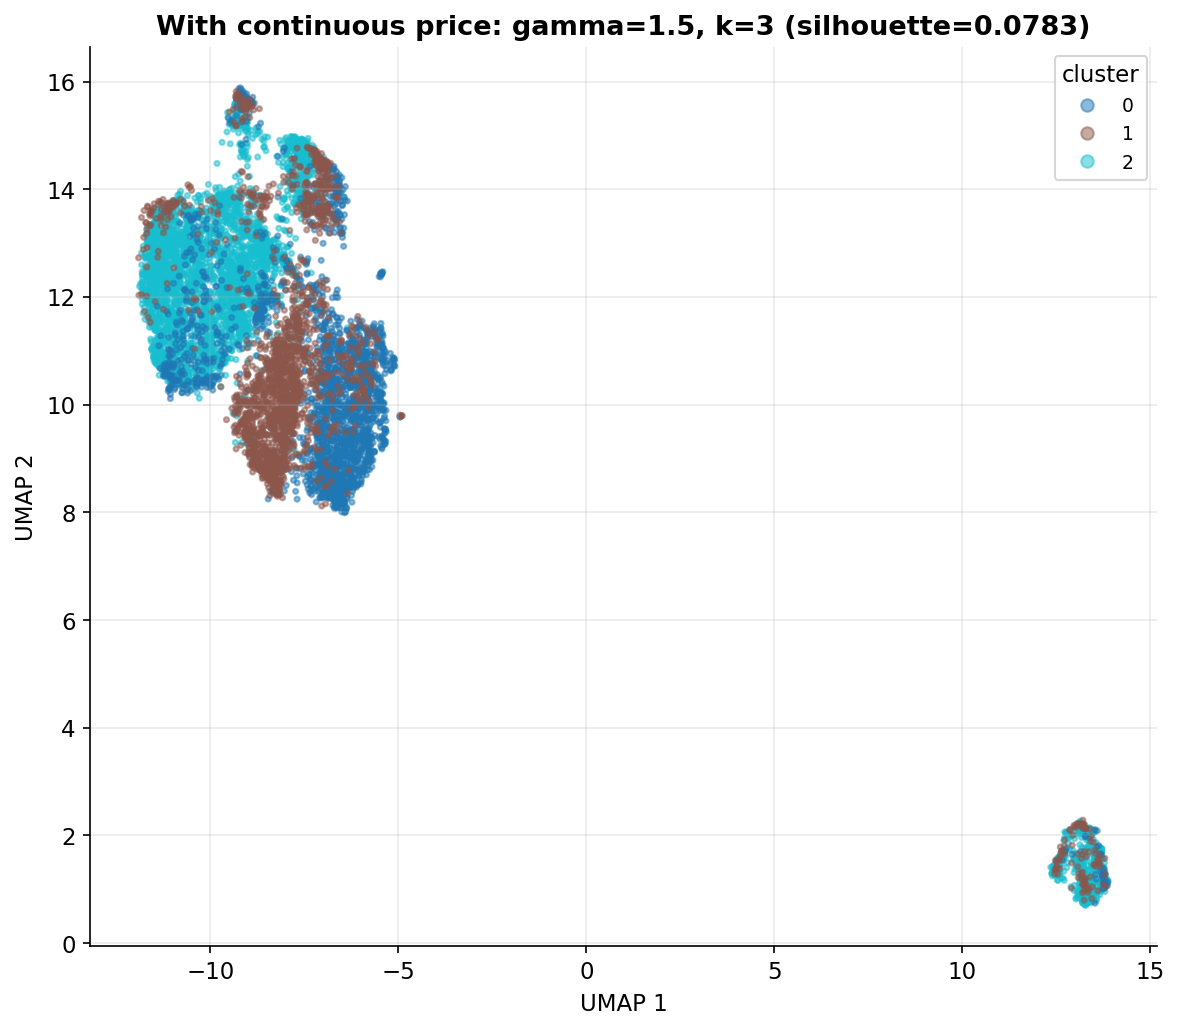


ARI (final config vs. with continuous price, on price-available subset): 0.5573


With continuous price,0,1,2
Final config (no price),,,
0,46,5889,33
1,6244,339,2
2,1723,61,2837
3,89,296,2141
4,1,117,8218


In [96]:
best_gamma_cont = max(price_cont_grid, key=lambda g: max(price_cont_grid[g][k]['silhouette'] for k in PRICE_CHECK_K_RANGE))
best_k_cont = max(PRICE_CHECK_K_RANGE, key=lambda k: price_cont_grid[best_gamma_cont][k]['silhouette'])
best_sil_cont = price_cont_grid[best_gamma_cont][best_k_cont]['silhouette']
print(f"best: gamma={best_gamma_cont}, k={best_k_cont}, silhouette={best_sil_cont:.4f}")

labels_cont_best = price_cont_grid[best_gamma_cont][best_k_cont]['labels']
sample_idx_cont = stratified_sample_indices(labels_cont_best)
X_sample_cont = X_price_cont.iloc[sample_idx_cont]
labels_sample_cont = labels_cont_best[sample_idx_cont]

cat_mask_cont = np.zeros(X_sample_cont.shape[1], dtype=bool)
cat_mask_cont[cat_idx_price_cont] = True
gower_dist_cont = gower.gower_matrix(X_sample_cont, cat_features=cat_mask_cont)

reducer_cont = umap.UMAP(n_components=2, metric='precomputed', random_state=42)
embedding_cont = reducer_cont.fit_transform(gower_dist_cont)

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(embedding_cont[:, 0], embedding_cont[:, 1], c=labels_sample_cont, cmap='tab10', s=6, alpha=0.5)
ax.set_title(f'With continuous price: gamma={best_gamma_cont}, k={best_k_cont} (silhouette={best_sil_cont:.4f})')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(*scatter.legend_elements(), title='cluster', loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# ARI requires comparing on the same rows — restrict final config labels to the price-available subset
final_labels_subset = final_grid_cost['Exp2_core_flags'][1.5][5]['labels'][price_available_mask.values]
ari_price_cont = adjusted_rand_score(final_labels_subset, labels_cont_best)
print(f"\nARI (final config vs. with continuous price, on price-available subset): {ari_price_cont:.4f}")

crosstab_price_cont = pd.crosstab(
    pd.Series(final_labels_subset, name='Final config (no price)'),
    pd.Series(labels_cont_best, name='With continuous price')
)
display(crosstab_price_cont)

Continuous price behaves differently from price_tier. The best silhouette drops from k=5 to k=3 once price is included as a raw number, and the resulting split, visible clearly on the map, mixes the two colors representing the market's original larger clusters together rather than keeping them apart. ARI against the final configuration (0.56) is meaningfully lower than what price_tier produced (0.82), meaning raw price reorganizes the market more than its binned version does.

This makes sense given how price_tier and price relate to each other. Price_tier is a coarse summary already aligned with the boundaries the tabular and text features roughly agree on, so adding it barely moves anything. Raw price carries finer, more continuous variation that cuts across those same boundaries, so folding it in directly pulls the clustering toward a more price-driven split rather than confirming the one already found. This is consistent with the decision made earlier in this project to keep price external: even a small amount of raw price signal is enough to reshape the grouping meaningfully, exactly the kind of influence an interpretive variable shouldn't have on the clusters it's meant to help explain.

### 8.7 HDBSCAN on Both Price-Enriched Configurations

In [97]:
for label, gower_dist_x in [('price_tier', gower_dist_price), ('continuous price', gower_dist_cont)]:
    print(f"\n=== {label} ===")
    for mcs in [25, 50, 100]:
        clusterer_x = hdbscan.HDBSCAN(min_cluster_size=mcs, metric='precomputed')
        hdbscan_labels_x = clusterer_x.fit_predict(gower_dist_x.astype('float64'))

        n_clusters_x = len(set(hdbscan_labels_x)) - (1 if -1 in hdbscan_labels_x else 0)
        noise_pct_x = (hdbscan_labels_x == -1).mean() * 100
        print(f"  min_cluster_size={mcs}: {n_clusters_x} clusters found, {noise_pct_x:.1f}% noise")


=== price_tier ===
  min_cluster_size=25: 2 clusters found, 95.4% noise
  min_cluster_size=50: 2 clusters found, 95.3% noise
  min_cluster_size=100: 0 clusters found, 100.0% noise

=== continuous price ===
  min_cluster_size=25: 2 clusters found, 92.7% noise
  min_cluster_size=50: 2 clusters found, 93.3% noise
  min_cluster_size=100: 2 clusters found, 95.6% noise


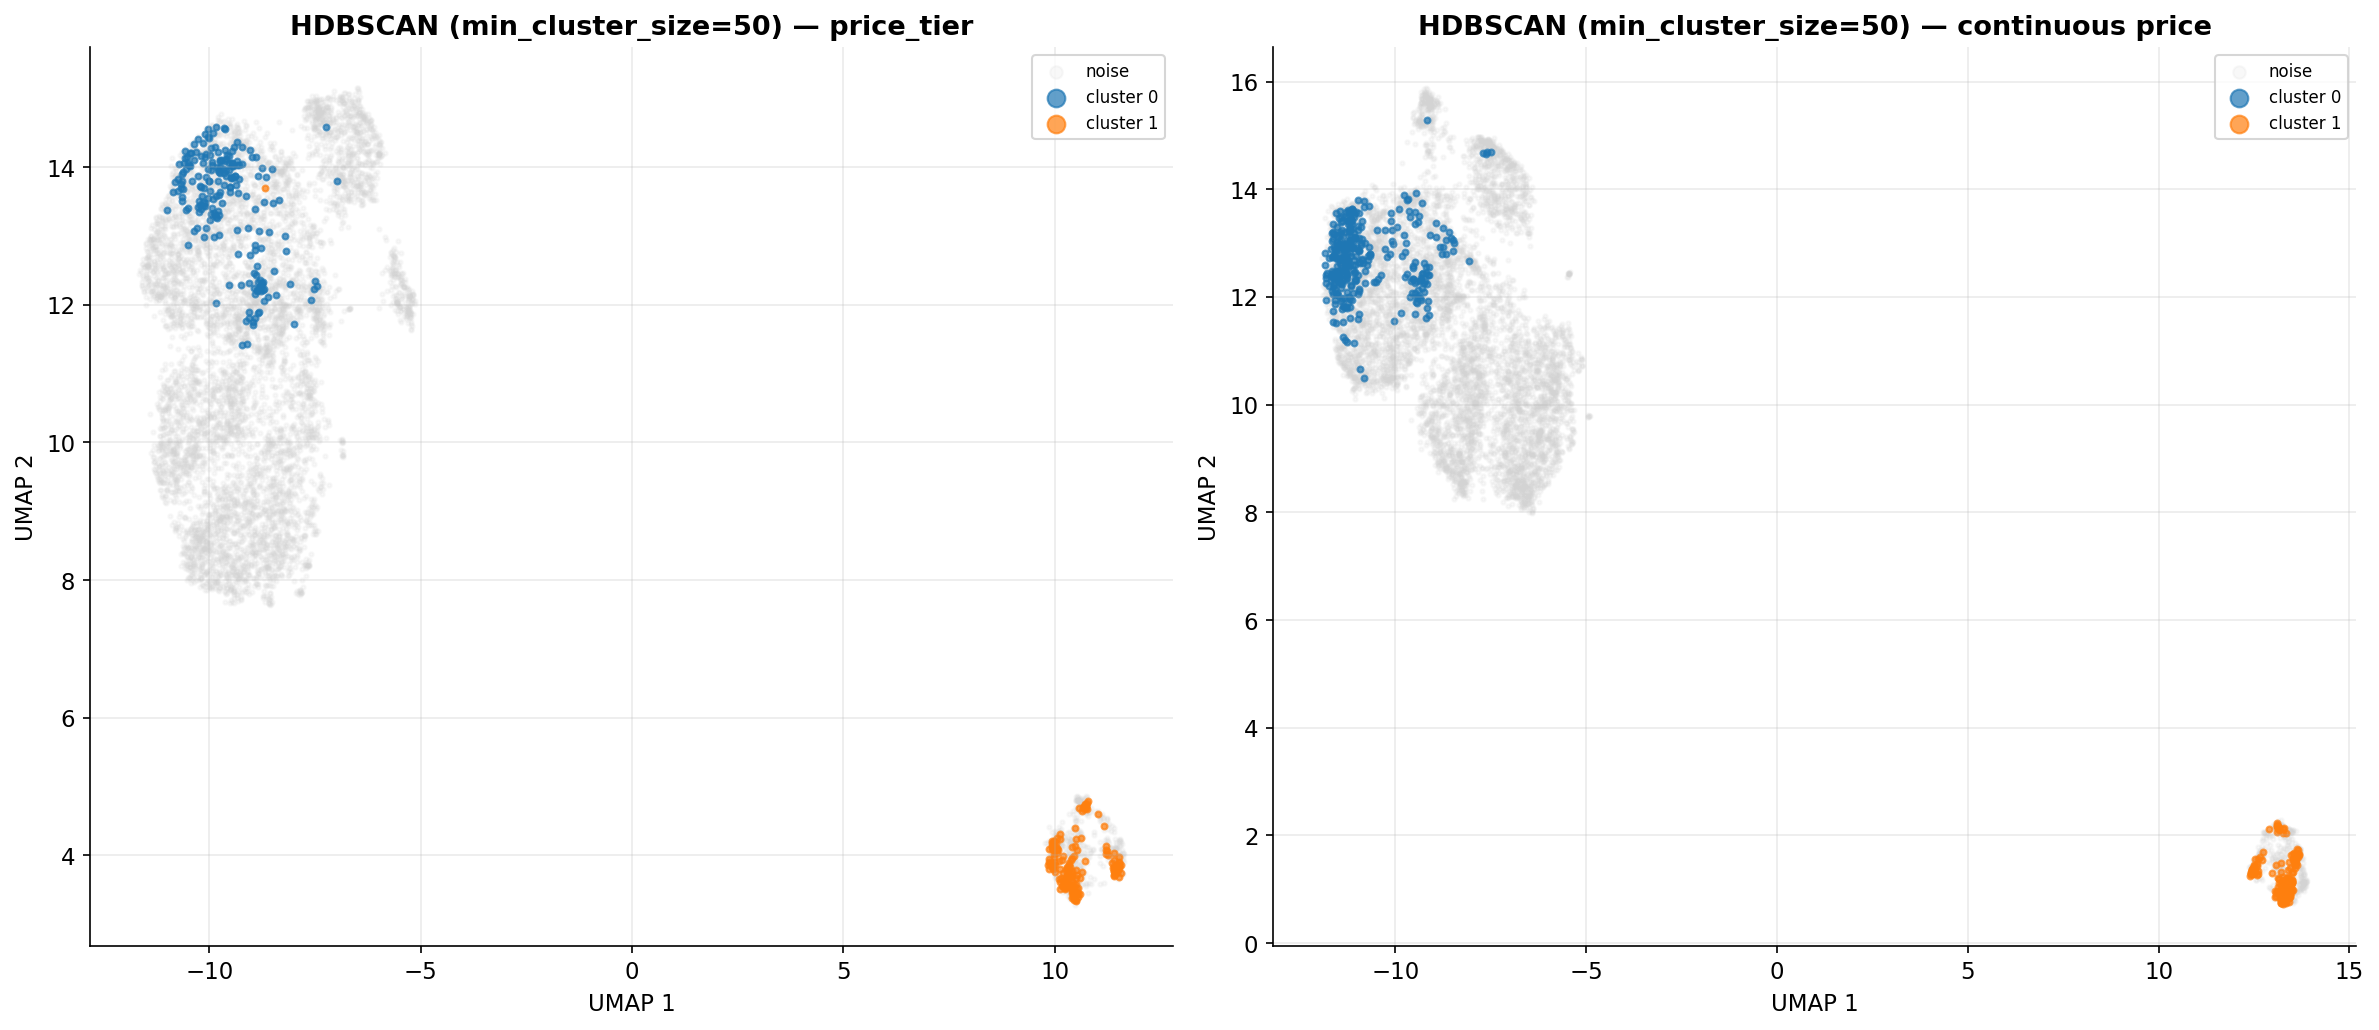

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (label, gower_dist_x, embedding_x) in zip(
    axes,
    [('price_tier', gower_dist_price, embedding_price), ('continuous price', gower_dist_cont, embedding_cont)]
):
    clusterer_x = hdbscan.HDBSCAN(min_cluster_size=50, metric='precomputed')
    hdbscan_labels_x = clusterer_x.fit_predict(gower_dist_x.astype('float64'))

    noise_mask_x = hdbscan_labels_x == -1
    ax.scatter(embedding_x[noise_mask_x, 0], embedding_x[noise_mask_x, 1], s=4, alpha=0.15, color='lightgrey', label='noise')

    for cluster_id in sorted(set(hdbscan_labels_x) - {-1}):
        mask = hdbscan_labels_x == cluster_id
        ax.scatter(embedding_x[mask, 0], embedding_x[mask, 1], s=8, alpha=0.7, label=f'cluster {cluster_id}')

    ax.set_title(f'HDBSCAN (min_cluster_size=50) — {label}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()

Both maps find the same two locations dense enough to form a group: the small isolated island in the bottom right, and a tighter pocket within the upper portion of the main body. This holds regardless of whether price enters the feature set as a coarse tier or as a raw number, confirming these two groups are a genuine, stable feature of the data rather than something price-related structure produces or erases. The only real difference is scale, continuous price finds a slightly larger version of the upper pocket, consistent with its higher tolerance for noise seen in the sweep above (95.6% even at min_cluster_size=100, versus price_tier losing the group entirely at that threshold). Price, in either form, doesn't change which parts of the market are genuinely dense, it only shifts, mildly, how far that density extends.

### 8.8 Summary

Out of curiosity, both a coarse and a fine-grained version of price were tested directly inside the clustering, and the two behave differently. Price_tier changes almost nothing, silhouette, cluster assignment, and the HDBSCAN-detected dense groups all stay close to what the final configuration already found without it (ARI=0.82). Continuous price moves things more (ARI=0.56, a different optimal k), reorganizing part of the market's larger clusters around finer price distinctions the coarser tier doesn't carry.

Both checks converge on the same underlying reading: the two genuinely dense sub-groups already found throughout this notebook, the isolated island and the smaller pocket within the main body, are real and stable regardless of whether or how price enters the picture. What price does affect is the loosely-organized majority of the market, and it affects it more the more granular the price signal is. This is exactly the property that justified keeping price external from the start: it carries enough independent signal to reshape the grouping if given the chance, which is precisely why it's more useful left outside as a lens for interpreting the clusters than folded in as an input that defines them.

## 9. Stability Validation

Every check so far has run on the full population of reviewed listings. This section asks a different question: if the same clustering were repeated on a different random subset of the same market, would it find a similar structure, or does the result depend heavily on which specific listings happened to be included? Three to five bootstrap samples (80% of the data each, different random seeds) are clustered independently with the final configuration, and compared pairwise via ARI. A stable result should produce partitions that agree with each other about as well as they agree with the full-data result.

### 9.1 Bootstrap Sampling & Re-Clustering

In [102]:
N_BOOTSTRAP = 5
BOOTSTRAP_FRACTION = 0.8

X_final_full = experiment_matrices['Exp2_core_flags'][0]
cat_idx_final = experiment_matrices['Exp2_core_flags'][1]

bootstrap_results = {}
for i in range(N_BOOTSTRAP):
    rng = np.random.RandomState(100 + i)
    sample_idx = rng.choice(len(X_final_full), size=int(len(X_final_full) * BOOTSTRAP_FRACTION), replace=False)
    X_boot = X_final_full.iloc[sample_idx]

    kproto_boot = KPrototypes(n_clusters=5, init='Huang', n_init=5, gamma=1.5, random_state=100+i, n_jobs=-1)
    labels_boot = kproto_boot.fit_predict(X_boot.to_numpy(), categorical=cat_idx_final)

    bootstrap_results[i] = {'sample_idx': sample_idx, 'labels': labels_boot, 'cost': kproto_boot.cost_}
    print(f"bootstrap {i}: n={len(X_boot)}, cost={kproto_boot.cost_:.1f}")

print(f"\n{N_BOOTSTRAP} bootstrap runs complete")

bootstrap 0: n=24574, cost=2157196.2
bootstrap 1: n=24574, cost=2173656.2
bootstrap 2: n=24574, cost=2176006.9
bootstrap 3: n=24574, cost=2156589.0
bootstrap 4: n=24574, cost=2157536.6

5 bootstrap runs complete


### 9.2 Pairwise ARI Between Bootstrap Runs

In [103]:
from itertools import combinations

pairwise_ari = []
for i, j in combinations(range(N_BOOTSTRAP), 2):
    idx_i = set(bootstrap_results[i]['sample_idx'])
    idx_j = set(bootstrap_results[j]['sample_idx'])
    common_idx = sorted(idx_i & idx_j)

    pos_i = {v: k for k, v in enumerate(bootstrap_results[i]['sample_idx'])}
    pos_j = {v: k for k, v in enumerate(bootstrap_results[j]['sample_idx'])}

    labels_i_common = [bootstrap_results[i]['labels'][pos_i[idx]] for idx in common_idx]
    labels_j_common = [bootstrap_results[j]['labels'][pos_j[idx]] for idx in common_idx]

    ari = adjusted_rand_score(labels_i_common, labels_j_common)
    pairwise_ari.append({'run_i': i, 'run_j': j, 'n_common': len(common_idx), 'ARI': round(ari, 4)})
    print(f"bootstrap {i} vs {j}: ARI={ari:.4f} (n_common={len(common_idx)})")

pairwise_ari_df = pd.DataFrame(pairwise_ari)
print(f"\nmean ARI across all pairs: {pairwise_ari_df['ARI'].mean():.4f}")
print(f"min ARI: {pairwise_ari_df['ARI'].min():.4f}, max ARI: {pairwise_ari_df['ARI'].max():.4f}")

bootstrap 0 vs 1: ARI=0.3852 (n_common=19635)
bootstrap 0 vs 2: ARI=0.5962 (n_common=19691)
bootstrap 0 vs 3: ARI=0.6506 (n_common=19638)
bootstrap 0 vs 4: ARI=0.7464 (n_common=19664)
bootstrap 1 vs 2: ARI=0.4080 (n_common=19708)
bootstrap 1 vs 3: ARI=0.4412 (n_common=19649)
bootstrap 1 vs 4: ARI=0.4104 (n_common=19661)
bootstrap 2 vs 3: ARI=0.6544 (n_common=19646)
bootstrap 2 vs 4: ARI=0.5640 (n_common=19652)
bootstrap 3 vs 4: ARI=0.5772 (n_common=19673)

mean ARI across all pairs: 0.5434
min ARI: 0.3852, max ARI: 0.7464


In [104]:
final_labels_full_5 = final_grid_cost['Exp2_core_flags'][1.5][5]['labels']

for i in range(N_BOOTSTRAP):
    sample_idx = bootstrap_results[i]['sample_idx']
    labels_boot = bootstrap_results[i]['labels']
    labels_full_matching = final_labels_full_5[sample_idx]

    ari_vs_full = adjusted_rand_score(labels_full_matching, labels_boot)
    print(f"bootstrap {i} vs full-data final model: ARI={ari_vs_full:.4f}")

bootstrap 0 vs full-data final model: ARI=0.6367
bootstrap 1 vs full-data final model: ARI=0.4529
bootstrap 2 vs full-data final model: ARI=0.6870
bootstrap 3 vs full-data final model: ARI=0.9056
bootstrap 4 vs full-data final model: ARI=0.5804


Five bootstrap runs on 80% samples of the data, each properly tuned with multiple random initializations, produce moderately but not perfectly consistent structure. Pairwise agreement between the bootstrap runs themselves averages 0.54 (ARI), ranging from 0.39 to 0.75, and agreement between each bootstrap run and the full-data final model tells the same story, from 0.45 up to 0.91 depending on which 20% of listings happened to be left out.

This is consistent with everything else found in this notebook rather than a separate concern. Silhouette never rose much past 0.08-0.10 at any stage, meaning the clusters were never sharply separated to begin with, and a partition without hard boundaries is naturally more sensitive to which specific listings are included in a given sample. The stability found here isn't the kind that would come from five nearly identical partitions every time, but it isn't random either: real agreement shows up in every comparison, just at a moderate rather than a high level. Read alongside the HDBSCAN checks earlier, the honest picture is a market with two consistently reproducible dense segments and a broader remainder whose exact split into further groups shifts somewhat depending on the sample, a property of the market's continuous structure rather than a flaw in how the clustering was carried out.

## 10. Cluster Profiling

Every prior section worked toward finding and validating a partition of the market. This section asks what that partition actually means. Each of the five clusters is characterized across every available axis and the text signal that shaped the clustering itself, so that the segments can be compared on genuinely equal footing rather than through a single lens. Where a cluster relates to the two dense subgroups HDBSCAN found independently in earlier sections, that connection is made explicit.

### 10.1 Setup the Final Labels & Reattach All Variables

In [105]:
final_cluster_labels = final_grid_cost['Exp2_core_flags'][1.5][5]['labels']

profile_df = listings_reviewed.copy()
profile_df['cluster'] = final_cluster_labels

# reattach every external variable kept aside since
profile_df['price'] = price.loc[profile_df.index]
profile_df['price_tier'] = price_tier.loc[profile_df.index]
profile_df['latitude'] = latitude.loc[profile_df.index]
profile_df['longitude'] = longitude.loc[profile_df.index]
profile_df['neighbourhood_cleansed'] = neighbourhood_cleansed.loc[profile_df.index]

print(f"profile_df shape: {profile_df.shape}")
print(f"\ncluster label distribution:\n{profile_df['cluster'].value_counts().sort_index()}")

# sanity check: every row has a cluster label, no external variable introduced unexpected NaN
print(f"\nany NaN in cluster: {profile_df['cluster'].isna().any()}")
print(f"price NaN count (expected, kept as-is): {profile_df['price'].isna().sum()}")

profile_df shape: (30718, 152)

cluster label distribution:
cluster
0    6592
1    6987
2    5070
3    2954
4    9115
Name: count, dtype: int64

any NaN in cluster: False
price NaN count (expected, kept as-is): 2682


### 10.2 Cluster Sizes & Basic Overview

,n_listings,pct_of_market
cluster,,
0,6592,21.5
1,6987,22.7
2,5070,16.5
3,2954,9.6
4,9115,29.7


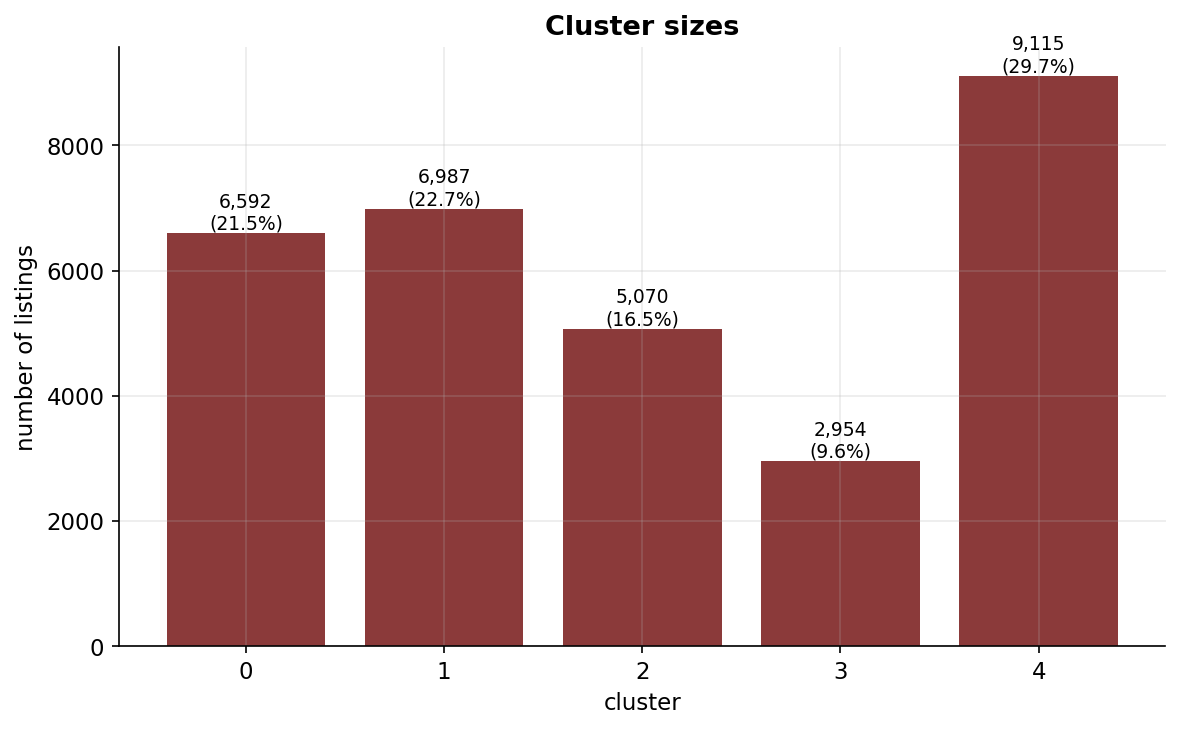

In [106]:
cluster_sizes = profile_df['cluster'].value_counts().sort_index()
cluster_pct = profile_df['cluster'].value_counts(normalize=True).sort_index().mul(100)

overview_table = pd.DataFrame({
    'n_listings': cluster_sizes,
    'pct_of_market': cluster_pct.round(1)
})
display(overview_table)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(overview_table.index.astype(str), overview_table['n_listings'], color=ROME_PALETTE['primary'])
for i, (n, pct) in enumerate(zip(overview_table['n_listings'], overview_table['pct_of_market'])):
    ax.text(i, n, f'{n:,}\n({pct}%)', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('cluster')
ax.set_ylabel('number of listings')
ax.set_title('Cluster sizes')
plt.tight_layout()
plt.show()

The five clusters aren't evenly sized. Cluster 4 is the largest by a wide margin, holding almost 30% of the market, while cluster 3 is the smallest at under 10%. Clusters 0, 1, and 2 sit in between, each covering 16-23% of listings. This uneven split is a first hint of what's ahead: some clusters are broad, catch-all groupings, while others carve out a narrower, more specific slice of the market.

### 10.3 Economic Profile

,median_price,mean_price,std_price,n_with_price
cluster,,,,
0,131.0,159.9,109.5,5968
1,142.0,172.3,114.4,6585
2,130.0,160.1,113.9,4621
3,119.5,145.6,102.8,2526
4,120.0,150.7,110.6,8336


price_tier,Budget,Luxury,Premium,Standard,Unknown
cluster,,,,,
0,22.3,8.5,14.1,45.7,9.5
1,17.8,10.8,16.2,49.5,5.8
2,23.6,9.1,13.5,45.1,8.9
3,25.5,5.7,10.7,43.6,14.5
4,27.0,7.4,12.2,44.9,8.5


/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_67614/1615911005.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='cluster', y='price', ax=axes[0], palette='tab10', showfliers=False)


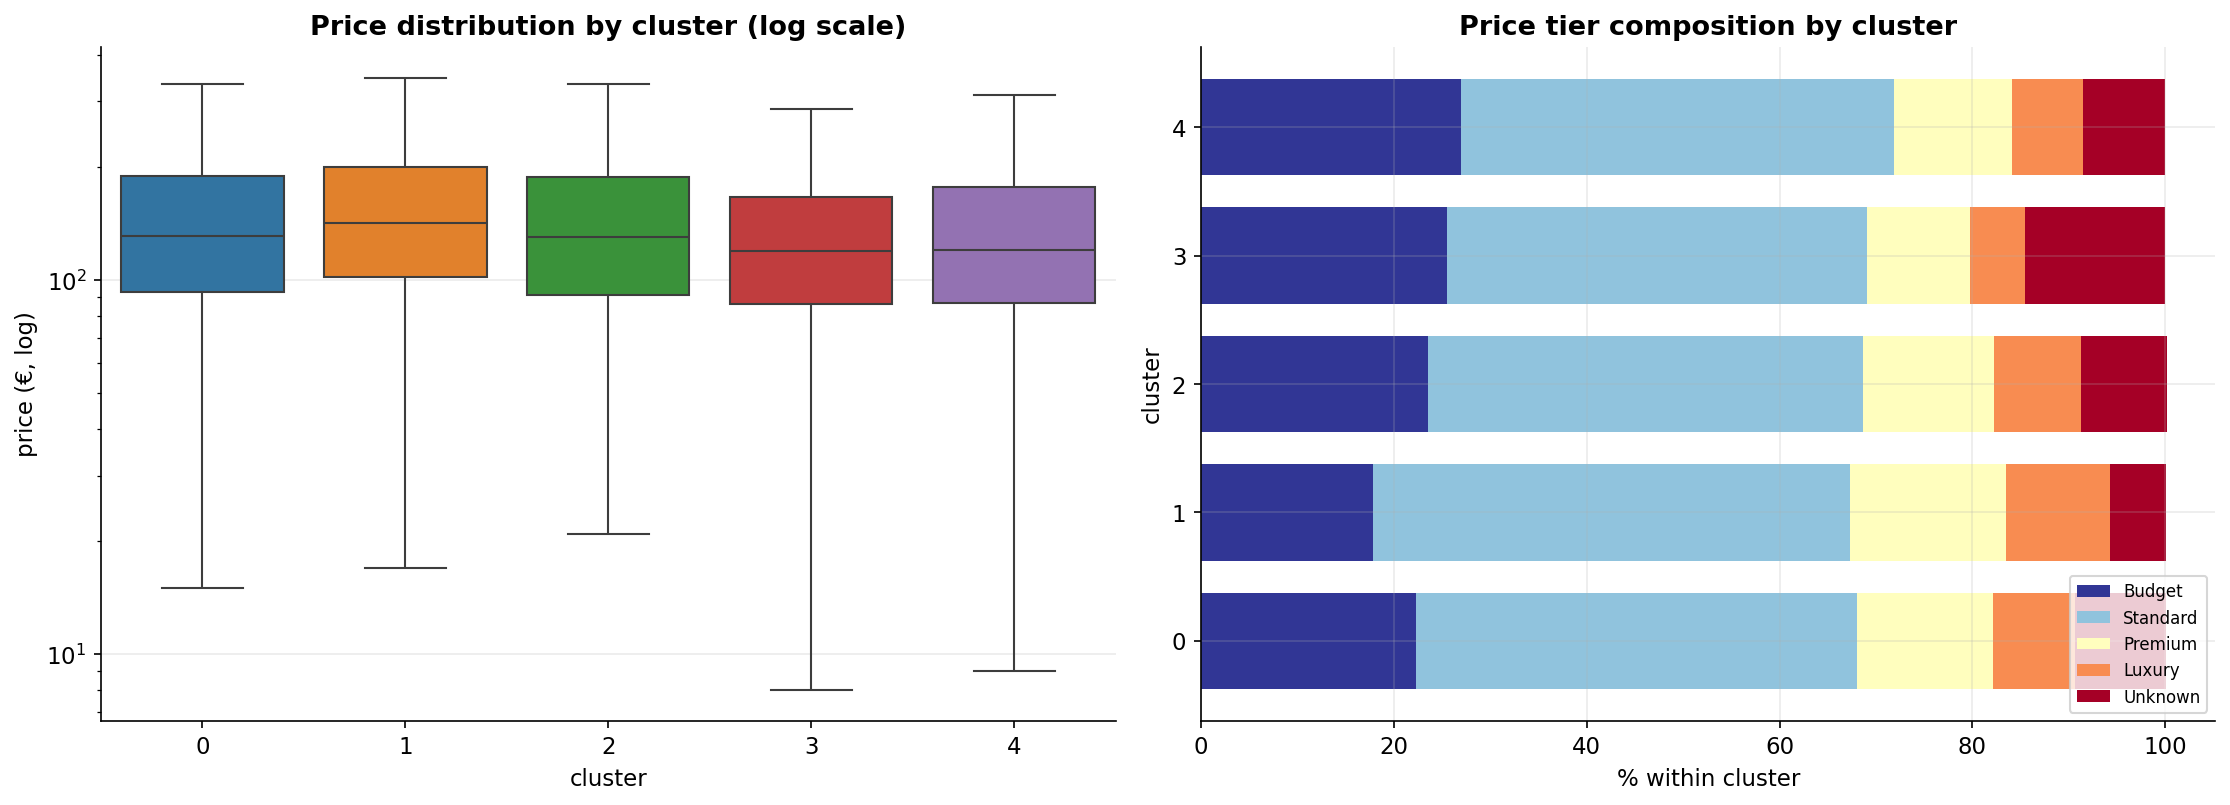

In [109]:
econ_summary = profile_df.groupby('cluster')['price'].agg(['median', 'mean', 'std', 'count']).round(1)
econ_summary.columns = ['median_price', 'mean_price', 'std_price', 'n_with_price']
display(econ_summary)

price_tier_by_cluster = pd.crosstab(profile_df['cluster'], profile_df['price_tier'], normalize='index').mul(100).round(1)
display(price_tier_by_cluster)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

plot_data = profile_df.dropna(subset=['price'])
sns.boxplot(data=plot_data, x='cluster', y='price', ax=axes[0], palette='tab10', showfliers=False)
axes[0].set_yscale('log')
axes[0].set_title('Price distribution by cluster (log scale)')
axes[0].set_ylabel('price (€, log)')

price_tier_order = ['Budget', 'Standard', 'Premium', 'Luxury', 'Unknown']
price_tier_by_cluster[price_tier_order].plot(kind='barh', stacked=True, ax=axes[1], colormap='RdYlBu_r', width=0.75)
axes[1].set_xlabel('% within cluster')
axes[1].set_title('Price tier composition by cluster')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

Price differs across clusters even though it was never part of the clustering itself, a first real sign that the segments carry economic meaning. Cluster 1 comes out as the most expensive (median €142), followed closely by clusters 0 and 2 (€130-131), while clusters 3 and 4 sit lower (€119-120). The gap isn't dramatic, roughly a 20% spread between the cheapest and priciest cluster, but it's consistent across the median, mean, and tier composition alike. Cluster 4 leans furthest toward Budget (27.0%) and lightest on Luxury (7.4%), while cluster 1 shows the opposite pattern (Luxury 10.8%, the highest of any cluster), matching its higher median exactly. Cluster 3 stands out for a different reason: its `Unknown` price tier share (14.5%) is nearly double every other cluster's, meaning a disproportionate share of its listings have no recorded price at all, worth keeping in mind alongside its price figures rather than reading them as fully representative of the whole cluster.

### 10.4 Geographic Profile

In [110]:
geo_sector_by_cluster = pd.crosstab(profile_df['cluster'], profile_df['geo_sector'], normalize='index').mul(100).round(1)
display(geo_sector_by_cluster)

neighbourhood_by_cluster = pd.crosstab(profile_df['cluster'], profile_df['neighbourhood_cleansed'], normalize='index').mul(100)
top3_neighbourhoods = {}
for cluster_id in sorted(profile_df['cluster'].unique()):
    top3 = neighbourhood_by_cluster.loc[cluster_id].sort_values(ascending=False).head(3)
    top3_neighbourhoods[cluster_id] = ', '.join(f"{name} ({pct:.1f}%)" for name, pct in top3.items())

for cluster_id, top3_str in top3_neighbourhoods.items():
    print(f"cluster {cluster_id}: {top3_str}")

geo_sector,E,N,NE,NW,S,SE,SW,W
cluster,,,,,,,,
0,18.2,7.3,9.7,16.1,7.2,10.6,14.9,15.9
1,18.9,8.0,8.3,17.7,5.2,11.6,14.3,16.1
2,22.2,6.6,11.1,15.7,5.6,10.5,13.4,14.9
3,16.7,6.7,11.9,19.7,8.3,11.6,12.7,12.5
4,21.3,6.2,9.6,16.1,6.5,11.0,14.7,14.6


cluster 0: I Centro Storico (49.7%), VII San Giovanni/Cinecittà (8.5%), XIII Aurelia (7.3%)
cluster 1: I Centro Storico (61.6%), VII San Giovanni/Cinecittà (7.8%), XIII Aurelia (5.8%)
cluster 2: I Centro Storico (53.1%), II Parioli/Nomentano (8.0%), VII San Giovanni/Cinecittà (7.7%)
cluster 3: I Centro Storico (32.8%), VII San Giovanni/Cinecittà (9.8%), XIII Aurelia (8.3%)
cluster 4: I Centro Storico (45.2%), VII San Giovanni/Cinecittà (9.7%), XIII Aurelia (7.3%)


In [111]:
distance_by_cluster = profile_df.groupby('cluster')['distance_to_center_km_log'].apply(lambda x: np.expm1(x).median()).round(2)
print(f"\nmedian distance to center (km) by cluster:")
print(distance_by_cluster)


median distance to center (km) by cluster:
cluster
0    2.62
1    2.09
2    2.46
3    3.63
4    2.87
Name: distance_to_center_km_log, dtype: float64


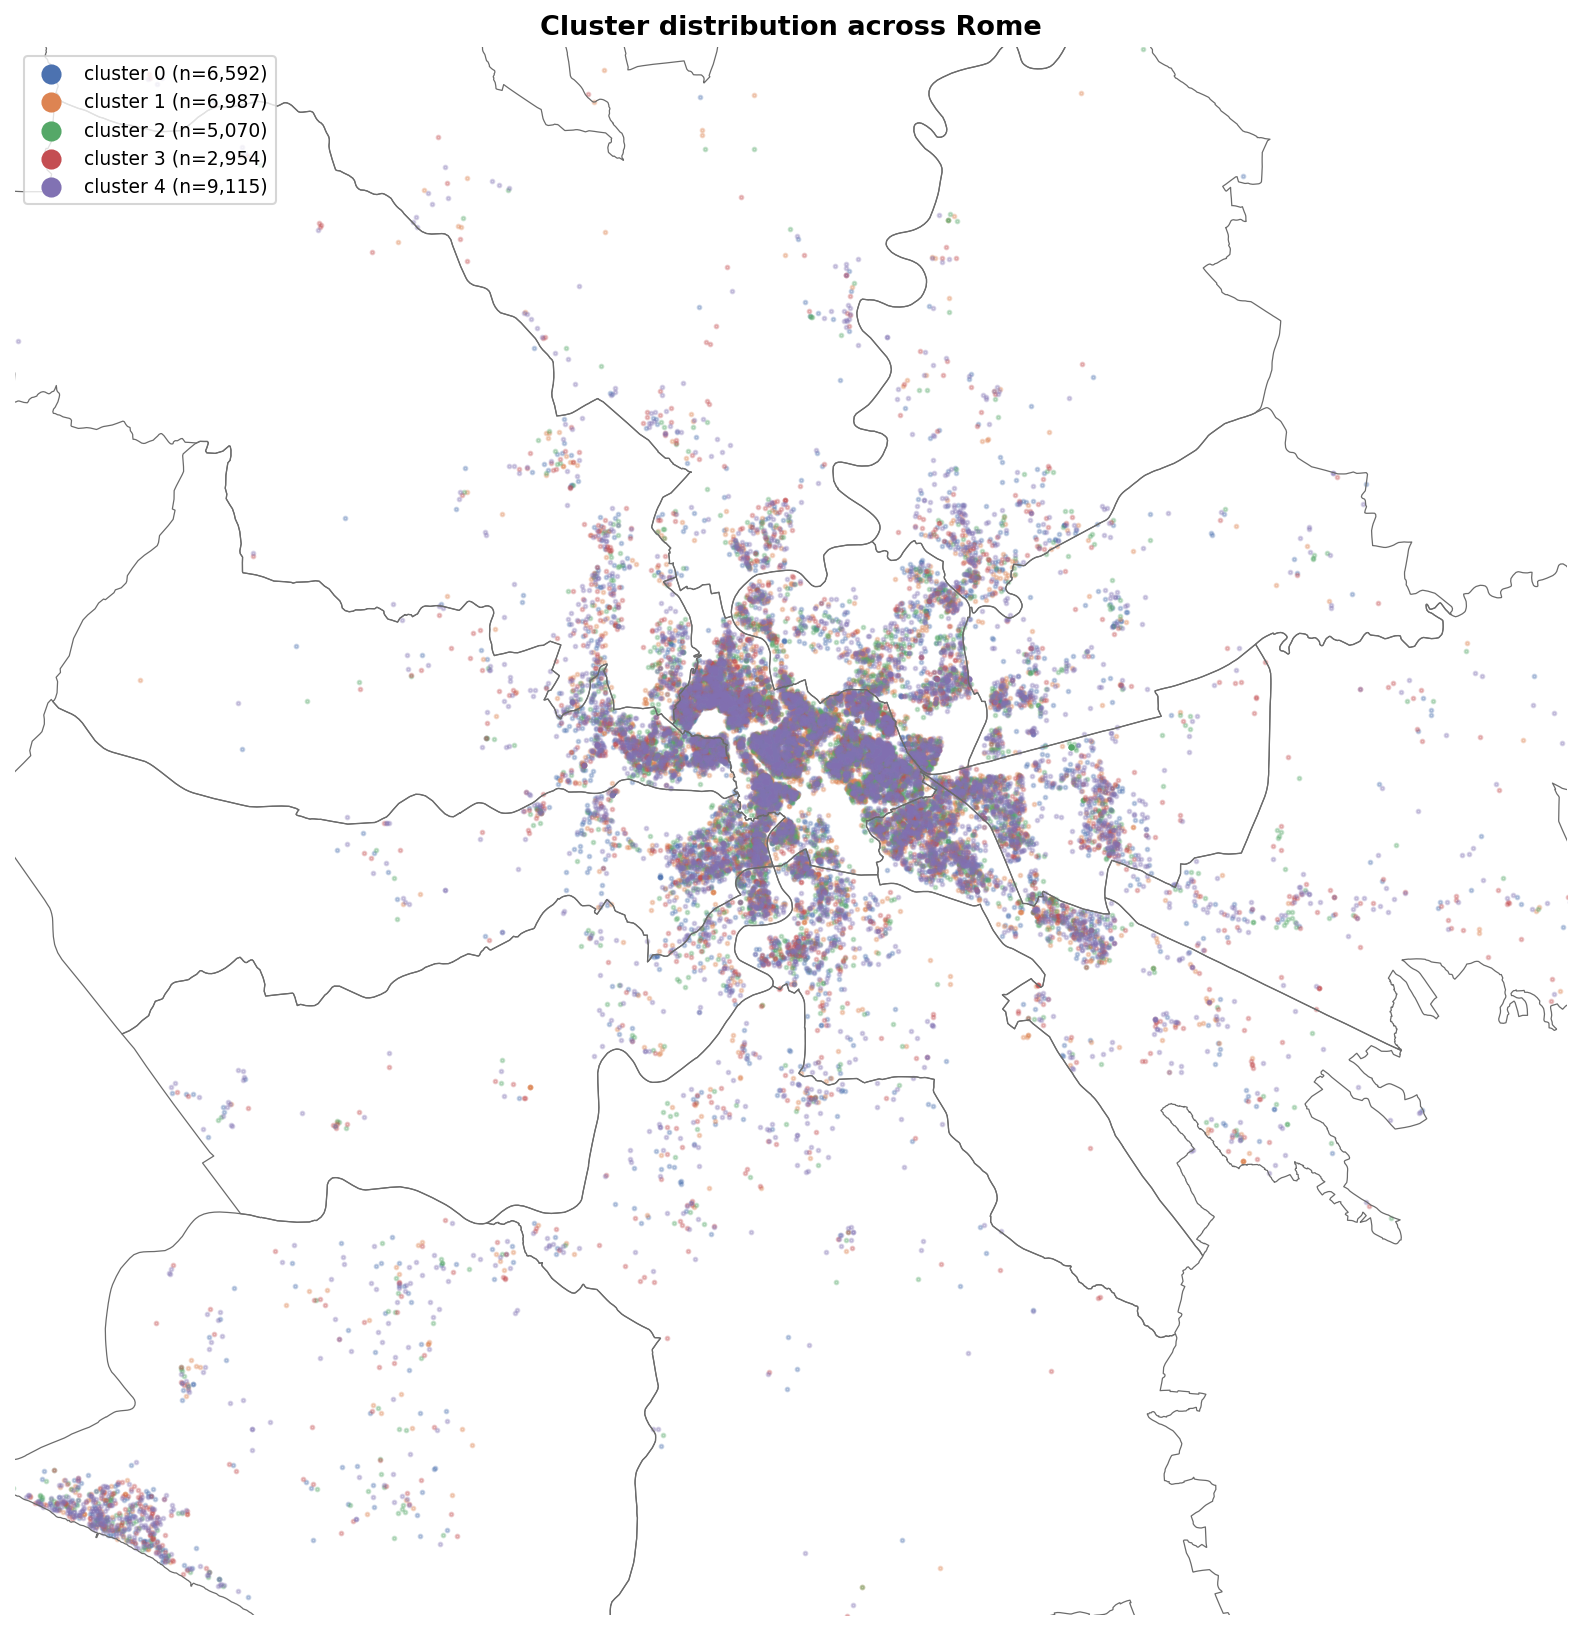

In [112]:
import geopandas as gpd
from shapely.geometry import Point

neighbourhoods = gpd.read_file(BASE_PATH / 'data' / 'raw' / 'neighbourhoods.geojson')

profile_geo = profile_df.dropna(subset=['latitude', 'longitude']).copy()
geometry = [Point(xy) for xy in zip(profile_geo['longitude'], profile_geo['latitude'])]
profile_geo = gpd.GeoDataFrame(profile_geo, geometry=geometry, crs='EPSG:4326')

if neighbourhoods.crs != profile_geo.crs:
    neighbourhoods = neighbourhoods.to_crs(profile_geo.crs)

lon_min, lon_max = profile_geo.geometry.x.quantile([0.001, 0.999])
lat_min, lat_max = profile_geo.geometry.y.quantile([0.001, 0.999])
pad = 0.01

CLUSTER_COLORS = {0: '#4c72b0', 1: '#dd8452', 2: '#55a868', 3: '#c44e52', 4: '#8172b3'}

fig, ax = plt.subplots(figsize=(11, 11))
neighbourhoods.plot(ax=ax, color='none', edgecolor=ROME_PALETTE['neutral'], linewidth=0.6, zorder=2)

for cluster_id in sorted(profile_geo['cluster'].unique()):
    sub = profile_geo[profile_geo['cluster'] == cluster_id]
    ax.scatter(sub.geometry.x, sub.geometry.y, s=3, alpha=0.3, color=CLUSTER_COLORS[cluster_id],
               label=f'cluster {cluster_id} (n={len(sub):,})', zorder=1)

ax.set_xlim(lon_min - pad, lon_max + pad)
ax.set_ylim(lat_min - pad, lat_max + pad)
ax.set_title('Cluster distribution across Rome')
leg = ax.legend(markerscale=5, fontsize=9, loc='upper left')
for lh in leg.legend_handles:
    lh.set_alpha(1.0)
ax.set_axis_off()
plt.tight_layout()
plt.show()

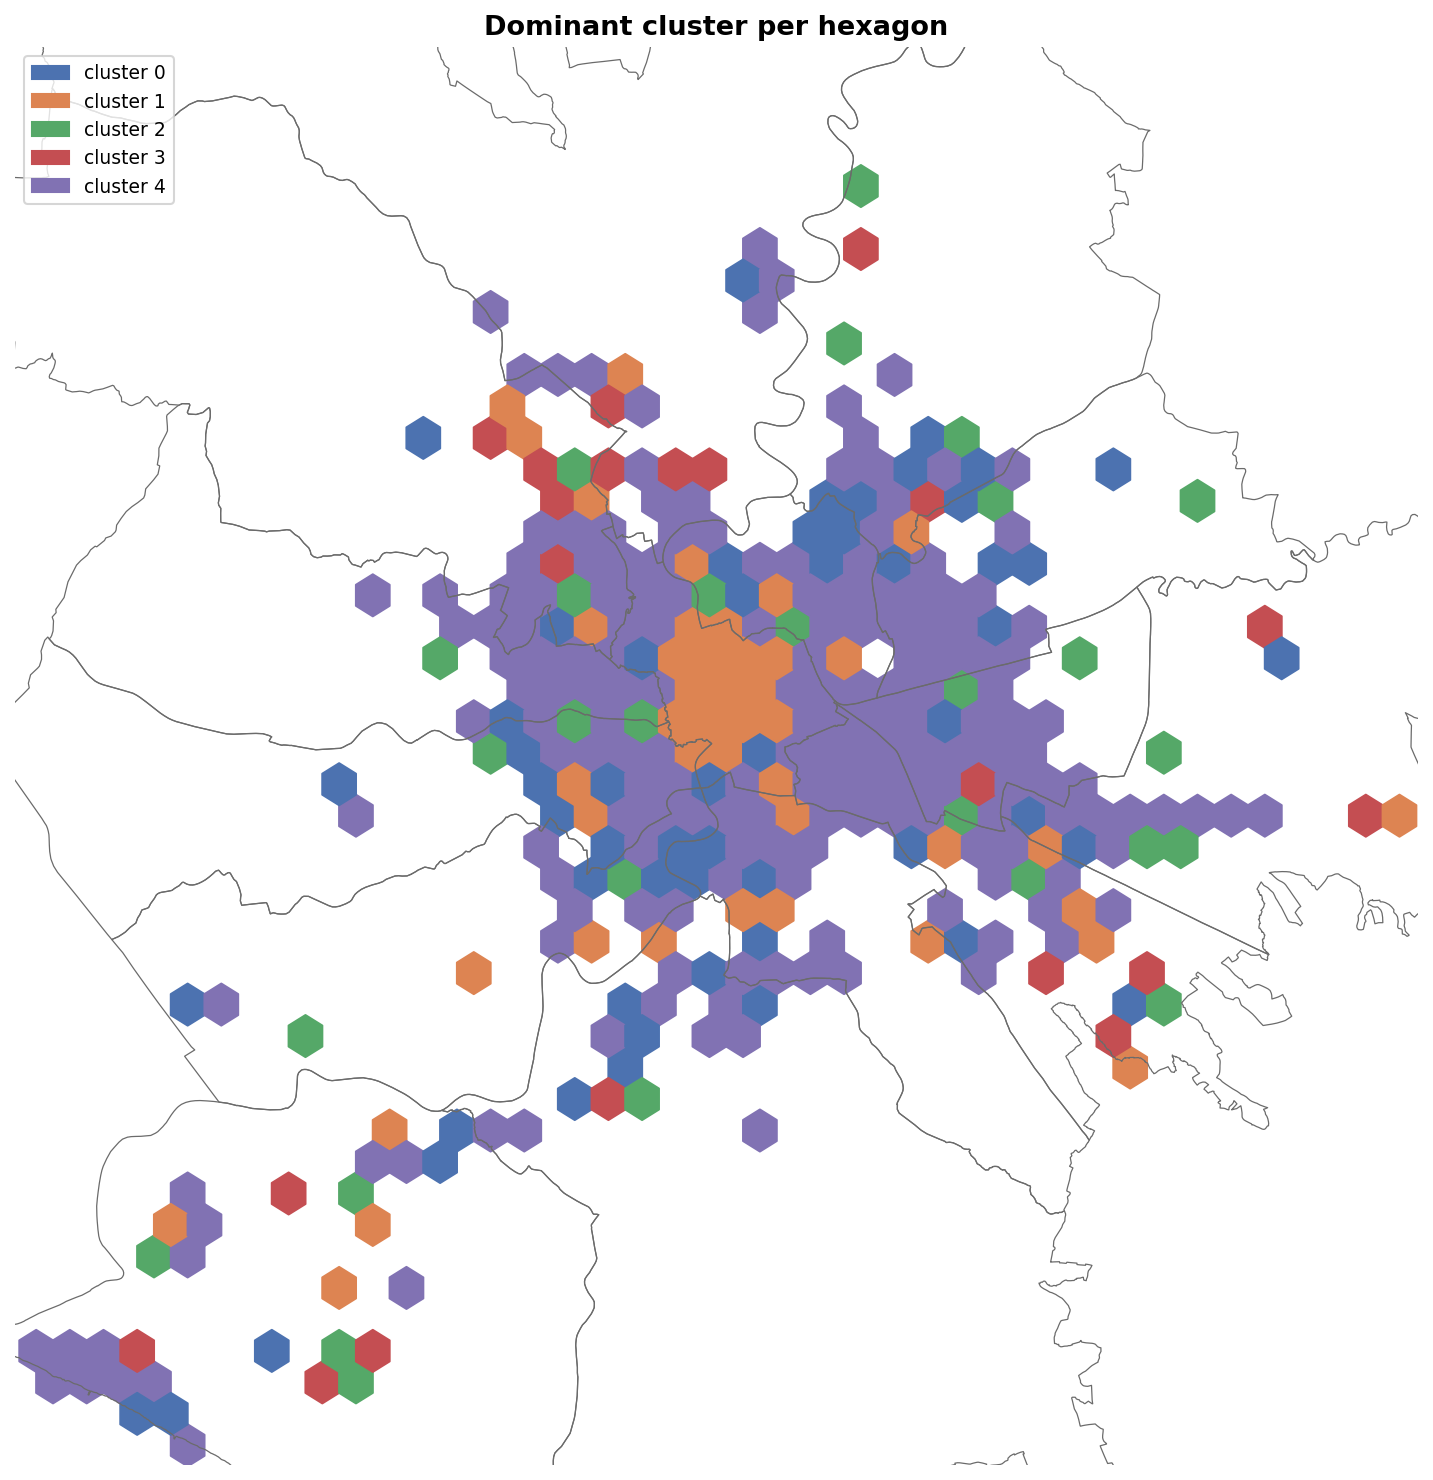

In [113]:
# per-municipio dominant cluster, using the same mode-hexbin approach as the EDA notebook
from scipy import stats as scipy_stats
from matplotlib.colors import ListedColormap

def mode_reduce(codes):
    return scipy_stats.mode(codes, keepdims=False).mode

fig, ax = plt.subplots(figsize=(10, 10))
neighbourhoods.plot(ax=ax, color='none', edgecolor=ROME_PALETTE['neutral'], linewidth=0.6, zorder=2)

hb = ax.hexbin(profile_geo.geometry.x, profile_geo.geometry.y, C=profile_geo['cluster'],
                reduce_C_function=mode_reduce, gridsize=55, mincnt=5,
                cmap=ListedColormap([CLUSTER_COLORS[i] for i in range(5)]), vmin=-0.5, vmax=4.5, zorder=1)

ax.set_xlim(lon_min - pad, lon_max + pad)
ax.set_ylim(lat_min - pad, lat_max + pad)
ax.set_title('Dominant cluster per hexagon')
from matplotlib.patches import Patch
legend_elements = [Patch(color=CLUSTER_COLORS[i], label=f'cluster {i}') for i in range(5)]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
ax.set_axis_off()
plt.tight_layout()
plt.show()

Geography turns out to be one of the weaker dividing lines between clusters. `geo_sector` composition is nearly identical across all five (E and NW dominate everywhere, in roughly the same proportions), and every cluster is anchored in I Centro Storico as its top neighbourhood, unsurprising given how much of the market sits there to begin with. The scattered point map confirms this visually: clusters are thoroughly intermixed across the city, with no cluster claiming a distinct territory of its own, and the fine-grained hexagon map shows the same story in sharper relief, cluster 4 (purple) blankets almost the entire city, while cluster 1 (orange) forms one dense, unmistakable island right at the historic core, exactly where the market is most concentrated.

The one real distinction is distance from the center. Cluster 1, the most expensive cluster, also sits closest to the center (median 2.09km) and shows the strongest concentration in Centro Storico (61.6%). Cluster 3, the cheapest and smallest cluster, sits furthest out (3.63km) and has the lowest Centro Storico share of any cluster (32.8%), a first hint that its identity may have more to do with distance and price than with location matching any other cluster. Beyond this one axis, geography doesn't separate the clusters much, whatever distinguishes them is coming from somewhere else.

### 10.5 Structural Profile

=== Continuous structural variables (median) ===

bathroom_count:
cluster
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: _restored, dtype: float64

beds_log:
cluster
0    2.0
1    2.0
2    2.0
3    2.0
4    2.0
Name: _restored, dtype: float64

amenities_count:
cluster
0    38.0
1    40.0
2    34.0
3    27.0
4    33.0
Name: _restored, dtype: float64

=== Categorical structural variables (top 3 per cluster) ===

property_type_grouped:
  cluster 0: entire home/apt (75.6%), private room (12.4%), b&b/hotel-type (6.1%)
  cluster 1: entire home/apt (77.4%), private room (11.8%), vacation home/villa (5.6%)
  cluster 2: entire home/apt (71.7%), private room (15.8%), b&b/hotel-type (7.7%)
  cluster 3: entire home/apt (59.4%), private room (20.2%), b&b/hotel-type (15.4%)
  cluster 4: entire home/apt (72.8%), private room (14.5%), b&b/hotel-type (7.4%)

bedrooms_binned:
  cluster 0: 1 bedroom (59.4%), 2 bedrooms (28.4%), 3+ bedrooms (9.0%)
  cluster 1: 1 bedroom (58.2%), 2 bedrooms (27.9%), 3+

,has_outdoor_leisure,has_fireplace,has_hot_tub,has_bbq,has_gym,bath_private_info,bath_shared_info,is_long_term_oriented
cluster,,,,,,,,
0,3.6,3.2,2.5,2.3,2.6,13.8,3.6,6.4
1,4.2,4.0,3.1,2.4,3.0,12.7,3.8,4.8
2,3.5,2.6,2.6,2.3,2.3,15.4,6.4,7.4
3,3.6,1.8,3.7,2.3,1.8,27.4,5.0,12.2
4,3.4,2.3,2.5,2.2,1.8,15.1,4.3,6.6


/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_67614/2090307111.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=profile_df, x='cluster', y='amenities_count', ax=axes[0], palette='tab10', showfliers=False)


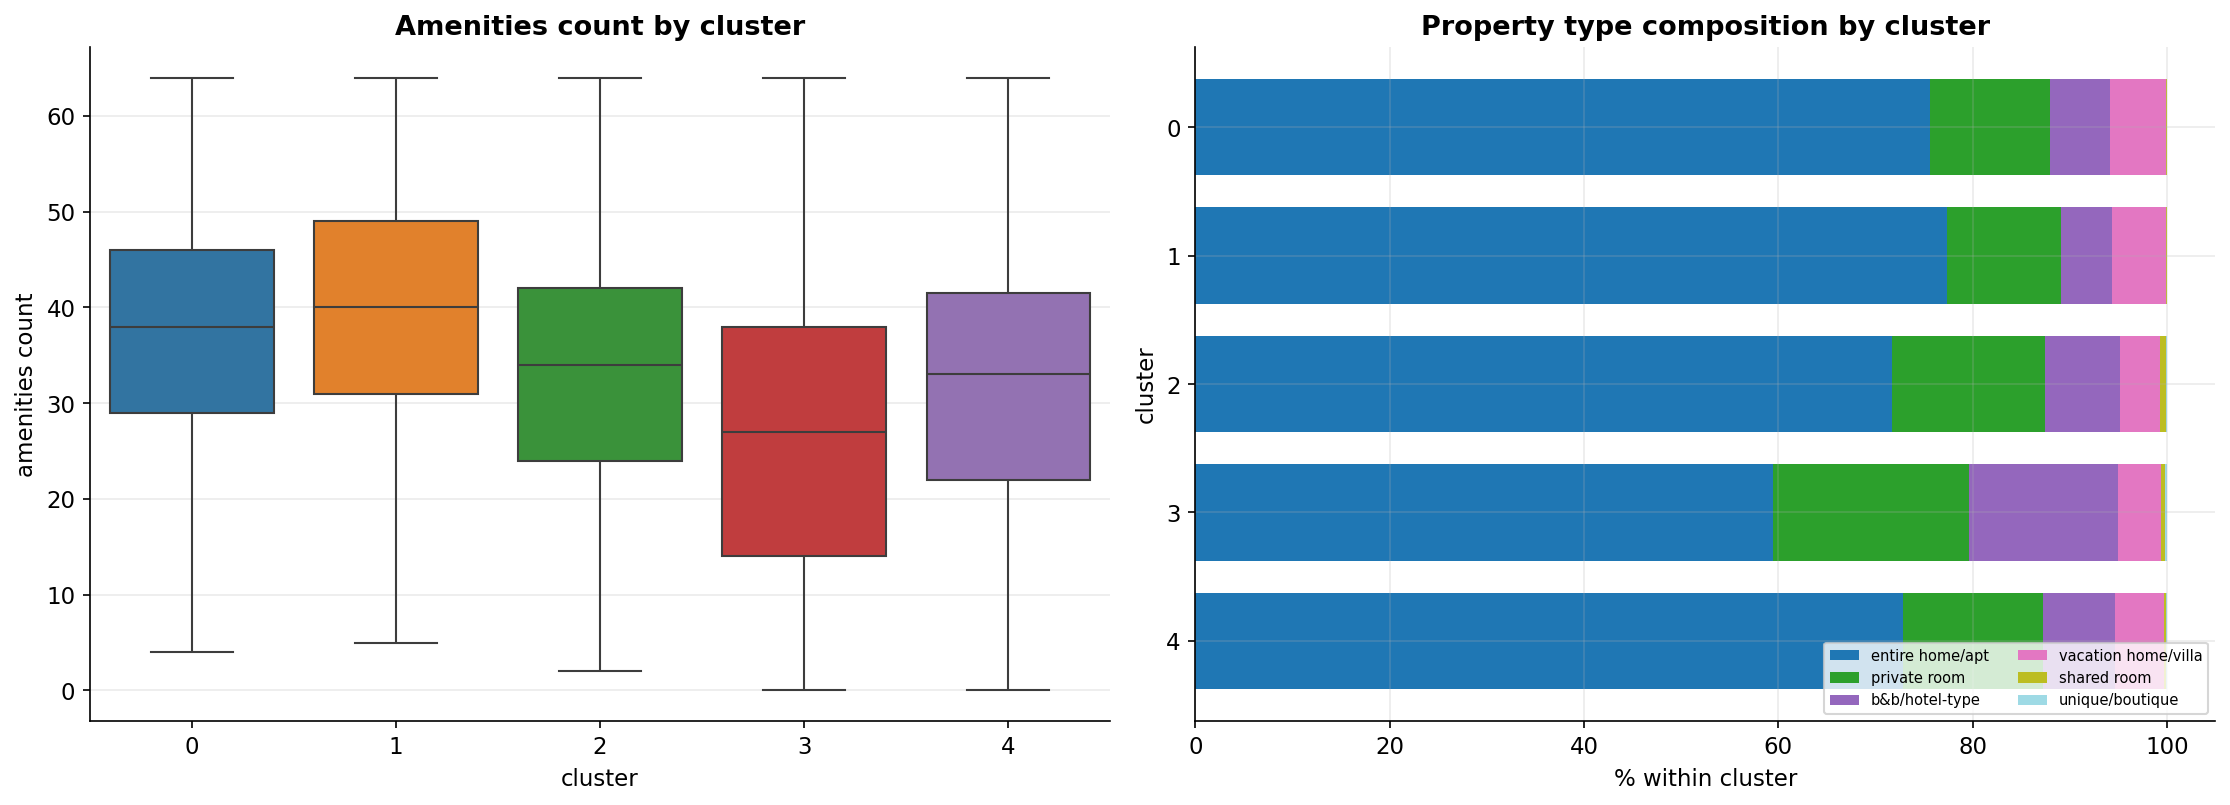

In [116]:
STRUCTURAL_CONTINUOUS = ['bathroom_count', 'beds_log', 'amenities_count']
STRUCTURAL_CATEGORICAL = ['property_type_grouped', 'bedrooms_binned', 'accommodates_per_bedroom_binned']
STRUCTURAL_BINARY = ['has_outdoor_leisure', 'has_fireplace', 'has_hot_tub', 'has_bbq', 'has_gym',
                       'bath_private_info', 'bath_shared_info', 'is_long_term_oriented']

print("=== Continuous structural variables (median) ===")
for col in STRUCTURAL_CONTINUOUS:
    restored = np.expm1(profile_df[col]) if col.endswith('_log') else profile_df[col]
    summary = profile_df.assign(_restored=restored).groupby('cluster')['_restored'].median().round(2)
    print(f"\n{col}:")
    print(summary)

print("\n=== Categorical structural variables (top 3 per cluster) ===")
for col in STRUCTURAL_CATEGORICAL:
    print(f"\n{col}:")
    for cluster_id in sorted(profile_df['cluster'].unique()):
        top3 = profile_df.loc[profile_df['cluster'] == cluster_id, col].value_counts(normalize=True).mul(100).head(3)
        top3_str = ', '.join(f"{idx} ({pct:.1f}%)" for idx, pct in top3.items())
        print(f"  cluster {cluster_id}: {top3_str}")

print("\n=== Binary structural flags (% = 1 per cluster) ===")
binary_summary = profile_df.groupby('cluster')[STRUCTURAL_BINARY].mean().mul(100).round(1)
display(binary_summary)

# visualization: amenities_count distribution + property_type composition, the two axes that actually moved
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.boxplot(data=profile_df, x='cluster', y='amenities_count', ax=axes[0], palette='tab10', showfliers=False)
axes[0].set_title('Amenities count by cluster')
axes[0].set_ylabel('amenities count')

prop_by_cluster = pd.crosstab(profile_df['cluster'], profile_df['property_type_grouped'], normalize='index').mul(100)
prop_order = prop_by_cluster.sum().sort_values(ascending=False).index.tolist()
prop_by_cluster[prop_order].plot(kind='barh', stacked=True, ax=axes[1], colormap='tab20', width=0.75)
axes[1].set_xlabel('% within cluster')
axes[1].set_title('Property type composition by cluster')
axes[1].legend(loc='lower right', fontsize=7, ncol=2)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Physical structure is remarkably uniform across clusters. Bathroom count and bed count sit at the exact same median everywhere (1 bathroom, 2 beds), and bedroom composition, property type, and guests-per-bedroom all follow the same broad shape in every cluster, entire home/apt dominant, 1-bedroom units the norm, low guest-density the most common configuration. None of the niche amenity flags (outdoor leisure, fireplace, hot tub, BBQ, gym) exceeds 5% anywhere, too rare to meaningfully separate clusters on their own.

Amenities count is the one continuous variable that moves noticeably: cluster 1 leads (median 40) and cluster 3 trails well behind (27), a gap of about 13 amenities that tracks the same pattern already seen in price, cluster 1 richest and priciest, cluster 3 leanest and cheapest. Cluster 3 stands out further on several fronts at once: the lowest entire-home share (59.4% vs. 72-77% elsewhere), the highest private-room and B&B/hotel-type shares by a wide margin, more than double the private-bathroom-mention rate of any other cluster (27.4%), and by far the highest long-term-orientation rate (12.2%, roughly double the next closest cluster). Structurally, cluster 3 looks like a genuinely different kind of listing, smaller-scale, more room-share-oriented, and more geared toward longer stays, not just a cheaper version of the same product everyone else offers.

### 10.6 Host Profile

=== Continuous host variables (median) ===

calculated_host_listings_count_log:
cluster
0    1.0
1    3.0
2    4.0
3    3.0
4    1.0
Name: _restored, dtype: float64

host_experience_years:
cluster
0     7.2
1    10.2
2     9.8
3     3.8
4     4.2
Name: _restored, dtype: float64

=== Categorical host variables (top 3 per cluster) ===

host_response_time:
  cluster 0: within an hour (73.0%), unknown (16.2%), within a few hours (6.8%)
  cluster 1: within an hour (84.4%), unknown (7.6%), within a few hours (5.5%)
  cluster 2: within an hour (79.3%), unknown (9.6%), within a few hours (7.1%)
  cluster 3: within an hour (56.1%), unknown (28.1%), within a few hours (7.6%)
  cluster 4: within an hour (73.1%), unknown (14.2%), within a few hours (7.6%)

host_acceptance_rate_binned:
  cluster 0: full acceptance (63.9%), partial acceptance (27.9%), unknown (8.2%)
  cluster 1: full acceptance (65.9%), partial acceptance (30.3%), unknown (3.8%)
  cluster 2: full acceptance (59.9%), partial acceptan

,host_is_superhost,has_response_data
cluster,,
0,46.7,83.8
1,61.6,92.4
2,45.4,90.4
3,12.8,71.9
4,42.1,85.8


/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_67614/794113382.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='cluster', y='_portfolio', ax=axes[0], palette='tab10', showfliers=False)


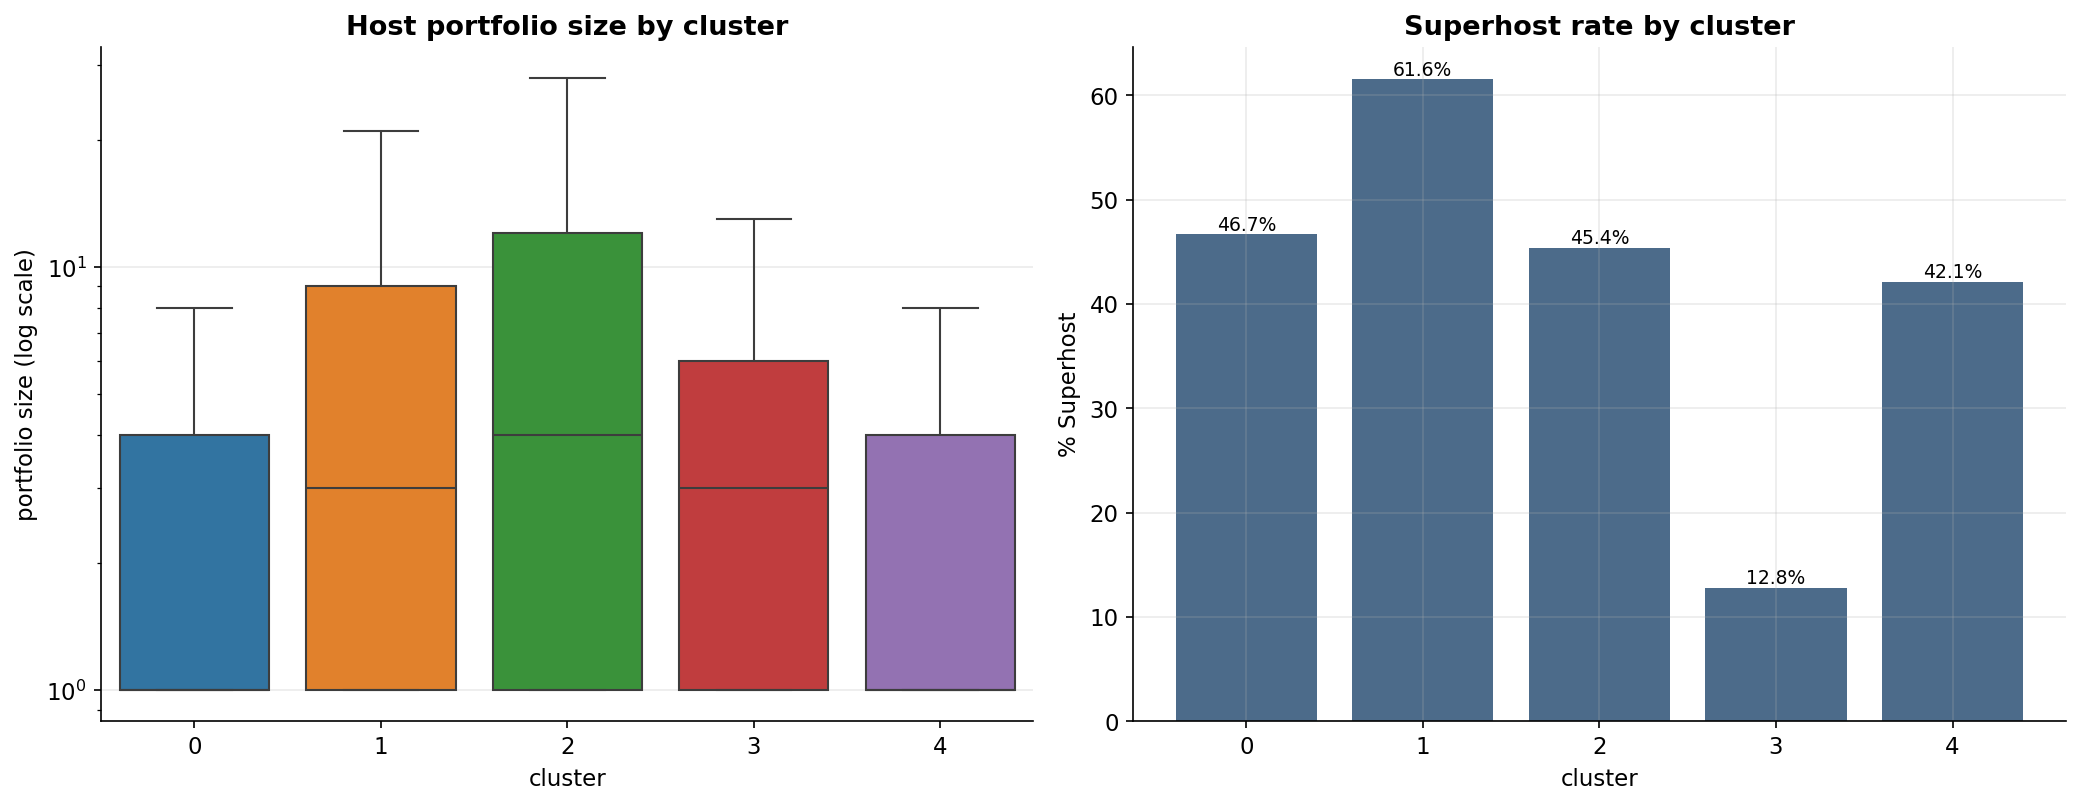

In [117]:
HOST_CONTINUOUS = ['calculated_host_listings_count_log', 'host_experience_years']
HOST_CATEGORICAL = ['host_response_time', 'host_acceptance_rate_binned', 'host_response_rate_binned']
HOST_BINARY = ['host_is_superhost', 'has_response_data']

print("=== Continuous host variables (median) ===")
for col in HOST_CONTINUOUS:
    restored = np.expm1(profile_df[col]) if col.endswith('_log') else profile_df[col]
    summary = profile_df.assign(_restored=restored).groupby('cluster')['_restored'].median().round(2)
    print(f"\n{col}:")
    print(summary)

print("\n=== Categorical host variables (top 3 per cluster) ===")
for col in HOST_CATEGORICAL:
    print(f"\n{col}:")
    for cluster_id in sorted(profile_df['cluster'].unique()):
        top3 = profile_df.loc[profile_df['cluster'] == cluster_id, col].value_counts(normalize=True).mul(100).head(3)
        top3_str = ', '.join(f"{idx} ({pct:.1f}%)" for idx, pct in top3.items())
        print(f"  cluster {cluster_id}: {top3_str}")

print("\n=== Binary host flags (% = 1 per cluster) ===")
host_binary_summary = profile_df.groupby('cluster')[HOST_BINARY].mean().mul(100).round(1)
display(host_binary_summary)

# visualization: portfolio size distribution + superhost rate, the two clearest host-side signals
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

portfolio_restored = np.expm1(profile_df['calculated_host_listings_count_log'])
plot_data = profile_df.assign(_portfolio=portfolio_restored)
sns.boxplot(data=plot_data, x='cluster', y='_portfolio', ax=axes[0], palette='tab10', showfliers=False)
axes[0].set_yscale('log')
axes[0].set_ylabel('portfolio size (log scale)')
axes[0].set_title('Host portfolio size by cluster')

superhost_rate = profile_df.groupby('cluster')['host_is_superhost'].mean().mul(100)
axes[1].bar(superhost_rate.index.astype(str), superhost_rate.values, color=ROME_PALETTE['secondary'])
for i, v in enumerate(superhost_rate.values):
    axes[1].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('cluster')
axes[1].set_ylabel('% Superhost')
axes[1].set_title('Superhost rate by cluster')

plt.tight_layout()
plt.show()

Host behavior is where the clusters separate most sharply so far. Cluster 3 stands apart on almost every host-side measure: the lowest Superhost rate by a wide margin (12.8%, less than a third of any other cluster), the least host experience (3.8 years), the slowest response times (only 56.1% respond within an hour, and 28.1% have no response data at all), and the lowest response completeness. This lines up directly with cluster 3's structural profile from the previous section, smaller-scale, more room-share listings, more long-term oriented, and now, less experienced, less responsive hosts to match.

Cluster 1, the most expensive and highest-amenity cluster, leads on host quality too: the highest Superhost rate (61.6%), the fastest response times (84.4% within an hour), and the most complete response data (92.4%). Portfolio size tells a related but distinct story, clusters 1, 2, and 3 all show hosts managing multiple listings (median 3-4), while clusters 0 and 4 are dominated by single-listing hosts (median 1), a split that doesn't track price or quality directly, cluster 2 has a similarly large portfolio to cluster 1 but a much lower Superhost rate (45.4%) and shorter host tenure (9.8 vs. 10.2 years, close, but with acceptance/response numbers trailing cluster 1 throughout). Taken together, host quality and portfolio scale move somewhat independently of each other, but cluster 3 is unambiguously the market's least professionally-run segment on every dimension checked here.

### 10.7 Review Activity Profile

=== Continuous review activity variables (median) ===

review_engagement_score:
cluster
0    0.17
1    0.39
2    0.06
3   -0.34
4    0.03
Name: review_engagement_score, dtype: float64

median_review_length:
cluster
0    197.0
1    213.5
2    196.0
3    159.0
4    190.0
Name: median_review_length, dtype: float64

=== Ordinal review activity variables (mean, 0=lowest tier) ===

last_review_recency_binned_ordinal:
cluster
0    0.47
1    0.34
2    0.43
3    0.95
4    0.41
Name: last_review_recency_binned_ordinal, dtype: float64

reviews_per_month_binned_ordinal:
cluster
0    1.06
1    1.18
2    1.04
3    0.28
4    1.05
Name: reviews_per_month_binned_ordinal, dtype: float64

review_quality_pc1_binned_ordinal:
cluster
0    0.46
1    0.51
2    0.45
3    0.58
4    0.52
Name: review_quality_pc1_binned_ordinal, dtype: float64


/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_67614/2776006328.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=profile_df, x='cluster', y='review_engagement_score', ax=axes[0], palette='tab10', showfliers=False)


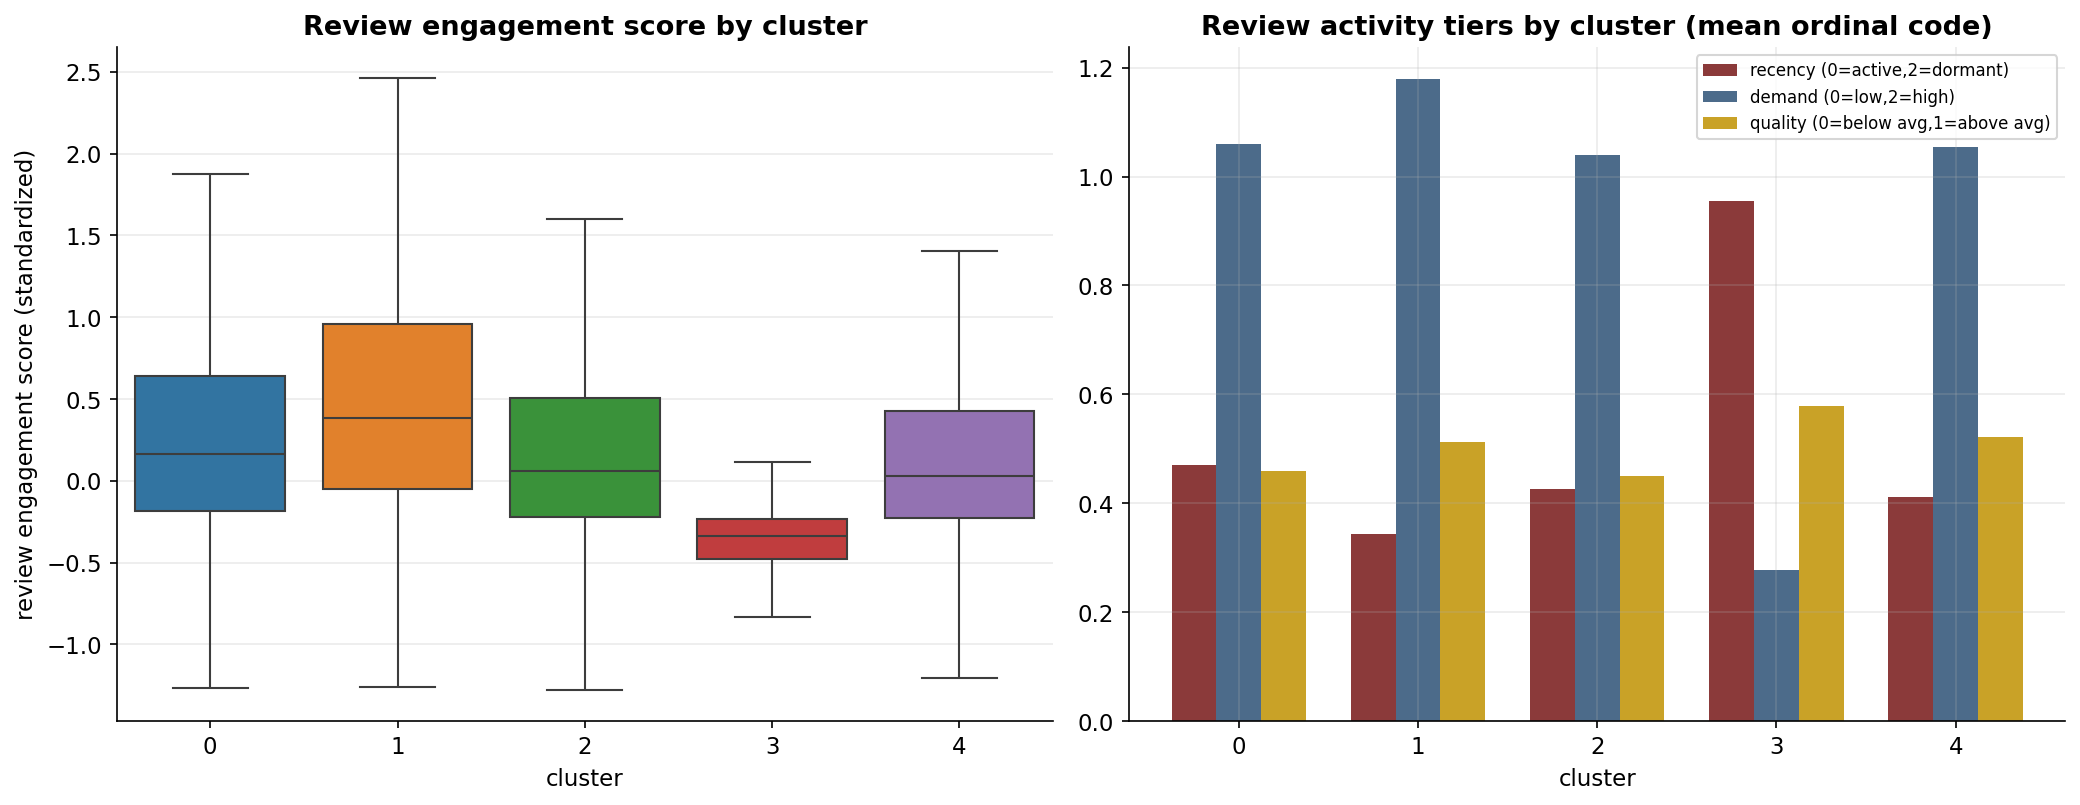

In [118]:
REVIEW_CONTINUOUS = ['review_engagement_score', 'median_review_length']
REVIEW_CATEGORICAL = ['last_review_recency_binned_ordinal', 'reviews_per_month_binned_ordinal', 'review_quality_pc1_binned_ordinal']

print("=== Continuous review activity variables (median) ===")
for col in REVIEW_CONTINUOUS:
    summary = profile_df.groupby('cluster')[col].median().round(2)
    print(f"\n{col}:")
    print(summary)

print("\n=== Ordinal review activity variables (mean, 0=lowest tier) ===")
for col in REVIEW_CATEGORICAL:
    summary = profile_df.groupby('cluster')[col].mean().round(2)
    print(f"\n{col}:")
    print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.boxplot(data=profile_df, x='cluster', y='review_engagement_score', ax=axes[0], palette='tab10', showfliers=False)
axes[0].set_title('Review engagement score by cluster')
axes[0].set_ylabel('review engagement score (standardized)')

recency_by_cluster = profile_df.groupby('cluster')['last_review_recency_binned_ordinal'].mean()
demand_by_cluster = profile_df.groupby('cluster')['reviews_per_month_binned_ordinal'].mean()
quality_by_cluster = profile_df.groupby('cluster')['review_quality_pc1_binned_ordinal'].mean()

x = np.arange(5)
width = 0.25
axes[1].bar(x - width, recency_by_cluster, width, label='recency (0=active,2=dormant)', color=ROME_PALETTE['primary'])
axes[1].bar(x, demand_by_cluster, width, label='demand (0=low,2=high)', color=ROME_PALETTE['secondary'])
axes[1].bar(x + width, quality_by_cluster, width, label='quality (0=below avg,1=above avg)', color=ROME_PALETTE['accent'])
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(i) for i in range(5)])
axes[1].set_xlabel('cluster')
axes[1].set_title('Review activity tiers by cluster (mean ordinal code)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Review activity confirms cluster 3 as the market's least active segment, consistent with everything found about it so far. It has by far the lowest engagement score (-0.34, the only negative value in the table), the least frequent reviews (demand tier 0.28, well below every other cluster's 1.0+), and the most dormant listings on average (recency tier 0.95, close to the "dormant" end of the scale where every other cluster sits closer to "active"). Its reviews also run noticeably shorter (median 159 characters vs. 190-214 elsewhere). Interestingly, review quality doesn't follow the same pattern, cluster 3 actually scores marginally highest on the quality tier (0.58), meaning the reviews it does get skew positive even though there are fewer of them and they arrive less often, a listing that's quiet rather than poorly regarded.

Cluster 1 sits at the opposite end on every measure that moved for cluster 3: highest engagement (0.39), most frequent reviews, most active recency, and the longest reviews, matching its lead on price, amenities, and host quality throughout this profile. Clusters 0, 2, and 4 stay close together in the middle, engaged and reasonably active, but without cluster 1's clear edge or cluster 3's clear deficit.

### 10.8 Text & Content Profile

This is the section that matters most for interpreting what the clustering actually found, since these are the features (tone/topic core plus the eleven content flags) that shaped the partition directly, unlike price or geography, which were checked only afterward.

#### 10.8.1 Sentiment & Content Flags

=== Sentiment (mean tier, 0=low to 2=high where applicable) ===


sentiment_mean_binned,high,low,medium,unknown
cluster,,,,
0,28.9,34.4,36.7,NaN
1,31.9,27.3,40.7,0.1
2,30.8,38.8,30.4,0.0
3,39.3,31.2,15.2,14.3
4,35.5,33.3,31.2,NaN



=== Content flags: % of listings mentioning each tone (per cluster) ===


cluster,0,1,2,3,4
has_neighborhood_overview_exclaim,8.7,11.4,0.8,1.2,0.1
has_neighborhood_overview_family,5.3,5.4,0.4,1.4,0.1
has_description_self_ref,5.7,7.3,4.9,2.4,4.1
has_neighborhood_overview_romantic,2.6,3.8,0.3,0.4,0.0
has_host_about_professionalism,0.3,3.9,3.2,1.3,0.1
has_host_about_budget,0.1,7.6,5.5,1.4,0.1
has_neighborhood_overview_self_ref,4.2,5.4,0.6,0.5,0.2
has_host_about_atmosphere_lively,0.4,11.9,8.2,2.6,0.3
has_host_about_atmosphere_quiet,0.1,4.2,3.1,0.9,0.1
has_neighborhood_overview_budget,4.4,4.9,0.4,0.9,0.1


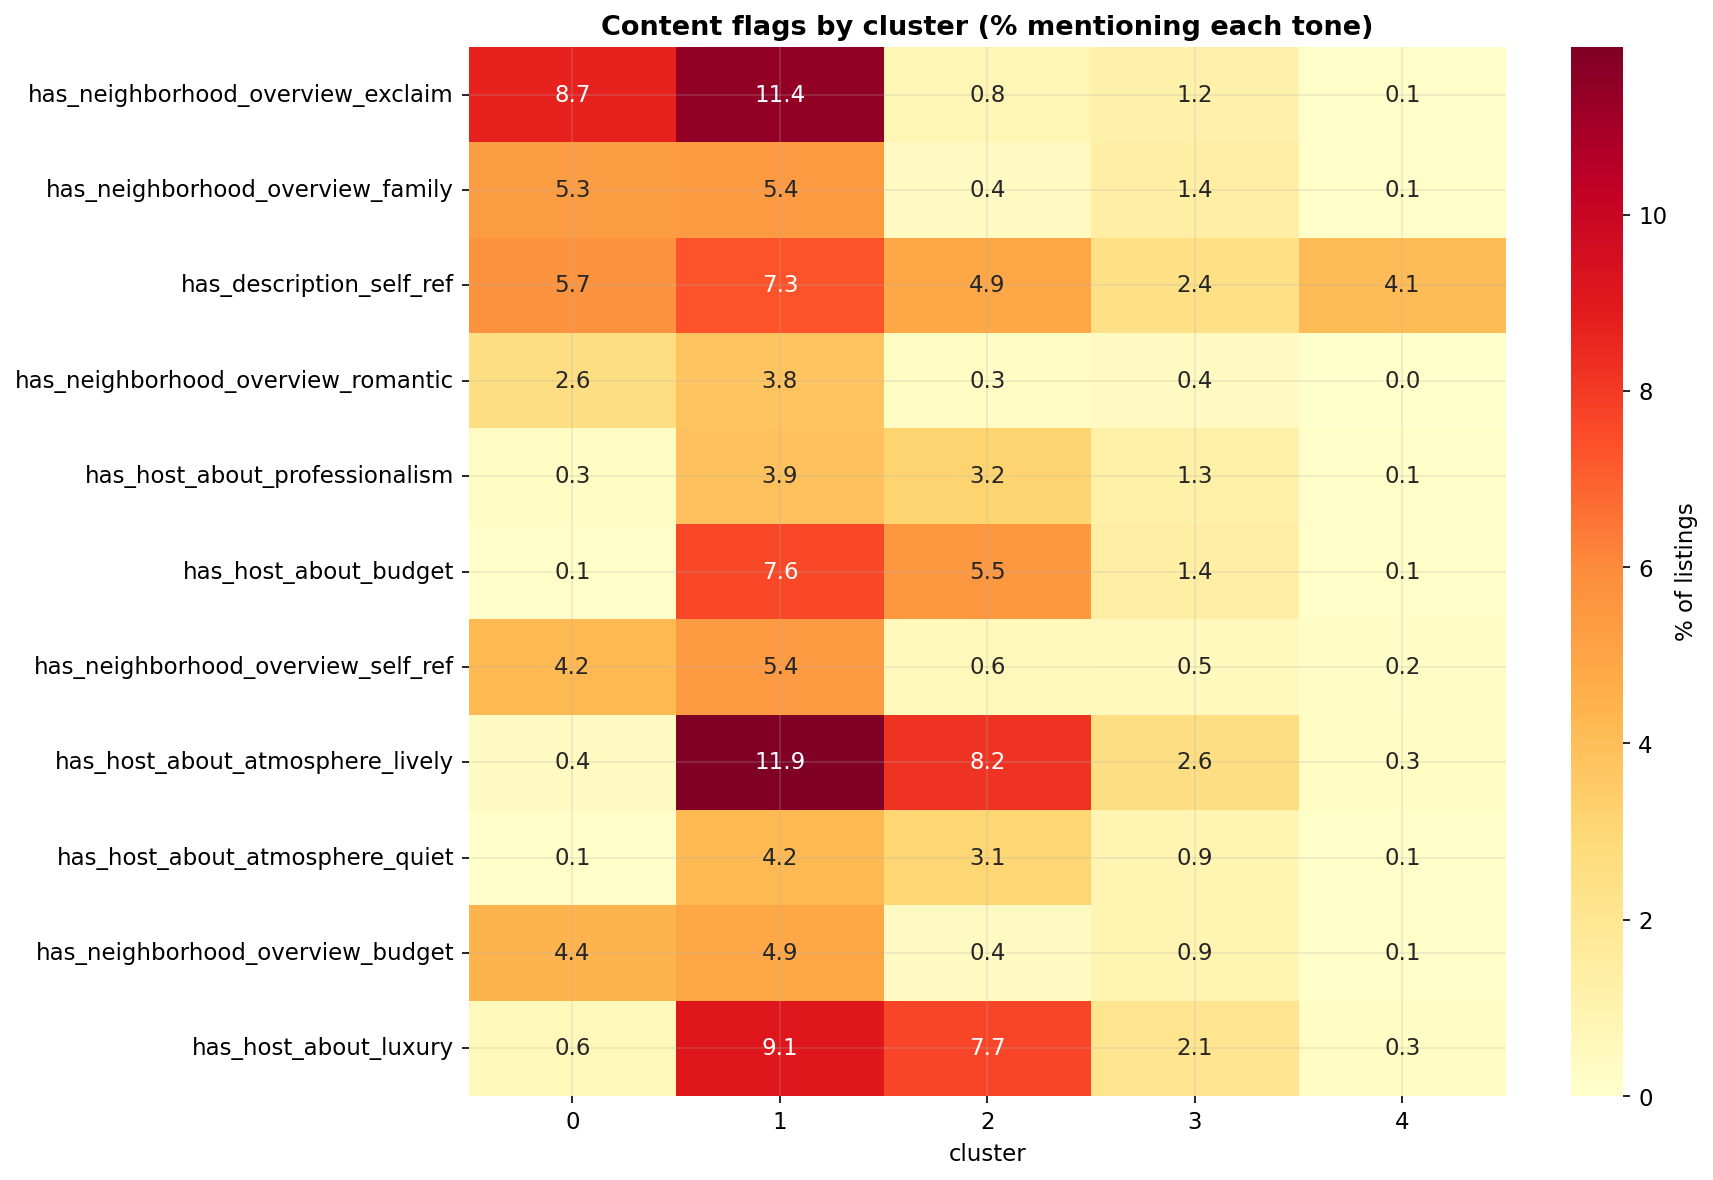

In [119]:
print("=== Sentiment (mean tier, 0=low to 2=high where applicable) ===")
sentiment_by_cluster = profile_df.groupby('cluster')['sentiment_mean_binned'].value_counts(normalize=True).mul(100)
display(sentiment_by_cluster.unstack().round(1))

print("\n=== Content flags: % of listings mentioning each tone (per cluster) ===")
content_flag_summary = profile_df.groupby('cluster')[list(CONTENT_FLAG_COLS)].mean().mul(100).round(1)
display(content_flag_summary.T)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(content_flag_summary.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '% of listings'}, ax=ax)
ax.set_title('Content flags by cluster (% mentioning each tone)')
ax.set_xlabel('cluster')
plt.tight_layout()
plt.show()

This is the sharpest, cleanest split found anywhere in this profile. Clusters 1 and 2 mention host-about tones (luxury, budget, atmosphere lively/quiet, professionalism) at rates roughly 5-30 times higher than clusters 0, 3, and 4, while clusters 0 and 1 lead heavily on neighborhood-overview tones (exclaim, family, romantic, self-reference) instead, and cluster 4 sits near zero on almost every flag. Since these eleven flags are exactly what distinguishes `Exp2_core_flags` from the plainer NLP core tested earlier, this is the clustering visibly using host-about content as one axis and neighborhood-overview content as another, largely independent one, rather than treating all text tone as a single signal. Sentiment shows a smaller, secondary pattern: cluster 3 has the most polarized mix, both the highest high-sentiment share (39.3%) and a substantial unknown share (14.3%, tracking its lower review volume from the previous section), while the other four clusters vary only modestly around a similar medium-to-high balance.

#### 10.8.2 Topic Shares

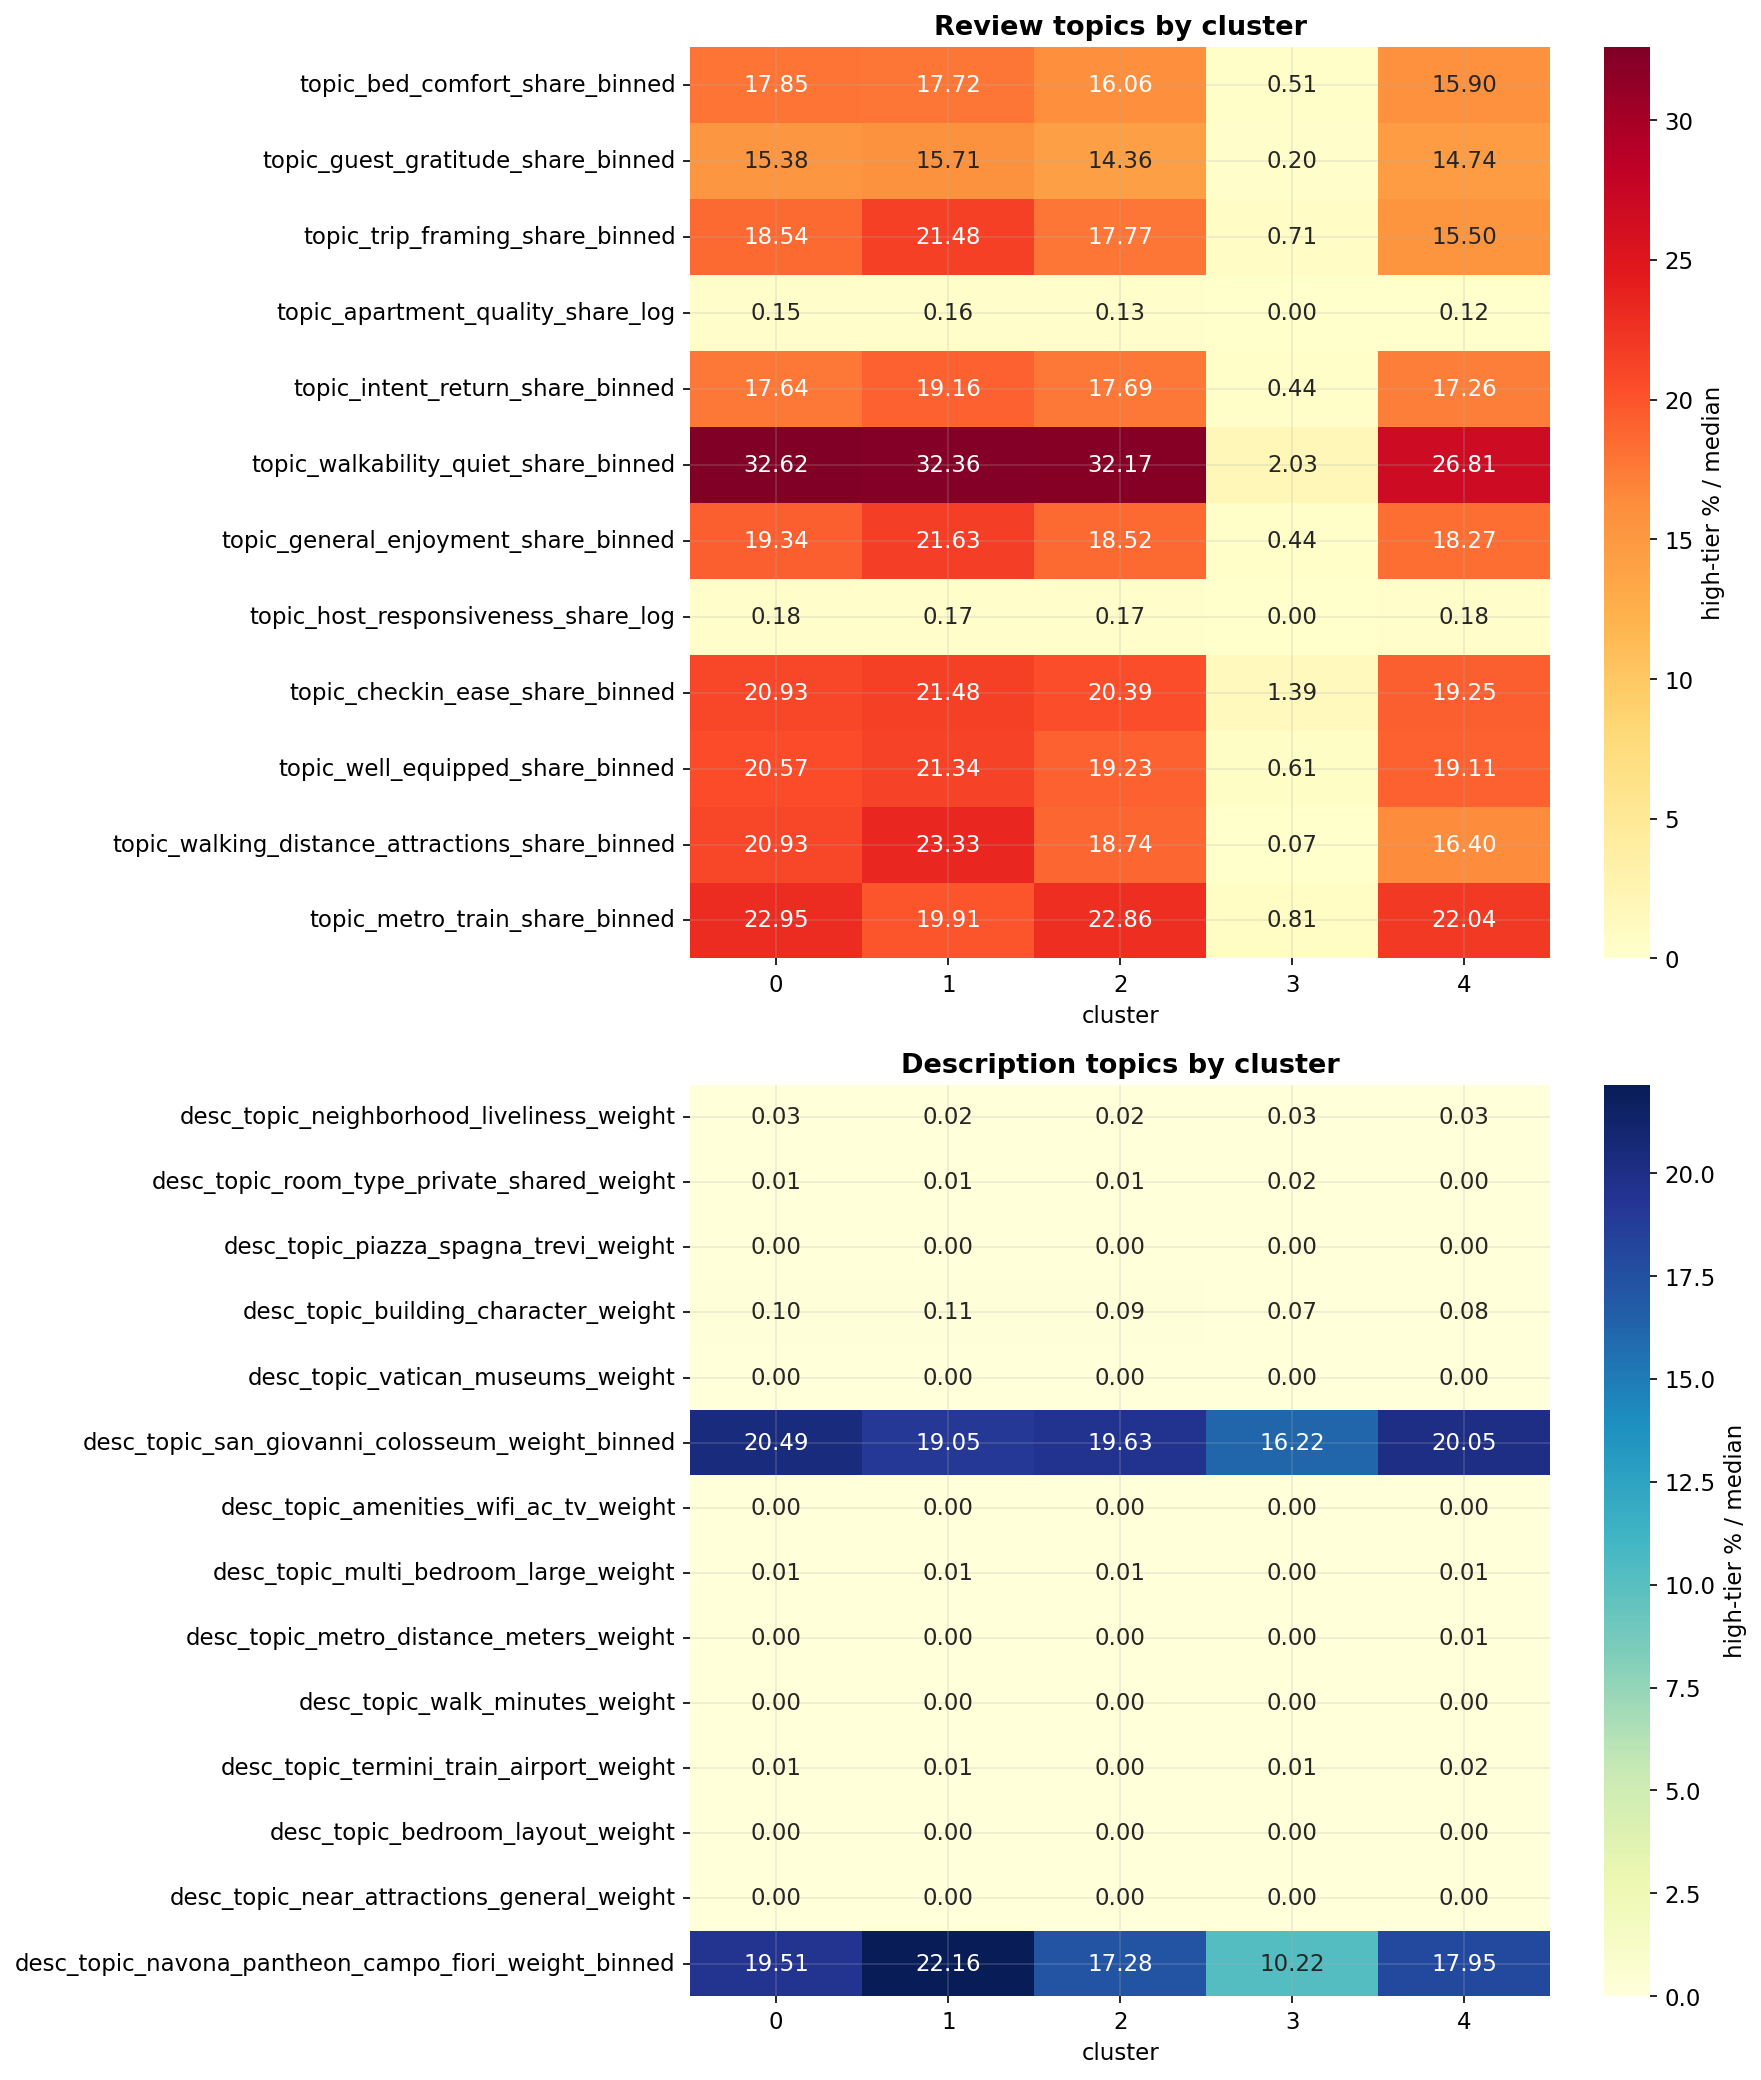

In [121]:
def topic_intensity_by_cluster(col):
    """For binned topic columns, returns % 'high' per cluster. For log-scale
    continuous topic shares, returns the median."""
    if pd.api.types.is_numeric_dtype(profile_df[col]):
        return profile_df.groupby('cluster')[col].median()
    return profile_df.groupby('cluster')[col].apply(lambda x: (x == 'high').mean() * 100)

review_topic_summary = pd.DataFrame({col: topic_intensity_by_cluster(col) for col in REVIEW_TOPIC_COLS}).T
desc_topic_summary = pd.DataFrame({col: topic_intensity_by_cluster(col) for col in DESC_TOPIC_COLS}).T

fig, axes = plt.subplots(2, 1, figsize=(12, 14))

sns.heatmap(review_topic_summary, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'high-tier % / median'}, ax=axes[0])
axes[0].set_title('Review topics by cluster')
axes[0].set_xlabel('cluster')

sns.heatmap(desc_topic_summary, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'high-tier % / median'}, ax=axes[1])
axes[1].set_title('Description topics by cluster')
axes[1].set_xlabel('cluster')

plt.tight_layout()
plt.show()

Review topics show one dominant pattern: cluster 3's values collapse to near-zero across every single topic (0.00-2.03%, against 15-33% everywhere else), a direct consequence of its low review volume already established earlier, fewer reviews means fewer chances for any topic to reach the "high" tier. Among the other four clusters, which track each other closely overall, `walkability_quiet` stands out as the single most intense topic everywhere (26-33%), and cluster 1 leads modestly on trip framing, general enjoyment, and walking distance to attractions, consistent with its position as the highest-engagement, highest-quality cluster throughout this profile.

Description topics tell a much flatter story: nearly every topic sits at 0.00 for all five clusters, meaning descriptions rarely emphasize these specific themes strongly enough to register. The two landmark-adjacent topics are the exception, `san_giovanni_colosseum` and `navona_pantheon_campo_fiori` both show real variation, and in both cases cluster 3 sits noticeably lower (16.2% and 10.2%) than the other four (17-22%), one further sign that cluster 3's listings are less landmark-anchored in how hosts describe them, on top of everything else already setting it apart.

#### 10.8.3 Tone Densities

tone density columns: 37


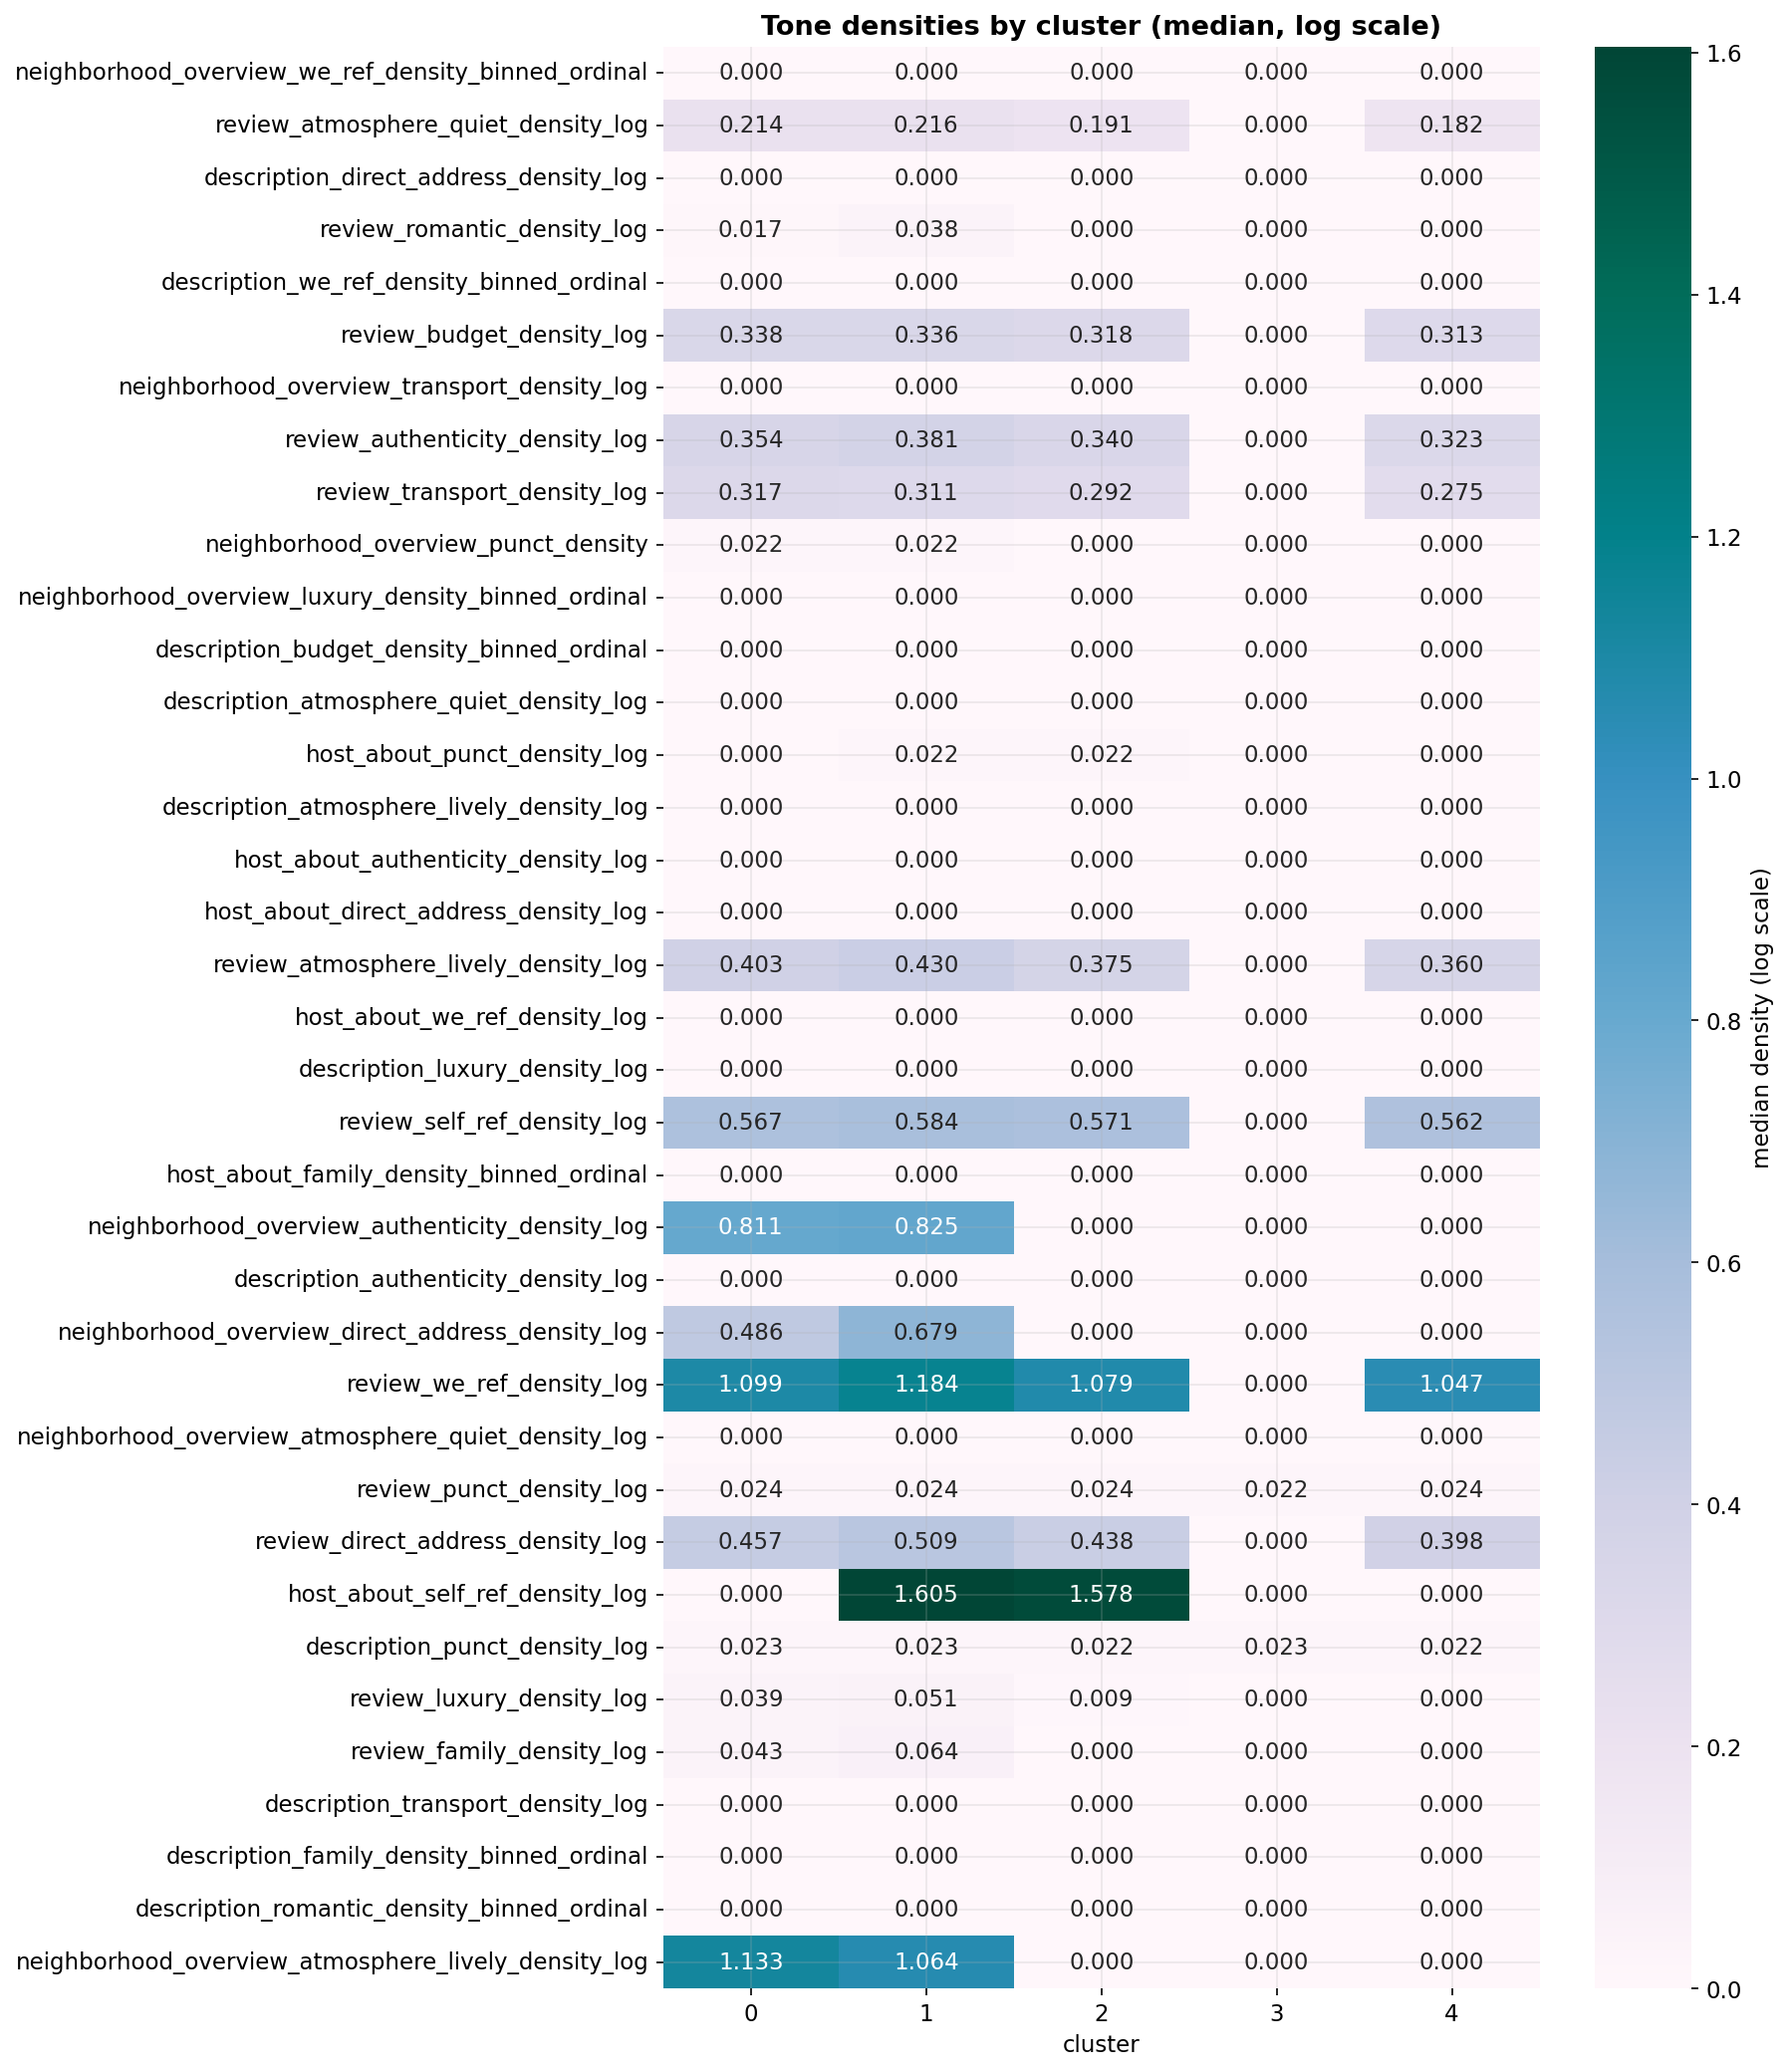

In [122]:
TONE_DENSITY_COLS = [c for c in NLP_CORE_COLS if 'density' in c and pd.api.types.is_numeric_dtype(profile_df[c])]
print(f"tone density columns: {len(TONE_DENSITY_COLS)}")

tone_density_summary = pd.DataFrame({
    col: profile_df.groupby('cluster')[col].median() for col in TONE_DENSITY_COLS
}).T

fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(tone_density_summary, annot=True, fmt='.3f', cmap='PuBuGn', cbar_kws={'label': 'median density (log scale)'}, ax=ax)
ax.set_title('Tone densities by cluster (median, log scale)')
ax.set_xlabel('cluster')
plt.tight_layout()
plt.show()

Most tone density medians sit at exactly 0.0000 across every cluster, expected given how zero-inflated these variables are by construction (most listings simply don't use a given tone at all). The columns that do show non-zero medians reveal a consistent, three-way split rather than random noise.

**Review-based densities** (self-reference, we-reference, atmosphere, authenticity, transport, budget, romantic, luxury, family) follow the same shape almost every time: clusters 0, 1, 2, and 4 sit at broadly similar, meaningfully positive values, while cluster 3 sits at exactly zero across nearly all of them. This is the same review-volume effect already seen twice before (in engagement score and in review topics): with few reviews, there's rarely enough text for any density measure to register above zero at the median.

**Host-about and neighborhood-overview densities** split differently, and more informatively. `host_about_self_ref_density` is essentially zero for clusters 0, 3, and 4, but distinctly elevated for clusters 1 and 2 (1.60 and 1.58), meaning hosts in these two clusters write noticeably more personal, self-referential "about me" sections. `neighborhood_overview_authenticity`, `direct_address`, and `atmosphere_lively` all show the same pattern in reverse: elevated only for clusters 0 and 1, zero for 2, 3, and 4, meaning these two clusters' neighborhood descriptions lean further into authentic, lively, directly-addressed language than the others. Together with the content flags from earlier, this reinforces the same two-axis picture: cluster 1 and 2 hosts write more about themselves, while clusters 0 and 1 write more vividly about the neighborhood, two related but genuinely separate stylistic signatures the clustering is picking up on.

### 10.9 Systematic Ranking. What Actually Distinguishes the Clusters

Every section so far picked out differences by inspection. This step is the objective check: for every feature in the final configuration, a single association measure with cluster membership, correlation ratio η for continuous variables, Cramér's V for categorical ones, ranked together so the strongest distinguishing features surface on their own rather than by which table happened to catch the eye.

In [124]:
def correlation_ratio(categories, values):
    df = pd.DataFrame({'cat': categories, 'val': values}).dropna()
    if df['cat'].nunique() < 2:
        return np.nan
    overall_mean = df['val'].mean()
    ss_between = df.groupby('cat', observed=True)['val'].apply(lambda g: len(g) * (g.mean() - overall_mean) ** 2).sum()
    ss_total = ((df['val'] - overall_mean) ** 2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else np.nan

def cramers_v(col1, col2):
    from scipy.stats import chi2_contingency
    df = pd.DataFrame({'a': col1, 'b': col2}).dropna()
    if len(df) == 0 or df['a'].nunique() < 2 or df['b'].nunique() < 2:
        return np.nan
    contingency = pd.crosstab(df['a'], df['b'])
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    r, k = contingency.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# every column that entered the final clustering matrix, split by type
all_final_cols = backbone_continuous_cols + backbone_categorical_cols_B + backbone_binary_cols + \
                   [c for c in (NLP_CORE_COLS | CONTENT_FLAG_COLS) if c in continuous_cols] + \
                   [c for c in (NLP_CORE_COLS | CONTENT_FLAG_COLS) if c in categorical_cols] + \
                   [c for c in (NLP_CORE_COLS | CONTENT_FLAG_COLS) if c in binary_cols]

ranking_rows = []
for col in set(all_final_cols):
    if pd.api.types.is_numeric_dtype(profile_df[col]):
        score = correlation_ratio(profile_df['cluster'], profile_df[col])
        measure = 'eta'
    else:
        score = cramers_v(profile_df['cluster'], profile_df[col])
        measure = "Cramer's V"
    if pd.notna(score):
        ranking_rows.append({'feature': col, 'measure': measure, 'association': round(score, 4)})

ranking_df = pd.DataFrame(ranking_rows).sort_values('association', ascending=False).reset_index(drop=True)
pd.set_option('display.max_rows', 40)
display(ranking_df.head(40))

,feature,measure,association
0,host_about_word_count_log,eta,0.8810
1,has_neighborhood_overview,eta,0.8767
2,has_host_about,eta,0.8490
3,neighborhood_overview_punct_density,eta,0.7837
4,neighborhood_overview_word_count,eta,0.7508
5,host_about_self_ref_density_log,eta,0.6747
6,neighborhood_overview_atmosphere_lively_densit...,eta,0.6617
7,host_about_punct_density_log,eta,0.6381
8,neighborhood_overview_authenticity_density_log,eta,0.6017
9,neighborhood_overview_landmark_count_log,eta,0.5833


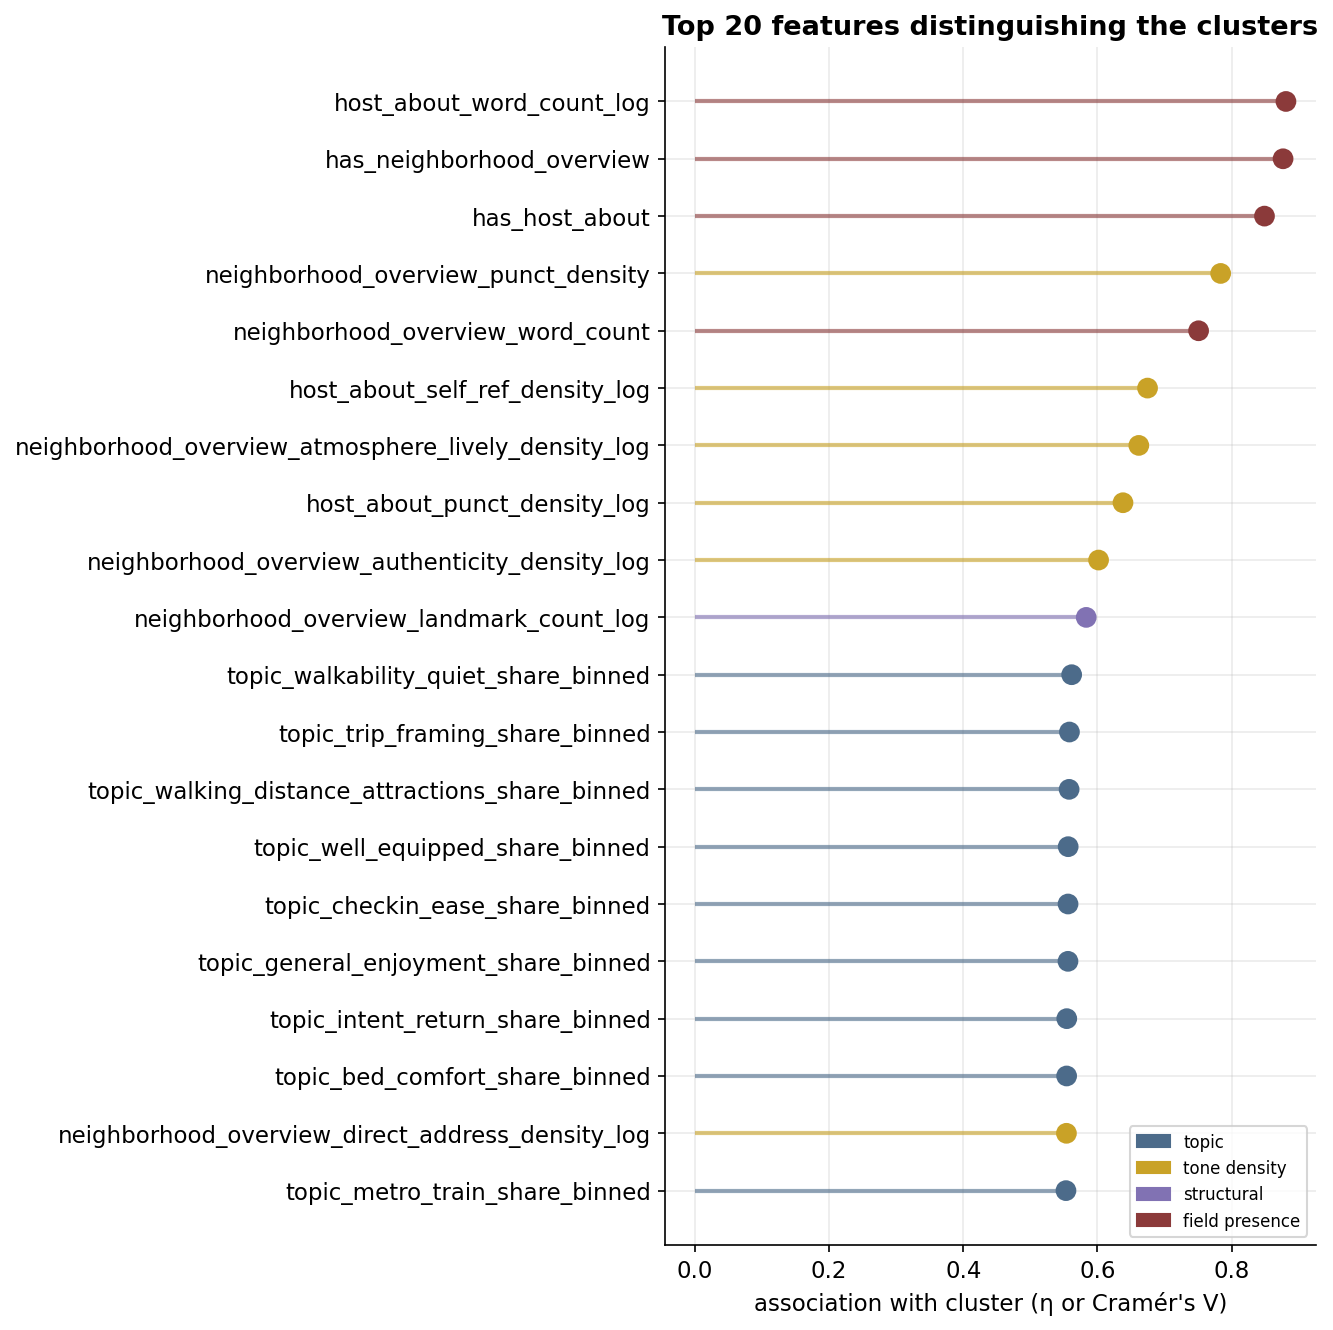

In [125]:
FEATURE_FAMILY_COLORS = {
    'field_presence': ROME_PALETTE['primary'],
    'topic': ROME_PALETTE['secondary'],
    'tone_density': ROME_PALETTE['accent'],
    'structural': '#8172b3',
    'host': '#55a868',
    'review_activity': '#c44e52',
    'sentiment': '#937860',
}

def classify_family(feature_name):
    if feature_name.startswith('has_') or 'word_count' in feature_name:
        return 'field_presence'
    if feature_name.startswith('topic_') or feature_name.startswith('desc_topic_'):
        return 'topic'
    if 'density' in feature_name or 'mtld' in feature_name or 'readability' in feature_name or 'exclaim' in feature_name or 'punct' in feature_name:
        return 'tone_density'
    if feature_name in ['host_experience_years', 'calculated_host_listings_count_log', 'host_is_superhost']:
        return 'host'
    if 'review' in feature_name or 'sentiment' in feature_name:
        return 'review_activity' if 'sentiment' not in feature_name else 'sentiment'
    return 'structural'

top20 = ranking_df.head(20).copy()
top20['family'] = top20['feature'].apply(classify_family)
top20 = top20.sort_values('association')

fig, ax = plt.subplots(figsize=(9, 9))
colors = top20['family'].map(FEATURE_FAMILY_COLORS)
ax.hlines(y=top20['feature'], xmin=0, xmax=top20['association'], color=colors, alpha=0.6, linewidth=2)
ax.scatter(top20['association'], top20['feature'], color=colors, s=80, zorder=3)
ax.set_xlabel('association with cluster (η or Cramér\'s V)')
ax.set_title('Top 20 features distinguishing the clusters')

from matplotlib.patches import Patch
present_families = top20['family'].unique()
legend_elements = [Patch(color=FEATURE_FAMILY_COLORS[f], label=f.replace('_', ' ')) for f in present_families]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

Ranking every feature by its objective association with cluster membership reveals something the section-by-section inspection didn't make explicit: the strongest dividing lines aren't tone or topic content, they're whether a host filled in the `host_about` and `neighborhood_overview` fields at all, and how much they wrote if so. `has_neighborhood_overview` (η=0.88), `has_host_about` (η=0.85), and the word counts for both fields (η=0.75-0.88) top the entire ranking, well above any topic, tone, or sentiment variable. This reframes the personal, self-referential writing style found in clusters 1 and 2 earlier: it's downstream of a more basic fact, hosts in those clusters are simply far more likely to have written these optional fields at all, and once they do, the specific stylistic differences (self-reference, authenticity, liveliness) follow as a second-order signal on top of that.

Review topic shares form the next tier (Cramér's V 0.55-0.56 across nearly all nine topics, moving almost in lockstep), which is the same low-activity signature from cluster 3 showing up here in aggregate, one cluster with far less review text drags every topic's association score up simply by being the consistent outlier. Host experience, review engagement, and amenities count round out the top 40 at more modest levels (η 0.30-0.43), the more familiar structural and behavioral signals sitting well below the field-completion effect at the top.

### 10.10 Connecting Back to the HDBSCAN-Confirmed Dense Subgroups

In [126]:
final_sample_idx_check = stratified_sample_indices(final_cluster_labels)
hdbscan_check = hdbscan.HDBSCAN(min_cluster_size=50, metric='precomputed')
hdbscan_labels_check = hdbscan_check.fit_predict(gower_dist_final.astype('float64'))

kproto_labels_on_sample = final_cluster_labels[final_sample_idx_check]

crosstab_hdbscan_final = pd.crosstab(
    pd.Series(hdbscan_labels_check, name='HDBSCAN'),
    pd.Series(kproto_labels_on_sample, name='K-Prototypes cluster')
)
display(crosstab_hdbscan_final)

K-Prototypes cluster,0,1,2,3,4
HDBSCAN,,,,,
-1,1717,1820,1320,601,2216
0,0,0,0,0,158
1,0,0,0,168,0


The two dense subgroups HDBSCAN found independently map onto K-Prototypes clusters exactly, with no overlap either way. HDBSCAN's cluster 1, the small isolated island visible on every UMAP plot throughout this notebook, is entirely contained within cluster 3, the same cluster identified throughout this profile as the market's outlier on almost every measure: least reviewed, least professionally hosted, lowest amenity count, most room-share and long-term-oriented, and the only cluster where review-based text signals collapse to near-zero. HDBSCAN's cluster 0, the smaller, less visually distinct pocket, maps entirely onto cluster 4, the market's largest segment, meaning cluster 4 contains both a genuinely dense pocket and a large amount of more loosely-connected listings that HDBSCAN leaves unassigned (as does most of the market outside these two subgroups). This confirms cluster 3 isn't just the smallest cluster in this K-Prototypes solution, it's a genuinely distinct, tightly-knit segment recoverable by a completely different clustering method, while cluster 4's size comes from combining one denser core with the market's broader, harder-to-separate remainder.

### 10.11 Narrative Cluster Portraits

Putting every axis together, price, geography, structure, host behavior, review activity, and text, produces five segments with distinct, coherent identities. The strongest single driver behind them, per the ranking in §10.9, is field completion: how much a host bothered to write in the optional `host_about` and `neighborhood_overview` fields, and about what. Everything else (price, professionalism, review activity) layers on top of that basic split.

**Cluster 0 — Neighborhood-Focused Hosts (21.5%, 6,592 listings)**

Single-listing hosts (portfolio median 1) at a comfortable mid-price (€131) who put real effort into describing the area rather than themselves. Their neighborhood-overview text is vivid and personal (high self-reference, exclamation, family, and romantic mentions), while their host-about sections stay nearly silent on tone (luxury, budget, professionalism all under 1%). Moderately experienced (7.2 years) and moderately professional (47% Superhost), engagement and review activity sit squarely in the middle of the pack. This is the classic small, independent host who sells the location.

**Cluster 1 — Premium, Full-Effort Listings (22.7%, 6,987 listings)**

The market's clear top performer on nearly every measure: highest price (€142 median), closest to the historic center (2.09km, 62% in Centro Storico), most amenities (median 40), longest host tenure (10.2 years), highest Superhost rate (62%), fastest responses (84% within an hour), and the most engaged, most frequent, longest reviews of any cluster. It's also the only segment that writes richly in *both* directions, high on host-about tone (luxury, atmosphere, professionalism) and neighborhood-overview tone (exclaim, family, romantic, self-reference) at once. If cluster 0 sells the location and cluster 2 (below) sells the host, cluster 1 sells both, and charges accordingly.

**Cluster 2 — Multi-Listing Operators (16.5%, 5,070 listings)**

The market's largest average portfolio (median 4 listings per host), paired with a host-about section that's nearly as personal as cluster 1's (elevated self-reference, luxury, atmosphere, professionalism mentions), but a neighborhood-overview section that goes almost silent (every neighborhood tone flag under 1%). Slightly more private rooms than average, mid-range pricing, and host quality trailing cluster 1 on every measure (lower Superhost rate, slightly less experience). This reads as a more commercially-run operation: hosts confident enough to write about themselves and their brand, managing several units, but not investing the same effort into selling each individual neighborhood.

**Cluster 3 — Low-Activity Niche (9.6%, 2,954 listings)**

The market's genuine outlier, independently confirmed by HDBSCAN as a tight, self-contained group rather than an artifact of K-Prototypes forcing a split. Cheapest cluster (€119.5), furthest from the center (3.63km), least Centro Storico presence (33%), and structurally distinct: more private rooms and B&B-type listings, the highest long-term-orientation rate in the market (12%), and hosts who are newer (3.8 years), far less likely to be Superhosts (13%), and slower to respond. Review activity collapses to near-zero across almost every text measure, not because the segment is disliked. It actually posts the highest positive-sentiment share of any cluster, but because it simply generates far fewer reviews to measure in the first place. A small, quieter corner of the market: cheaper, longer stays, less polished hosting, but well-liked by the guests it does have.

**Cluster 4 — Minimal-Profile Majority (29.7%, 9,115 listings)**

The largest segment by a wide margin, and the market's default, low-effort profile. Budget-leaning (27% in the Budget tier, the lowest Luxury share of any cluster), single-listing hosts (portfolio median 1) with the least experience alongside cluster 3 (4.2 years) and a below-average Superhost rate (42%). Its defining trait is near-total text silence: essentially every content flag, host-about and neighborhood-overview alike, sits at or near zero, meaning most hosts here simply didn't fill in these optional fields at all. It also contains one genuinely dense pocket that HDBSCAN detects independently, alongside a much larger body of loosely-connected, unremarkable listings, this is less a segment with a strong shared identity than the market's broad, unexceptional baseline against which the other four define themselves.